# Explainable Dual-Head CNN–BiLSTM–Attention Prognostics for Industrial Bearing Health Monitoring
### A leakage-controlled, fully audited study on the PRONOSTIA / IEEE PHM 2012 bearing dataset

**Abstract.** ABSTRACT_PLACEHOLDER

## 1. Research Questions

* **RQ1 – Data.** What does the PRONOSTIA / IEEE PHM 2012 dataset really contain, and is every fact we rely on (lifetimes, end of life, file formats) consistent?
* **RQ2 – Formulation.** Which prognostic formulation (raw RUL, capped RUL, normalised RUL, stage classification, degradation detection, multi-task) is scientifically defensible for this data?
* **RQ3 – Generalisation.** How well does vibration data predict remaining life and health stage of a bearing that the model has **never seen** (bearing-level validation, no leakage)?
* **RQ4 – Architecture.** Does each component of the proposed CNN–BiLSTM–Attention dual-head network (CNN, BiLSTM, attention, second head) measurably contribute, compared with simple baselines?
* **RQ5 – Explainability.** What can the attention weights and feature-importance analyses truthfully tell us?
* **RQ6 – Limits.** For which bearings is early warning physically possible, and for which is failure too abrupt?

**Hypotheses (stated before looking at any test result, and tested — not assumed).**
H1: sequence models detect impending failure better than tabular baselines. H2: the attention layer and the dual head improve accuracy. H3: a warning several tens of minutes before failure is possible for every bearing.

## 2. Dataset Research & Literature Review

*This section was written from primary sources that were actually opened while preparing the project: the official challenge document shipped with the dataset [2], the platform paper [1], and the peer-reviewed / arXiv papers listed in Section 28. Statements marked **[CITATION NEEDED]** could not be verified from a source I could open and should be confirmed before publication.*

### 2.1 Facts about the dataset

| # | Topic | Fact | Source |
|---|---|---|---|
| 1 | Origin | Collected on the **PRONOSTIA** platform of the AS2M department, **FEMTO-ST Institute**, Besançon, France | [1], [2] |
| 2 | Purpose | Data for the **IEEE PHM 2012 Prognostic Challenge**: estimate the remaining useful life (RUL) of bearings from monitoring data; "accelerated" degradation so that failure happens within hours | [1], [2] |
| 3 | Number of bearings | **17** run-to-failure experiments | [2] Table 1, [3] |
| 4 | Learning set | **6** bearings: Bearing1_1, 1_2, 2_1, 2_2, 3_1, 3_2 (complete run-to-failure) | [2] Table 1 |
| 5 | Test set | **11** bearings: 1_3–1_7, 2_3–2_7, 3_3. In the *challenge* these were **truncated** and participants had to predict RUL | [2] §1.2, Table 1 |
| 6 | Operating conditions | C1: 1800 rpm, 4000 N; C2: 1650 rpm, 4200 N; C3: 1500 rpm, 5000 N (radial load applied by a pneumatic jack; the dynamic load rating of the bearing is 4000 N) | [2] §3.2, App. A.1 |
| 7 | Sampling frequency | Vibration: **25.6 kHz** (temperature: 10 Hz) | [2] §4.1 |
| 8 | Samples per snapshot | **2560** samples (= 1/10 s) | [2] §4.1 |
| 9 | Snapshot interval | one snapshot every **10 s** (temperature: 600 samples per minute) | [2] §4.1 |
| 10 | Channels | **Two** accelerometers (DYTRAN 3035B, 50 g range) mounted radially, **90° apart**, on the outer race: **horizontal** and **vertical** | [1] §III-C, [2] §2.4, App. A.2 |
| 11 | End of life | Tests were stopped when the vibration amplitude exceeded **20 g**; "RUL was defined as time to accelerometer exceeding 20 g" | [2] §3.1, Note 1 |
| 12 | File structure | `acc_xxxxx.csv` (vibration) and `temp_xxxxx.csv` (temperature); 6 columns: hour, minute, second, µ-second, horizontal acceleration, vertical acceleration | [2] §4.2, Table 2 |
| 13 | Repository | The GitHub copy used here contains `Learning_set/`, `Test_set/` (truncated, as in the challenge) and **`Full_Test_Set/`** (test bearings run to failure). `Full_Test_Set` is **not described** in the challenge document [2] or the README [3]; its consistency with [2] is checked in Section 5 | [3] + audit |
| 14 | Known characteristics | Very different durations (**1 h to 7 h**), a **small learning set**, and **very different degradation behaviours**; some degradations are **sudden** and non-monotonic; classical fault-frequency models (L10, BPFI, BPFO) **do not match** the observations; noise level is not controlled | [1] §IV-C–E, [2] §1.2, Notes 2–3 |
| 15 | Reported difficulties | Learning from a *small number of run-to-failure bearings* is the central difficulty | [2], [4] |

### 2.2 How researchers formulate the problem

* **Official challenge task.** Predict the RUL of each of the 11 test bearings at its truncation point; the error is a *percentage error* and the score is **asymmetric** (late predictions are punished harder than early ones) [2] §5.1. We reproduce this protocol exactly in Section 22.
* **Prognostic pipeline.** A widely cited review divides machinery prognostics into data acquisition, **health-indicator (HI) construction**, **health-stage division**, and RUL prediction [6].
* **Two-stage / capped targets.** In other prognostic benchmarks a *piece-wise linear* RUL target (constant while healthy, then linear decrease to 0) is common, because a healthy system gives no evidence about how much life remains [8] (turbofan data; the same reasoning applies to bearings). Using the *fraction of life* as target is also used with this dataset [4] (past-useful-life ratio) but it needs the total lifetime, which is unknown for a running machine.
* **Common metrics.** The official percentage-error score [2]; MAE / RMSE are widely used in follow-up work **[CITATION NEEDED: a specific PHM-2012 paper reporting MAE/RMSE]**.
* **Deep models on this data.** Deep architectures (CNN, LSTM, attention) have been benchmarked on this dataset, e.g. [5]. **[CITATION NEEDED]** for a peer-reviewed CNN–LSTM–attention PHM-2012 paper; I could not open one.

### 2.3 Leakage risks specific to this data and how experts view splitting

1. **Random splitting of sliding windows** puts almost identical overlapping windows into train and test. A 2026 preprint on multi-task fault-diagnosis/RUL models reports that naive window splitting can inflate accuracy from a genuine 20–60 % to 99.9 % [10] (preprint, not peer-reviewed; the effect is shown independently in Section 13).
2. **Using the test bearings' full runs** (`Full_Test_Set`) for anything except final scoring — scaling statistics, thresholds, target design, model selection — would leak information the challenge deliberately hid.
3. **Lifetime-normalised targets** (fraction of life) silently use the failure time of the evaluated bearing.
4. **The bearing is the independent unit.** The challenge itself separates whole bearings into learning and test sets [2]; that is the appropriate protocol. With only 6 learning bearings, *leave-one-bearing-out* validation is the natural way to use them.

## 3. Literature-Based Methodology and Design Decisions

| Decision | Choice | Justification |
|---|---|---|
| Unit of independence | the **bearing** | [2], [10]; windows of one bearing are highly dependent |
| Method-development data | the **6 learning bearings only** (leave-one-bearing-out) | test bearings must not influence any design choice |
| Final test | the **11 test bearings**, scored once after the design is frozen | official protocol [2] |
| End of life | official recording duration for learning bearings; *truncation point + official RUL* for test bearings | consistent with [2]; fixes an inconsistency found in the audit (Bearing1_4) |
| Input | last **16 snapshots (160 s)** of 34 vibration features | causal window; documented in Section 9 |
| Target | **capped RUL (minutes, cap 120)** + **3-class stage** (Normal / Warning / Critical) derived **only from the failure time** | Section 11 explains why this is the defensible formulation and why no vibration-based "onset" label is used for training |
| Baselines | Constant, Ridge, Random Forest, Gradient Boosting, LSTM, CNN, CNN+LSTM, CNN+BiLSTM | Section 14 |
| Selection | decided on **LOBO validation only**, written to disk **before** the test bearings are scored | Section 17 / 22 |
| Reporting | negative results are reported | Section 25 |

**Remaining hindsight / contamination that must be admitted.** (i) Before this notebook existed I inspected health-indicator curves of *all* 17 bearings, including test bearings, in earlier experiments (v1/v2). The target used here does **not** need any vibration-based label, which removes that dependence from training, but the *choice* of a capped RUL formulation was motivated by earlier poor results. (ii) Descriptive plots of test bearings are shown only *after* the design freeze (Section 22) and are never used for a decision.

## 4. Setup, Reproducibility and Dataset Loading

**WHAT** – import the project modules (`src/`), fix all random seeds, enable deterministic TensorFlow operations and print library versions. Then read **every raw vibration file once** (24,889 files) and compute both audit fields and features.
**WHY** – a result is only meaningful if it can be reproduced and if we know exactly which data produced it.
**EXPECT** – about 2 minutes (the result is written to `artifacts/features_raw.csv` as an output; the notebook never reads a stale cache).
**HOW IT HELPS** – all later sections work from this single, audited table.

In [1]:
import os, sys, json, time, random, platform, warnings, filecmp, hashlib
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"; os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sys.path.insert(0, str(Path.cwd()))                   # the notebook lives in final_project/
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, sklearn, scipy
from IPython.display import display, Markdown
import tensorflow as tf
from src import config as C, features as F, data as D, models as M, metrics as Mx, experiment as E, analysis as A, leakage as L, report as R

SEED = 42
random.seed(SEED); np.random.seed(SEED); M.set_determinism(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 90, "savefig.dpi": 300, "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10, "legend.fontsize": 9})
COND_COLOR = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}
C.ARTIFACTS.mkdir(exist_ok=True); C.FIGURES.mkdir(exist_ok=True)
VERSIONS = dict(python=platform.python_version(), numpy=np.__version__, pandas=pd.__version__, sklearn=sklearn.__version__,
                scipy=scipy.__version__, tensorflow=tf.__version__, platform=platform.platform())
print(json.dumps(VERSIONS, indent=1))
print("dataset folder:", C.DATASET, "| exists:", C.DATASET.exists())
t0 = time.time()
raw = F.extract_all(C.ARTIFACTS / "features_raw.csv", force=True)      # ALWAYS re-reads all raw files (no dependence on any cache); the CSV is only an output
print(f"raw feature table: {raw.shape[0]:,} snapshots x {raw.shape[1]} columns  ({time.time()-t0:.0f}s)")

{
 "python": "3.12.6",
 "numpy": "2.2.6",
 "pandas": "2.2.2",
 "sklearn": "1.5.2",
 "scipy": "1.14.1",
 "tensorflow": "2.20.0",
 "platform": "Windows-11-10.0.22621-SP0"
}
dataset folder: D:\faisal-VS\faisal project\MA_project\ieee-phm-2012-data-challenge-dataset-master | exists: True


raw feature table: 24,889 snapshots x 45 columns  (98s)


## 5. Complete Dataset Audit

**WHAT** – inspect the *whole* dataset programmatically: bearing IDs, files per bearing, lifetimes, operating conditions, delimiters, rows/columns per file, missing or infinite values, clock stamps, where the 20 g threshold is actually crossed, and whether the test data is consistent with the official challenge document.
**WHY** – the earlier notebook silently assumed these facts. If any is wrong (for example the end of life of one bearing) every RUL label built on it is wrong.
**EXPECT** – 17 bearings, 2560 × 6 files, and lifetimes that match the official table. Anything else is an anomaly we must document and handle.
**HOW IT HELPS** – it decides how the end of life (and therefore every target) is defined.

In [2]:
rows = []
for b in C.LEARNING + C.TEST:
    g = raw[raw.bearing == b].sort_values("snapshot_idx"); n = len(g)
    d = np.diff(g.t0_clock_s.values); d = np.where(d < -3600, d + 86400, d)          # clock stamps of the first sample of each file
    mx = np.maximum(g.max_abs_h.values, g.max_abs_v.values)
    trunc = D.truncated_length(b); rpm, load = C.CONDITION[C.condition_of(b)]
    folder = C.DATASET / C.subset_of(b) / b
    rows.append({"bearing": b, "set": "learning" if b in C.LEARNING else "test", "condition": C.condition_of(b), "rpm": rpm, "load_N": load,
                 "acc_files": n, "temp_files": len(list(folder.glob("temp_*.csv"))), "lifetime_min": round((n - 1) * 10 / 60, 1),
                 "rows/file": f"{g.n_rows.min()}-{g.n_rows.max()}", "cols": int(g.n_cols.max()), "delimiter": "".join(sorted(g.sep.unique())),
                 "NaN": int(g.n_nan.sum()), "Inf": int(g.n_inf.sum()), "peak_g": round(float(mx.max()), 1),
                 "snapshots>20g": int((mx > C.FAILURE_G).sum()), "first>20g_at_%life": round(100 * np.argmax(mx > C.FAILURE_G) / n, 1) if (mx > C.FAILURE_G).any() else np.nan,
                 "irregular_clock_steps": int((np.abs(d - 10) > 1).sum()),
                 "trunc_files": trunc, "official_RUL_s": C.OFFICIAL_RUL_S.get(b, np.nan), "implied_RUL_s": (n - trunc) * 10 if b in C.TEST else np.nan})
audit = pd.DataFrame(rows).set_index("bearing")
audit["RUL_consistent"] = np.where(audit.set == "test", audit.official_RUL_s == audit.implied_RUL_s, np.nan)
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 40)
display(audit)

# ---- hard assertions on the parts that must hold for the pipeline ----
assert len(audit) == 17 and (audit.set == "learning").sum() == 6 and (audit.set == "test").sum() == 11
assert (raw.n_rows == C.N_SAMPLES).all() and (raw.n_cols == 6).all(), "unexpected file shape"
assert raw.n_nan.sum() == 0 and raw.n_inf.sum() == 0, "missing / infinite raw values"
print(f"\nTotal snapshots: {audit.acc_files.sum():,} | raw vibration samples: {audit.acc_files.sum()*C.N_SAMPLES*2:,} (2 channels) | "
      f"delimiters: {raw.groupby('sep').size().to_dict()}")

# ---- the truncated Test_set must be the first part of Full_Test_Set (byte-identical files) ----
same_bytes, same_num, owners = [], [], []
for b in C.TEST:
    k = int(audit.loc[b, "trunc_files"])
    for i in (1, k // 2, k):
        f1 = C.DATASET / "Test_set" / b / f"acc_{i:05d}.csv"; f2 = C.DATASET / "Full_Test_Set" / b / f"acc_{i:05d}.csv"
        same_bytes.append(filecmp.cmp(f1, f2, shallow=False)); owners.append(b)
        a1, _ = F.read_snapshot(f1); a2, _ = F.read_snapshot(f2); same_num.append(a1.shape == a2.shape and bool(np.array_equal(a1, a2)))
print(f"Test_set vs Full_Test_Set (3 files per test bearing): byte-identical {sum(same_bytes)}/{len(same_bytes)}, numerically identical {sum(same_num)}/{len(same_num)}")
print("bearings whose files differ only in bytes:", sorted({b for b, sb, sn in zip(owners, same_bytes, same_num) if not sb and sn}), "(delimiter: Test_set uses ',', Full_Test_Set uses ';')")
assert all(same_num), "Full_Test_Set is not numerically identical to the truncated Test_set"

# ---- anomalies, derived from the table (not typed by hand) ----
anom = []
for b, r in audit[audit.set == "test"].iterrows():
    if not r.RUL_consistent:
        anom.append(f"**{b}**: Full_Test_Set has {int(r.acc_files - r.trunc_files)} snapshots after the truncation point (= {r.implied_RUL_s:.0f} s) but the official actual RUL is {r.official_RUL_s:.0f} s -> the extra {(r.implied_RUL_s - r.official_RUL_s):.0f} s of data lie **after the official end of life**")
for b, r in audit.iterrows():
    if r.irregular_clock_steps:
        anom.append(f"**{b}**: {r.irregular_clock_steps} irregular clock steps (logging glitch in the time stamps only; file order and the 10 s interval from [2] are used instead)")
    if r["snapshots>20g"] == 0:
        anom.append(f"**{b}**: no recorded 0.1 s snapshot ever exceeds 20 g (peak {r.peak_g} g) -> the 20 g end-of-life criterion is **not observable in the snapshots** for this bearing")
    elif r["first>20g_at_%life"] < 90:
        anom.append(f"**{b}**: first snapshot above 20 g already at {r['first>20g_at_%life']}% of the recorded life -> a 20 g threshold applied to the snapshots would give a very different end of life than the official duration")
R.show("### Anomalies found by the audit\n" + "\n".join(f"* {a}" for a in anom))
audit.to_csv(C.ARTIFACTS / "dataset_audit_table.csv")

,set,condition,rpm,load_N,acc_files,temp_files,lifetime_min,rows/file,cols,delimiter,NaN,Inf,peak_g,snapshots>20g,first>20g_at_%life,irregular_clock_steps,trunc_files,official_RUL_s,implied_RUL_s,RUL_consistent
bearing,,,,,,,,,,,,,,,,,,,,
Bearing1_1,learning,1,1800,4000,2803,466,467.0,2560-2560,6,",",0,0,48.1,46,46.3,3,NaN,NaN,NaN,NaN
Bearing1_2,learning,1,1800,4000,871,144,145.0,2560-2560,6,",",0,0,36.7,63,14.6,0,NaN,NaN,NaN,NaN
Bearing2_1,learning,2,1650,4200,911,151,151.7,2560-2560,6,",",0,0,25.2,4,93.4,0,NaN,NaN,NaN,NaN
Bearing2_2,learning,2,1650,4200,797,0,132.7,2560-2560,6,",",0,0,38.1,5,99.1,0,NaN,NaN,NaN,NaN
Bearing3_1,learning,3,1500,5000,515,89,85.7,2560-2560,6,",",0,0,41.3,1,95.7,0,NaN,NaN,NaN,NaN
Bearing3_2,learning,3,1500,5000,1637,0,272.7,2560-2560,6,",",0,0,23.7,1,99.8,0,NaN,NaN,NaN,NaN
Bearing1_3,test,1,1800,4000,2375,0,395.7,2560-2560,6,",",0,0,48.1,394,68.9,0,1802.0,5730.0,5730.0,1.0
Bearing1_4,test,1,1800,4000,1428,237,237.8,2560-2560,6,;,0,0,48.1,291,78.8,0,1139.0,339.0,2890.0,0.0
Bearing1_5,test,1,1800,4000,2463,410,410.3,2560-2560,6,",",0,0,14.1,0,NaN,0,2302.0,1610.0,1610.0,1.0



Total snapshots: 24,889 | raw vibration samples: 127,431,680 (2 channels) | delimiters: {',': 23461, ';': 1428}


Test_set vs Full_Test_Set (3 files per test bearing): byte-identical 30/33, numerically identical 33/33
bearings whose files differ only in bytes: ['Bearing1_4'] (delimiter: Test_set uses ',', Full_Test_Set uses ';')


### Anomalies found by the audit
* **Bearing1_4**: Full_Test_Set has 289 snapshots after the truncation point (= 2890 s) but the official actual RUL is 339 s -> the extra 2551 s of data lie **after the official end of life**
* **Bearing1_1**: 3 irregular clock steps (logging glitch in the time stamps only; file order and the 10 s interval from [2] are used instead)
* **Bearing1_1**: first snapshot above 20 g already at 46.3% of the recorded life -> a 20 g threshold applied to the snapshots would give a very different end of life than the official duration
* **Bearing1_2**: first snapshot above 20 g already at 14.6% of the recorded life -> a 20 g threshold applied to the snapshots would give a very different end of life than the official duration
* **Bearing1_3**: first snapshot above 20 g already at 68.9% of the recorded life -> a 20 g threshold applied to the snapshots would give a very different end of life than the official duration
* **Bearing1_4**: first snapshot above 20 g already at 78.8% of the recorded life -> a 20 g threshold applied to the snapshots would give a very different end of life than the official duration
* **Bearing1_5**: no recorded 0.1 s snapshot ever exceeds 20 g (peak 14.1 g) -> the 20 g end-of-life criterion is **not observable in the snapshots** for this bearing
* **Bearing1_6**: first snapshot above 20 g already at 75.7% of the recorded life -> a 20 g threshold applied to the snapshots would give a very different end of life than the official duration
* **Bearing2_3**: first snapshot above 20 g already at 13.6% of the recorded life -> a 20 g threshold applied to the snapshots would give a very different end of life than the official duration
* **Bearing2_4**: no recorded 0.1 s snapshot ever exceeds 20 g (peak 8.8 g) -> the 20 g end-of-life criterion is **not observable in the snapshots** for this bearing
* **Bearing2_6**: no recorded 0.1 s snapshot ever exceeds 20 g (peak 11.5 g) -> the 20 g end-of-life criterion is **not observable in the snapshots** for this bearing
* **Bearing2_7**: first snapshot above 20 g already at 70.4% of the recorded life -> a 20 g threshold applied to the snapshots would give a very different end of life than the official duration
* **Bearing3_3**: no recorded 0.1 s snapshot ever exceeds 20 g (peak 16.0 g) -> the 20 g end-of-life criterion is **not observable in the snapshots** for this bearing

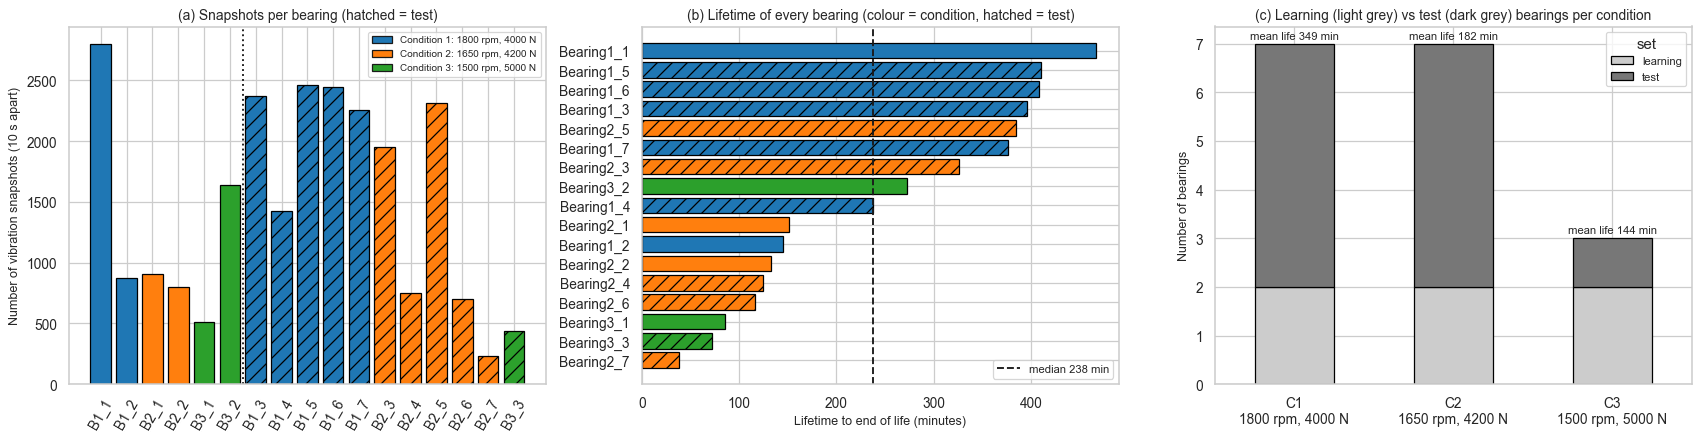

**Figure 1.** (a) file counts, (b) lifetimes and (c) conditions. Lifetimes range from **38 to 467 minutes** (factor 12); per condition (min/median/max): C1: 145.0/395.7/467.0; C2: 38.2/132.7/385.0; C3: 72.2/85.7/272.7. Condition 3 has only 3 bearings, so its learning history is a single-digit sample.

In [3]:
# Figure 1 - dataset overview: snapshots, lifetimes, operating conditions
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
order = C.LEARNING + C.TEST
cols = [COND_COLOR[C.condition_of(b)] for b in order]
bars = ax[0].bar(range(17), audit.loc[order, "acc_files"], color=cols, edgecolor="black")
for p_, b_ in zip(bars, order):
    if b_ in C.TEST: p_.set_hatch("//")
ax[0].set_xticks(range(17)); ax[0].set_xticklabels([b.replace("Bearing", "B") for b in order], rotation=60)
ax[0].set_ylabel("Number of vibration snapshots (10 s apart)"); ax[0].set_title("(a) Snapshots per bearing (hatched = test)")
ax[0].axvline(5.5, color="k", ls=":")
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(fc=COND_COLOR[c], ec="k", label=f"Condition {c}: {C.CONDITION[c][0]} rpm, {C.CONDITION[c][1]} N") for c in (1, 2, 3)], fontsize=8, loc="upper right")
srt = audit.sort_values("lifetime_min")
bars_b = ax[1].barh(srt.index, srt.lifetime_min, color=[COND_COLOR[c] for c in srt.condition], edgecolor="black")
for p_, b_ in zip(bars_b, srt.index):
    if b_ in C.TEST: p_.set_hatch("//")
ax[1].axvline(audit.lifetime_min.median(), color="k", ls="--", label=f"median {audit.lifetime_min.median():.0f} min")
ax[1].set_xlabel("Lifetime to end of life (minutes)"); ax[1].set_title("(b) Lifetime of every bearing (colour = condition, hatched = test)"); ax[1].legend(loc="lower right")
cnt = audit.groupby(["condition", "set"]).size().unstack(fill_value=0)
cnt.plot(kind="bar", stacked=True, ax=ax[2], color=["#cccccc", "#777777"], edgecolor="black")
ax[2].set_xticklabels([f"C{c}\n{C.CONDITION[c][0]} rpm, {C.CONDITION[c][1]} N" for c in cnt.index], rotation=0)
ax[2].set_ylabel("Number of bearings"); ax[2].set_title("(c) Learning (light grey) vs test (dark grey) bearings per condition"); ax[2].set_xlabel("")
for i, c in enumerate(cnt.index):
    ax[2].text(i, cnt.loc[c].sum() + 0.1, f"mean life {audit[audit.condition==c].lifetime_min.mean():.0f} min", ha="center", fontsize=9)
plt.tight_layout(); R.savefig(fig, "fig01_dataset_overview.png"); plt.show()
lt = audit.groupby("condition").lifetime_min.agg(["min", "median", "max"]).round(1)
R.show(f"**Figure 1.** (a) file counts, (b) lifetimes and (c) conditions. Lifetimes range from **{audit.lifetime_min.min():.0f} to {audit.lifetime_min.max():.0f} minutes** "
       f"(factor {audit.lifetime_min.max()/audit.lifetime_min.min():.0f}); per condition (min/median/max): " + "; ".join(f"C{c}: {r['min']}/{r['median']}/{r['max']}" for c, r in lt.iterrows()) +
       f". Condition 3 has only {int((audit.condition==3).sum())} bearings, so its learning history is a single-digit sample.")

### 5.1 What did we find?
The dataset is clean in format: every one of the 24,889 files is a 2560 × 6 numeric table, no value is missing, and only Bearing1_4 uses `;` instead of `,`. The audit, however, exposed three facts that shape the whole project:

1. **Lifetimes differ by a factor of about 12** and there are only 6 learning bearings — the central difficulty named by the organisers [2].
2. **The 20 g criterion is not visible in every snapshot** because a snapshot covers only 0.1 s out of every 10 s. Some bearings never show > 20 g, others show it long before the end. Therefore the **end of life must come from the official recording duration and the official RUL table [2], not from thresholding the snapshots**.
3. **Bearing1_4** in `Full_Test_Set` contains data *after* its official end of life. We truncate it at the official end of life (Section 11), which is the only choice consistent with [2]. The truncated `Test_set` and `Full_Test_Set` are numerically identical where they overlap (Bearing1_4 differs only in the delimiter), so the official truncation points can be used in Section 22.

**Does this support our hypotheses?** It supports the need for bearing-level validation (H-related design), and it already warns that H3 (long warning for every bearing) is doubtful, because lifetimes and degradation dynamics vary so much.

## 6. Sample Raw Data

**WHAT** – open one raw file exactly as delivered, label its six columns using the official description [2, Table 2], and plot it.
**WHY** – to be sure we interpret the measurements correctly (units, channels, time base) before extracting features.
**EXPECT** – 2560 rows covering 0.1 s; two acceleration columns in units of *g* around zero.

file: acc_00010.csv | rows: 2560 | delimiter: ',' | duration: 100 ms at 25.6 kHz


,hour,minute,second,microsecond,horizontal_acc_g,vertical_acc_g
0,9.0,41.0,9.0,65664.0,-0.509,0.343
1,9.0,41.0,9.0,65703.0,-0.712,-0.395
2,9.0,41.0,9.0,65742.0,-0.479,0.129
3,9.0,41.0,9.0,65781.0,0.676,-0.147
4,9.0,41.0,9.0,65820.0,0.602,0.020


| Column | Meaning (official description [2] Table 2) |
|---|---|
| 1 hour, 2 minute, 3 second | wall-clock time stamp of the sample |
| 4 microsecond | µs part of the time stamp (so consecutive rows are 1/25600 s = 39.06 µs apart) |
| 5 horizontal acceleration | accelerometer on the horizontal axis, in *g* |
| 6 vertical acceleration | accelerometer on the vertical axis, in *g* |


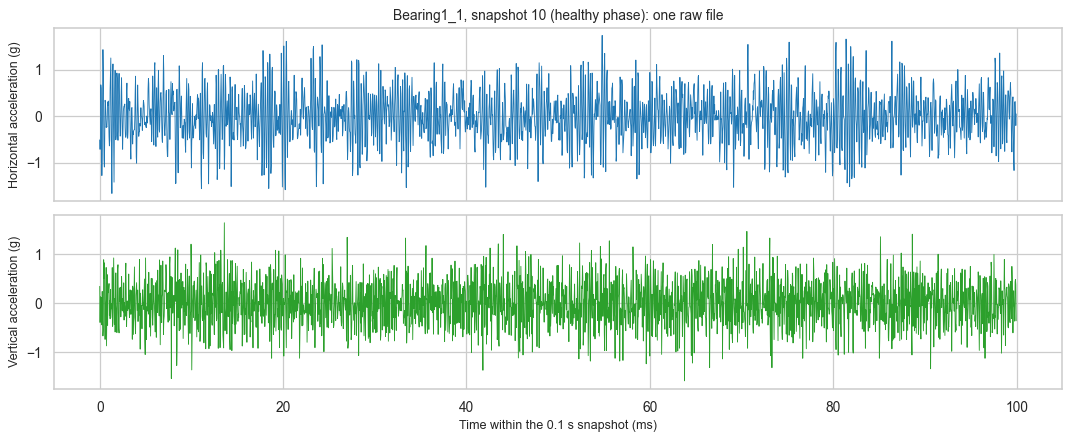

**Figure 2.** One raw snapshot. The time base check passed (39 µs between samples). Horizontal peak 1.74 g, vertical peak 1.64 g: a healthy bearing is a low-level, noise-like signal.

In [4]:
sample_path = C.DATASET / "Learning_set" / "Bearing1_1" / "acc_00010.csv"
arr, sep = F.read_snapshot(sample_path)
cols6 = ["hour", "minute", "second", "microsecond", "horizontal_acc_g", "vertical_acc_g"]
sample = pd.DataFrame(arr, columns=cols6)
print(f"file: {sample_path.name} | rows: {len(sample)} | delimiter: '{sep}' | duration: {len(sample)/C.FS*1000:.0f} ms at {C.FS/1000:.1f} kHz")
display(sample.head(5))
R.show("""| Column | Meaning (official description [2] Table 2) |
|---|---|
| 1 hour, 2 minute, 3 second | wall-clock time stamp of the sample |
| 4 microsecond | µs part of the time stamp (so consecutive rows are 1/25600 s = 39.06 µs apart) |
| 5 horizontal acceleration | accelerometer on the horizontal axis, in *g* |
| 6 vertical acceleration | accelerometer on the vertical axis, in *g* |
""")
assert np.allclose(np.diff(arr[:, 3]).mean(), 1e6 / C.FS, rtol=0.02), "time base of the file is not 25.6 kHz"
t_ms = np.arange(len(sample)) / C.FS * 1000
fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax[0].plot(t_ms, sample.horizontal_acc_g, lw=0.7, color="#1f77b4"); ax[0].set_ylabel("Horizontal acceleration (g)")
ax[1].plot(t_ms, sample.vertical_acc_g, lw=0.7, color="#2ca02c"); ax[1].set_ylabel("Vertical acceleration (g)"); ax[1].set_xlabel("Time within the 0.1 s snapshot (ms)")
ax[0].set_title("Bearing1_1, snapshot 10 (healthy phase): one raw file")
plt.tight_layout(); R.savefig(fig, "fig02_sample_raw_signal.png"); plt.show()
R.show(f"**Figure 2.** One raw snapshot. The time base check passed (39 µs between samples). Horizontal peak {sample.horizontal_acc_g.abs().max():.2f} g, vertical peak {sample.vertical_acc_g.abs().max():.2f} g: a healthy bearing is a low-level, noise-like signal.")

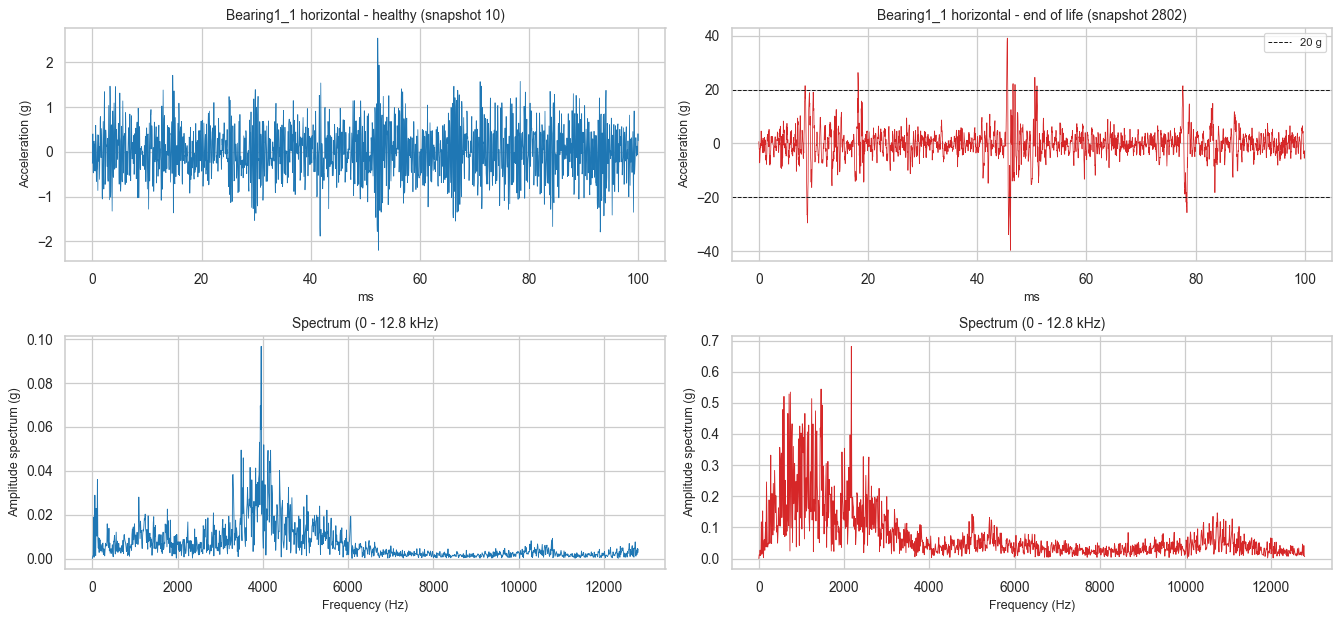

**Figure 3.** The same bearing early and at the end. The end-of-life snapshot shows impacts far beyond the healthy level and energy spread over a broad frequency range. This motivates amplitude features (RMS, peak, kurtosis) and spectral-shape features (centroid, spread, band energies).

In [5]:
# Figure 3 - healthy vs degraded snapshot of the same bearing (time signal + spectrum)
b = "Bearing1_1"; n_b = int(audit.loc[b, "acc_files"])
early, late = 10, n_b - 1
fig, ax = plt.subplots(2, 2, figsize=(15, 7))
for j, (idx, lab) in enumerate([(early, "healthy (snapshot 10)"), (late, f"end of life (snapshot {late})")]):
    a, _ = F.read_snapshot(C.DATASET / "Learning_set" / b / f"acc_{idx+1:05d}.csv")
    ax[0, j].plot(t_ms, a[:, 4], lw=0.6, color="#d62728" if j else "#1f77b4"); ax[0, j].set_title(f"{b} horizontal - {lab}")
    ax[0, j].set_ylabel("Acceleration (g)"); ax[0, j].set_xlabel("ms")
    if j: ax[0, j].axhline(20, color="k", ls="--", lw=0.8, label="20 g"); ax[0, j].axhline(-20, color="k", ls="--", lw=0.8); ax[0, j].legend()
    x = a[:, 4] - a[:, 4].mean(); P = np.abs(np.fft.rfft(x)) / len(x)
    ax[1, j].plot(np.fft.rfftfreq(len(x), 1 / C.FS), P, lw=0.7, color="#d62728" if j else "#1f77b4")
    ax[1, j].set_xlabel("Frequency (Hz)"); ax[1, j].set_ylabel("Amplitude spectrum (g)"); ax[1, j].set_title("Spectrum (0 - 12.8 kHz)")
plt.tight_layout(); R.savefig(fig, "fig03_healthy_vs_degraded.png"); plt.show()
R.show("**Figure 3.** The same bearing early and at the end. The end-of-life snapshot shows impacts far beyond the healthy level and energy spread over a broad frequency range. This motivates amplitude features (RMS, peak, kurtosis) and spectral-shape features (centroid, spread, band energies).")

## 7. Exploratory Data Analysis (learning bearings only)

**WHAT** – look at a simple **health indicator** (the log of the combined RMS of both accelerometers) over the life of the 6 learning bearings.
**WHY** – to see *how* real bearings degrade: slowly, suddenly, or with temporary bumps. This decides what kind of prediction is even possible.
**EXPECT** – some bearings show a long gradual rise; others stay flat until the last minutes.
**RULE.** Only *learning* bearings are shown here. Test bearings are shown for description only after the design is frozen (Section 22).

snapshots kept: 24633 of 24889 | Bearing1_4 kept 1172 of 1428 (cut at the official end of life)


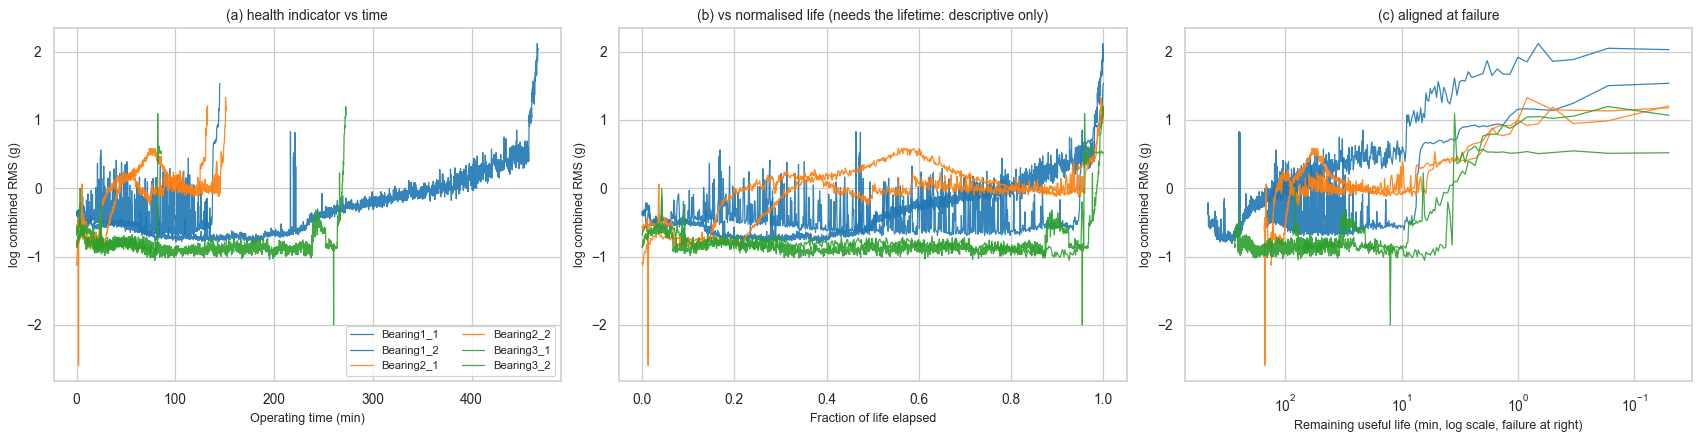

,lifetime_min,phase_min@5%,phase_min@10%,phase_min@20%
bearing,,,,
Bearing1_1,467.0,235.3,225.0,146.3
Bearing1_2,145.0,9.0,7.7,7.3
Bearing2_1,151.7,127.2,126.7,124.7
Bearing2_2,132.7,101.7,100.5,97.3
Bearing3_1,85.7,3.8,3.8,3.8
Bearing3_2,272.7,9.0,8.7,7.8


**Figure 4.** Health indicator (log of combined RMS) of the six learning bearings. Panel (c) aligns all bearings at failure on a log axis: the indicator becomes clearly elevated only in the last minutes for several bearings. The table lists the length of the final degradation phase (descriptive, hindsight-based, learning bearings only) for three sensitivity values of the threshold.

In [6]:
# Data table used from here on: keeps snapshots up to the OFFICIAL end of life and attaches RUL targets (from failure time only)
table = D.build_table(raw)
feats = F.transform(table)                 # fixed transform, no fitted statistics
assert set(table.bearing.unique()) == set(C.LEARNING + C.TEST)
print("snapshots kept:", len(table), "of", len(raw), "| Bearing1_4 kept", int((table.bearing == 'Bearing1_4').sum()), "of", int((raw.bearing == 'Bearing1_4').sum()), "(cut at the official end of life)")

lrn = table[table.bearing.isin(C.LEARNING)].copy()
lrn["hi"] = np.nan
for b in C.LEARNING:
    m = lrn.bearing == b; lrn.loc[m, "hi"] = A.combined_rms_hi(lrn[m])
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for b in C.LEARNING:
    g = lrn[lrn.bearing == b]; c = COND_COLOR[C.condition_of(b)]
    ax[0].plot(g.time_min, g.hi, lw=1, color=c, alpha=0.9, label=b)
    ax[1].plot(g.time_min / g.time_min.max(), g.hi, lw=1, color=c, alpha=0.9)
    ax[2].plot(np.maximum(g.rul_min, 0.05), g.hi, lw=1, color=c, alpha=0.9)
ax[0].set_xlabel("Operating time (min)"); ax[0].set_title("(a) health indicator vs time"); ax[0].legend(ncol=2)
ax[1].set_xlabel("Fraction of life elapsed"); ax[1].set_title("(b) vs normalised life (needs the lifetime: descriptive only)")
ax[2].set_xscale("log"); ax[2].invert_xaxis(); ax[2].set_xlabel("Remaining useful life (min, log scale, failure at right)"); ax[2].set_title("(c) aligned at failure")
for a_ in ax: a_.set_ylabel("log combined RMS (g)")
plt.tight_layout(); R.savefig(fig, "fig04_health_indicator_learning.png"); plt.show()
ph = A.phase_table(table, C.LEARNING); display(ph)
R.show("**Figure 4.** Health indicator (log of combined RMS) of the six learning bearings. Panel (c) aligns all bearings at failure on a log axis: the indicator becomes clearly elevated only in the last minutes for several bearings. The table lists the length of the final degradation phase (descriptive, hindsight-based, learning bearings only) for three sensitivity values of the threshold.")

### 7.1 What did we find?
Learning bearings degrade in **different ways**: Bearing1_1 shows a long, slowly rising indicator; others (e.g. Bearing3_1, 3_2, 1_2) stay flat and rise only in the last few minutes; Bearing2_1 and 2_2 show level changes early in life that are not clearly damage. The table quantifies the *length of the final degradation phase* at three thresholds: for half of the learning bearings it is of the order of **4–10 minutes**.

**What this means.** A model cannot know that a bearing will fail in 60 minutes if the vibration is indistinguishable from a healthy bearing until 5 minutes before failure. This is a property of the data, not of the model, and it is why we later measure prediction quality **as a function of the horizon** (Section 11) and report abrupt bearings separately.

## 8. Health Indicator Analysis

**WHAT** – screen all candidate features on the **learning bearings only** using three descriptive measures: *trend* (Spearman correlation with operating time), *consistency* (how many learning bearings show a strong trend with the same sign), and *late shift* (robust z-score of the value in the last 60 minutes relative to the first 30 % of life).
**WHY** – the task asks us not to use features blindly. A useful health indicator should change with degradation, do so in the same direction for different bearings, and change *before* the very end.
**EXPECT** – amplitude features (RMS, peak) change strongly; some shape features change only for some bearings; band fractions may be inconsistent.
**HOW IT HELPS** – we keep the full, documented feature set (each feature is physically motivated; deep models can learn combinations) but use the screening to explain which features carry the degradation signal and to choose the indicator used for illustration and demo. The screening does **not** change the model inputs, so it cannot leak.

,trend_spearman,consistency,late_shift_z,abs_trend
feature,,,,
horiz_band_3_6k,-0.754,1.000,-2.788,0.754
vert_band_3_6k,-0.583,0.667,-2.557,0.583
horiz_spec_spread,0.504,0.500,1.819,0.504
horiz_band_6_12k,0.427,0.500,1.280,0.427
horiz_peak,0.413,0.500,1.021,0.413
horiz_p2p,0.406,0.500,0.974,0.406
vert_spec_centroid,0.402,0.500,1.101,0.402
vert_p2p,0.353,0.500,0.706,0.353
vert_peak,0.351,0.500,0.719,0.351


**Reading the screening (learning bearings only).** Most consistent whole-life trend: `horiz_band_3_6k` (consistency 1.00, trend -0.75), `vert_band_3_6k` (consistency 0.67, trend -0.58). For the amplitude features: `horiz_rms` trend +0.25, consistency 0.33; `vert_rms` trend +0.20, consistency 0.33. The combined-RMS indicator of Section 7 is kept only as the standard *descriptive* indicator for illustration and the demo; it is not a model-input choice.

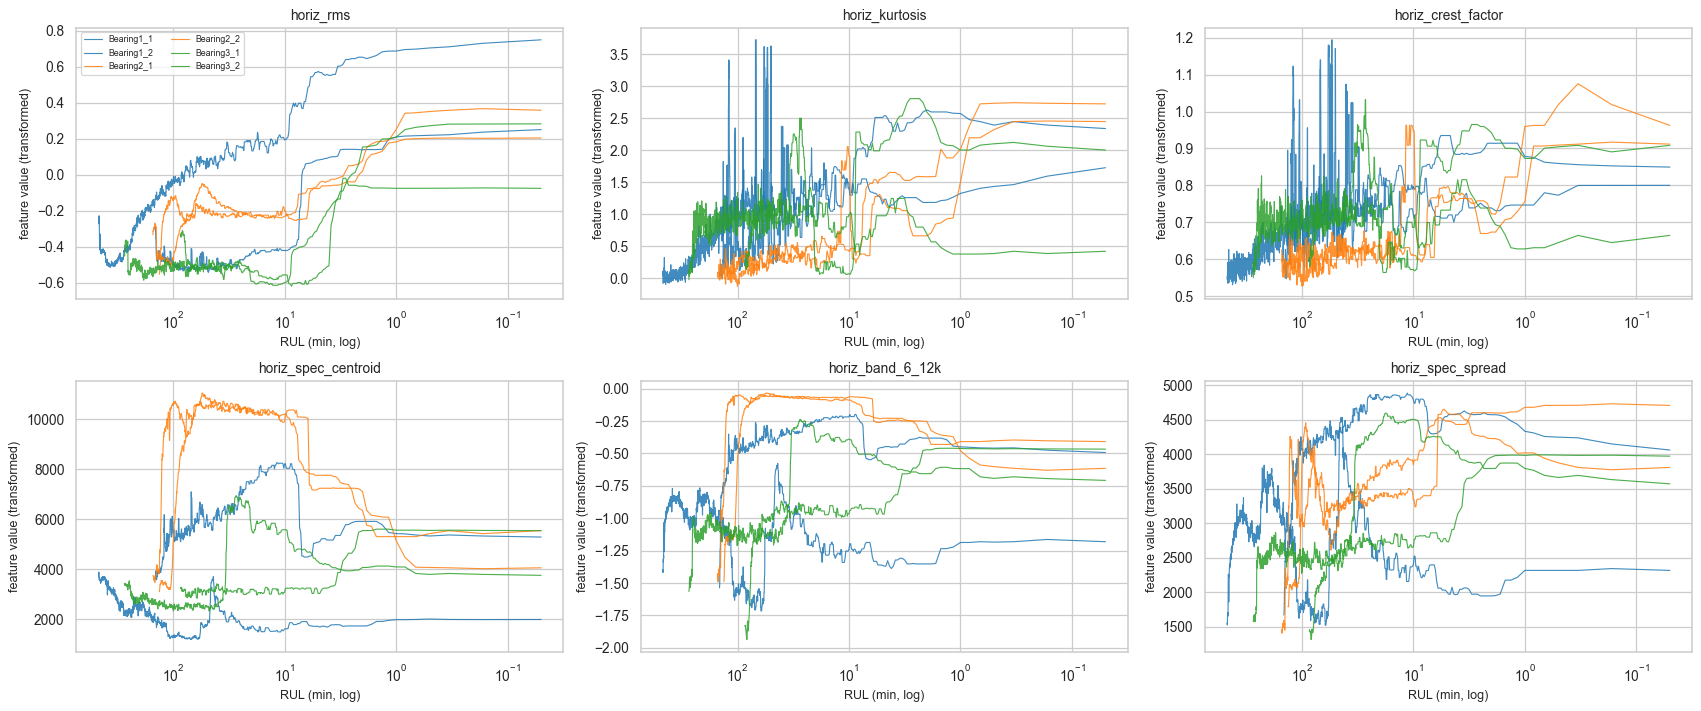

**Figure 5.** Selected features against remaining life on the six learning bearings (median-smoothed for readability only; models use unsmoothed values). Features move mostly within the last tens of minutes, and their absolute level differs between bearings.

In [7]:
screen = A.feature_screening(table, feats, C.LEARNING).sort_values("consistency", ascending=False)
screen["abs_trend"] = screen.trend_spearman.abs()
display(screen.sort_values(["consistency", "abs_trend"], ascending=False).round(3))
top_c = screen.sort_values("consistency", ascending=False).head(2)
R.show(f"**Reading the screening (learning bearings only).** Most consistent whole-life trend: " + ", ".join(f"`{i}` (consistency {r.consistency:.2f}, trend {r.trend_spearman:+.2f})" for i, r in top_c.iterrows()) +
       f". For the amplitude features: `horiz_rms` trend {screen.loc['horiz_rms','trend_spearman']:+.2f}, consistency {screen.loc['horiz_rms','consistency']:.2f}; `vert_rms` trend {screen.loc['vert_rms','trend_spearman']:+.2f}, consistency {screen.loc['vert_rms','consistency']:.2f}. "
       "The combined-RMS indicator of Section 7 is kept only as the standard *descriptive* indicator for illustration and the demo; it is not a model-input choice.")
top6 = ["horiz_rms", "horiz_kurtosis", "horiz_crest_factor", "horiz_spec_centroid", "horiz_band_6_12k", "horiz_spec_spread"]
fig, axes = plt.subplots(2, 3, figsize=(19, 8)); axes = axes.ravel()
for a_, f in zip(axes, top6):
    for b in C.LEARNING:
        m = (table.bearing == b).values
        a_.plot(np.maximum(table.loc[m, "rul_min"], 0.05), feats.loc[m, f].rolling(9, min_periods=1, center=True).median(), lw=0.9, color=COND_COLOR[C.condition_of(b)], alpha=0.85, label=b)
    a_.set_xscale("log"); a_.invert_xaxis(); a_.set_title(f); a_.set_xlabel("RUL (min, log)"); a_.set_ylabel("feature value (transformed)")
axes[0].legend(ncol=2, fontsize=7)
plt.tight_layout(); R.savefig(fig, "fig05_feature_vs_life_learning.png"); plt.show()
R.show("**Figure 5.** Selected features against remaining life on the six learning bearings (median-smoothed for readability only; models use unsmoothed values). Features move mostly within the last tens of minutes, and their absolute level differs between bearings.")

### 8.1 What did we find?

In [8]:
n_cons = int((screen.consistency > 0.5).sum()); n_shift = int((screen.late_shift_z.abs() > 1).sum())
late_top = screen[screen.index != "horiz_spec_peak_freq"].late_shift_z.abs().sort_values(ascending=False).head(5)
R.show(f"* **Over the whole life, hardly any feature is a consistent monotone indicator across bearings**: only {n_cons} of 34 features have consistency > 0.5, and the most consistent ones (3-6 kHz band fractions) *decrease* as damage grows. A typical reason is visible in Figures 4-5: vibration often *falls* during run-in early in life and rises only near the end, so a whole-life trend statistic is a poor criterion.\n\n"
       f"* **Features do move late**: {n_shift} of 34 features shift by more than one robust standard deviation in the last 60 minutes relative to the early baseline; strongest: " + ", ".join(f"`{i}` ({v:.1f})" for i, v in late_top.items()) + ".\n\n"
       "* **Consequence.** No single feature or fixed threshold is a robust health indicator across these bearings. This supports giving a learned model a *window of many features*, and it warns that hand-set thresholds (for example 'RMS above x') would not transfer between bearings. Our screening is descriptive: it does not choose the model inputs.")

* **Over the whole life, hardly any feature is a consistent monotone indicator across bearings**: only 2 of 34 features have consistency > 0.5, and the most consistent ones (3-6 kHz band fractions) *decrease* as damage grows. A typical reason is visible in Figures 4-5: vibration often *falls* during run-in early in life and rises only near the end, so a whole-life trend statistic is a poor criterion.

* **Features do move late**: 18 of 34 features shift by more than one robust standard deviation in the last 60 minutes relative to the early baseline; strongest: `horiz_band_3_6k` (2.8), `vert_band_3_6k` (2.6), `horiz_shape_factor` (1.9), `horiz_spec_spread` (1.8), `horiz_spec_centroid` (1.8).

* **Consequence.** No single feature or fixed threshold is a robust health indicator across these bearings. This supports giving a learned model a *window of many features*, and it warns that hand-set thresholds (for example 'RMS above x') would not transfer between bearings. Our screening is descriptive: it does not choose the model inputs.

## 9. Feature Engineering

**WHAT** – one fixed feature pipeline: from each 0.1 s snapshot and each of the two channels we compute 17 features (9 time-domain, 4 spectral-shape, 4 band-energy fractions) = **34 features**. Heavy-tailed features are compressed with a **fixed, non-fitted** transform chosen from the distribution diagnostics of Section 10 (not from any model result): log10 for positive amplitude/ratio features (RMS, peak, peak-to-peak, spectral energy, crest/shape/impulse/margin factors), log10(x + 1e-6) for the four band fractions, and signed log1p for kurtosis and skewness.
**WHY** – the network receives compact, physically meaningful numbers instead of 2560 raw samples, which is important with only 6 learning bearings. The standard deviation was intentionally **not** included: with a near-zero mean it duplicates RMS.
**CAUSALITY** – every feature is computed from **one snapshot only**. A feature at time *t* therefore cannot depend on the future; Section 12 verifies this with automated tests.

In [9]:
doc = pd.DataFrame([{"feature": k, "formula": v[0], "physical meaning / why it may indicate degradation": v[1],
                     "transform": ("log10" if k in F._LOG_BASE else ("log10(x+1e-6)" if k in F._FRAC_BASE else ("signed log1p" if k in F._SLOG_BASE else "none")))} for k, v in F.FEATURE_DOC.items()]).set_index("feature")
pd.set_option("display.max_colwidth", 140); display(doc)
print(f"{len(F.BASE)} features per channel x 2 channels = {len(F.FEATURES)} features; transforms: log10 on {len(F.LOG_FEATURES)}, log10(x+1e-6) on {len(F.FRAC_FEATURES)}, signed log1p on {len(F.SLOG_FEATURES)}")
doc.to_csv(C.ARTIFACTS / "feature_documentation.csv")
json.dump(F.FEATURES, open(C.ARTIFACTS / "feature_names.json", "w"), indent=1)

,formula,physical meaning / why it may indicate degradation,transform
feature,,,
rms,sqrt(mean(x^2)),Overall vibration energy; grows as defects enlarge and friction/impacts increase.,log10
peak,max|x|,Largest instantaneous shock; sensitive to single strong impacts (also to noise spikes).,log10
p2p,max(x)-min(x),Total excursion; similar to peak but based on the signed range.,log10
kurtosis,mean((x-mu)^4)/sigma^4 - 3,"Impulsiveness. About 0 for smooth Gaussian vibration, rises when sharp impacts appear (spalls, cracks).",signed log1p
skewness,mean((x-mu)^3)/sigma^3,Asymmetry of the amplitude distribution; one-sided impacts change it.,signed log1p
crest_factor,peak/rms,"Peak-to-average ratio; rises early with isolated impacts, falls when damage becomes continuous.",log10
shape_factor,rms/mean|x|,Waveform shape; changes when the amplitude distribution departs from Gaussian.,log10
impulse_factor,peak/mean|x|,Sharpness of impulses relative to the mean level.,log10
margin_factor,peak/(mean(sqrt|x|))^2,Peak relative to a low-order mean; emphasises rare large peaks (classical incipient-fault indicator).,log10


17 features per channel x 2 channels = 34 features; transforms: log10 on 16, log10(x+1e-6) on 8, signed log1p on 4


## 10. Feature Analysis: quality checks, distributions, correlation, scaling

**WHAT** – check for NaN/Inf, look at distributions and outliers, and compute the correlation between features. **Learning bearings only** are used for these statistics.
**WHY** – redundant features (for example RMS and spectral energy) waste capacity and can make importance analyses misleading; heavy tails would dominate a neural network unless scaled.
**EXPECT** – strong correlations inside the amplitude group; long tails before the log transform.

NaN/Inf in the 34 features (all 17 bearings): 0 0


,skew_raw,skew_after_transform,frac_beyond_5MAD
horiz_kurtosis,16.09,2.03,0.02
horiz_spec_energy,15.01,1.25,0.01
horiz_skewness,-14.08,-3.06,0.03
vert_spec_energy,13.10,1.08,0.00
vert_band_0_1k,12.55,-0.31,0.00
horiz_shape_factor,10.01,4.29,0.02
vert_shape_factor,7.27,5.92,0.07
horiz_margin_factor,7.14,1.85,0.01
horiz_p2p,6.90,1.34,0.01
horiz_peak,6.86,1.34,0.01


max |skewness|: raw 16.1 -> after transform 5.9


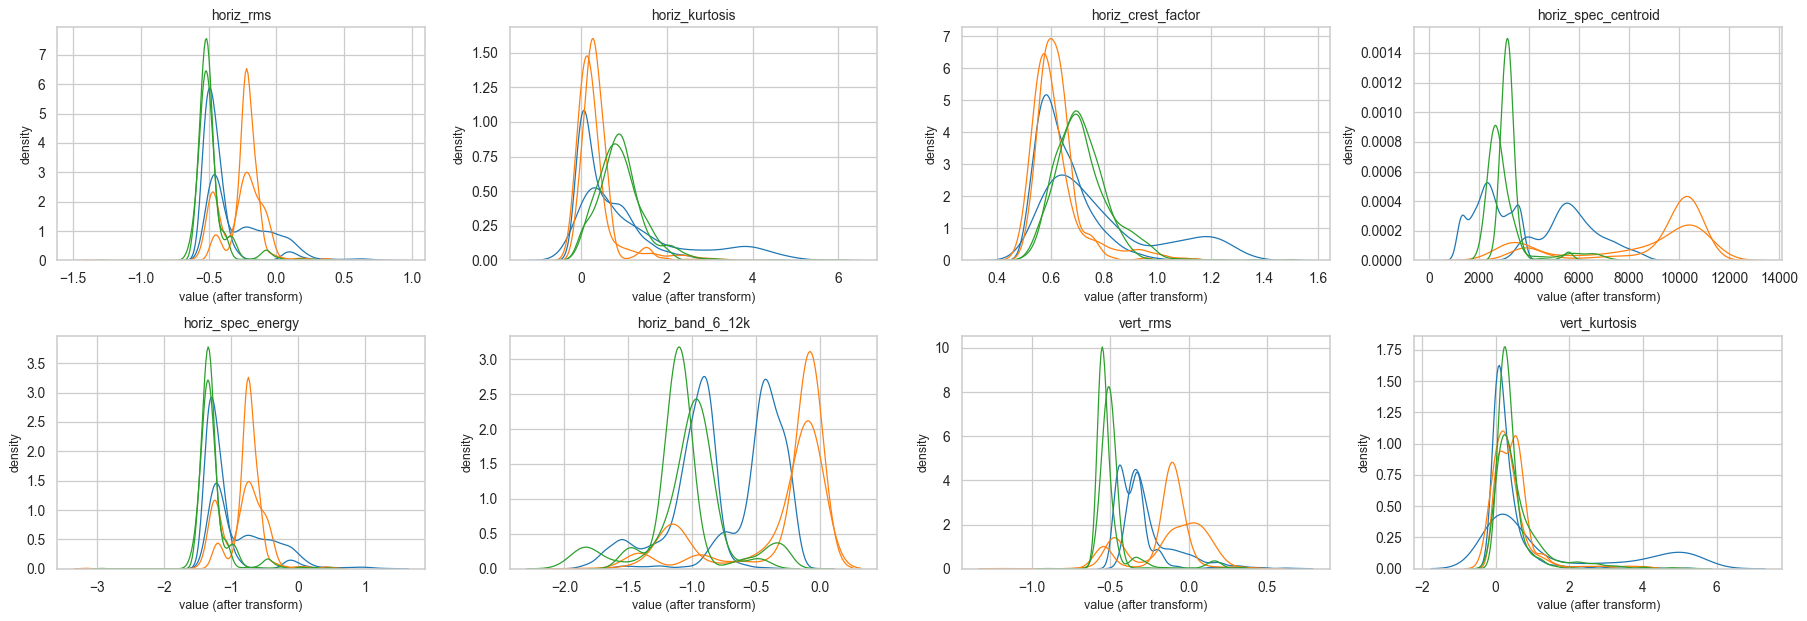

**Figure 6.** Feature distributions per learning bearing (one curve each, colour = operating condition). The curves differ between bearings even in the healthy phase, confirming that a global scaling fitted on the training bearings is required (Section 13) and that per-bearing offsets are a real source of error.

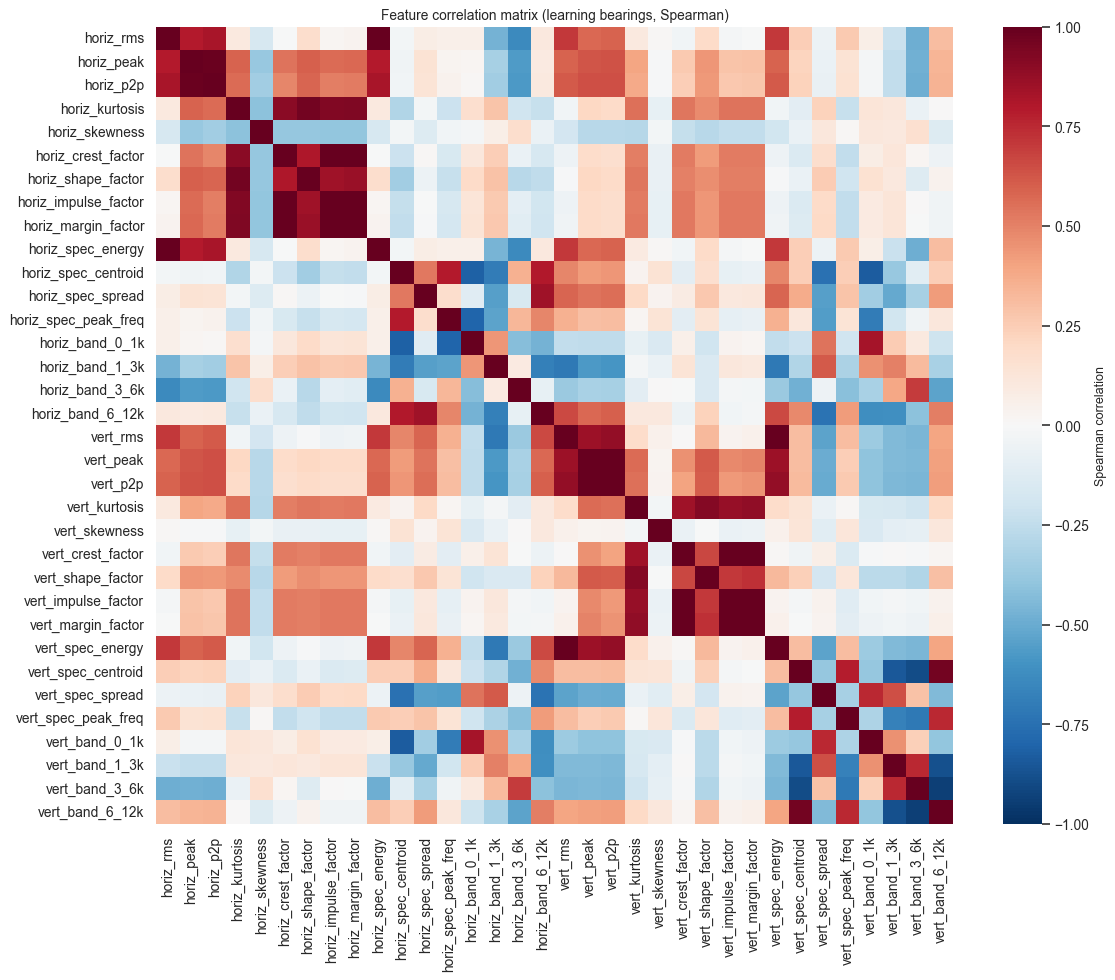

**Figure 7.** Spearman correlation of the 34 features. **12 feature pairs have |rho| > 0.95** (for example: `vert_rms`~`vert_spec_energy`, `horiz_rms`~`horiz_spec_energy`, `horiz_impulse_factor`~`horiz_margin_factor`, `vert_impulse_factor`~`vert_margin_factor`). Amplitude features form one highly redundant block; shape and band features are less correlated. Redundant inputs are kept (they are cheap and each is documented), and the importance analysis of Section 20 is therefore reported per feature *and* interpreted with this redundancy in mind.

In [10]:
assert not feats.isna().any().any() and not np.isinf(feats.values).any(), "NaN/Inf in features"
lm = table.bearing.isin(C.LEARNING).values
print("NaN/Inf in the 34 features (all 17 bearings):", int(feats.isna().sum().sum()), int(np.isinf(feats.values).sum()))
raw_l = table.loc[lm, F.FEATURES]; tr_l = feats.loc[lm]
out_frac = (np.abs(tr_l - tr_l.median()) / (1.4826 * (tr_l - tr_l.median()).abs().median() + 1e-9) > 5).mean().sort_values(ascending=False)
sk_tbl = pd.DataFrame({"skew_raw": raw_l.skew(), "skew_after_transform": tr_l.skew(), "frac_beyond_5MAD": out_frac}); display(sk_tbl.sort_values("skew_raw", key=abs, ascending=False).head(10).round(2))
print(f"max |skewness|: raw {sk_tbl.skew_raw.abs().max():.1f} -> after transform {sk_tbl.skew_after_transform.abs().max():.1f}")

fig, ax = plt.subplots(2, 4, figsize=(20, 7)); ax = ax.ravel()
for a_, f in zip(ax, ["horiz_rms", "horiz_kurtosis", "horiz_crest_factor", "horiz_spec_centroid", "horiz_spec_energy", "horiz_band_6_12k", "vert_rms", "vert_kurtosis"]):
    for b in C.LEARNING:
        sns.kdeplot(feats.loc[(table.bearing == b).values, f], ax=a_, lw=1, color=COND_COLOR[C.condition_of(b)], warn_singular=False)
    a_.set_title(f"{f}"); a_.set_xlabel("value (after transform)"); a_.set_ylabel("density")
plt.tight_layout(); R.savefig(fig, "fig06_feature_distributions.png"); plt.show()
R.show("**Figure 6.** Feature distributions per learning bearing (one curve each, colour = operating condition). The curves differ between bearings even in the healthy phase, confirming that a global scaling fitted on the training bearings is required (Section 13) and that per-bearing offsets are a real source of error.")

corr = feats.loc[lm].corr(method="spearman")
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, xticklabels=True, yticklabels=True, cbar_kws={"label": "Spearman correlation"})
ax.set_title("Feature correlation matrix (learning bearings, Spearman)"); plt.tight_layout(); R.savefig(fig, "fig07_feature_correlation.png"); plt.show()
pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack(); hi_pairs = pairs[pairs.abs() > 0.95].sort_values(ascending=False)
R.show(f"**Figure 7.** Spearman correlation of the 34 features. **{len(hi_pairs)} feature pairs have |rho| > 0.95** (for example: " + ", ".join(f"`{a}`~`{b}`" for (a, b) in hi_pairs.index[:4]) +
       "). Amplitude features form one highly redundant block; shape and band features are less correlated. Redundant inputs are kept (they are cheap and each is documented), and the importance analysis of Section 20 is therefore reported per feature *and* interpreted with this redundancy in mind.")

### 10.1 What did we find?
No NaN or infinite values exist. The fixed log / signed-log transforms remove most of the heavy tails (see the skewness table: raw skewness up to about 16 falls to about 6 at most). Correlation analysis shows that amplitude features are largely redundant, and per-bearing distributions differ noticeably. **Consequence:** a `StandardScaler` **fitted only on training bearings** is used inside every experiment, and importance results must not be over-interpreted for individual members of a correlated block.

## 11. Target Definition — choosing the formulation

### 11.1 Candidate formulations

| | Formulation | Advantage | Limitation for this dataset |
|---|---|---|---|
| A | **Direct RUL (minutes)** | the official challenge task [2] | a healthy-looking bearing may have 400 or 20 minutes left: uncapped targets contain unpredictable variance |
| A′ | **Capped RUL (minutes)** | removes the unpredictable early part; standard in prognostics [8] | needs a cap (design choice → sensitivity analysis) |
| B | **Normalised RUL (fraction of life)** | comparable across bearings | needs the total lifetime = future information; **not deployable** |
| C | **Stage classification** (Normal / Warning / Critical by remaining time) | operationally meaningful, robust | coarse; boundaries are a design choice |
| D | **Degradation vs healthy detection** | physically motivated | the label needs a vibration-based *onset*, which is found with **hindsight** and depends on a threshold; not usable as a real-time claim |
| E | **Multi-task (A′ + C)** | one model gives a number and an alarm level; the stage task can regularise the regression | only helps if the tasks are consistent |

**Decision principle (fixed before running the study below).** Prefer targets that (i) use *only the failure time* (no hindsight on the vibration), (ii) are deployable for a running machine, (iii) match the official protocol. This selects **E = capped RUL + stage**, with cap = 120 min (a two-hour planning horizon) and stage boundaries at 60 min (Warning) and 20 min (Critical). B is excluded because it is not deployable; D is used only for description (Section 7 / 22) and never as a training label.

### 11.2 Empirical check on the learning bearings (leave-one-bearing-out, fast models only)
**WHAT** – measure, on held-out learning bearings, how well vibration predicts each formulation compared with predicting a constant.
**WHY** – to test the choice above against the data rather than only against arguments, and to see how prediction quality changes with the horizon.

In [11]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_auc_score, f1_score

folds_dev = D.lobo_folds()
L.check_splits(folds_dev)
def tab_windows(fold):
    sc = D.fit_scaler(feats, table, fold["train"] + [fold["val"]])          # here validation bearing is simply another training bearing
    Xtr, mtr = D.make_windows(table, feats, fold["train"] + [fold["val"]], sc); Xte, mte = D.make_windows(table, feats, [fold["held_out"]], sc)
    return D.window_summary(Xtr), mtr, D.window_summary(Xte), mte

rows = []
for fi, f in enumerate(folds_dev):
    Ttr, mtr, Tte, mte = tab_windows(f)
    life_tr = table[table.bearing.isin(f["train"] + [f["val"]])].groupby("bearing").eol_s.first() / 60
    def frac(meta): return (meta.time_min / (meta.time_min + meta.rul_min)).values                       # B: fraction of life elapsed
    rf = RandomForestRegressor(150, min_samples_leaf=5, n_jobs=-1, random_state=SEED)
    # A: uncapped RUL minutes
    rf.fit(Ttr, mtr.rul_min); pa = rf.predict(Tte); rows.append(dict(fold=fi, form="A  uncapped RUL (min)", model_mae=np.abs(pa - mte.rul_min).mean(), const_mae=np.abs(mtr.rul_min.mean() - mte.rul_min).mean()))
    # A': capped RUL minutes (cap 120)
    rf.fit(Ttr, mtr.rul_cap_min); pc = rf.predict(Tte); rows.append(dict(fold=fi, form="A' capped RUL, cap 120 (min)", model_mae=np.abs(pc - mte.rul_cap_min).mean(), const_mae=np.abs(mtr.rul_cap_min.mean() - mte.rul_cap_min).mean()))
    # B: fraction of life (NOT deployable) - shown for comparison only
    rf.fit(Ttr, frac(mtr)); pb = rf.predict(Tte); rows.append(dict(fold=fi, form="B  life fraction (not deployable)", model_mae=np.abs(pb - frac(mte)).mean(), const_mae=np.abs(frac(mtr).mean() - frac(mte)).mean()))
    # C/E: stage classification macro-F1
    clf = RandomForestClassifier(150, min_samples_leaf=5, n_jobs=-1, random_state=SEED, class_weight="balanced").fit(Ttr, mtr.stage)
    rows.append(dict(fold=fi, form="C  3-stage classification (macro-F1)", model_mae=f1_score(mte.stage, clf.predict(Tte), average="macro", labels=[0, 1, 2], zero_division=0),
                     const_mae=f1_score(mte.stage, np.full(len(mte), np.bincount(mtr.stage).argmax()), average="macro", labels=[0, 1, 2], zero_division=0)))
form = pd.DataFrame(rows)
summ = form.groupby("form", sort=False).agg(model=("model_mae", "mean"), constant=("const_mae", "mean"))
summ["model_better_in_folds"] = form.assign(win=lambda d: np.where(d.form.str.contains("F1"), d.model_mae > d.const_mae, d.model_mae < d.const_mae)).groupby("form", sort=False).win.sum().astype(int).astype(str) + "/6"
display(summ.round(3))
R.show("**Reading the table.** For A, A' and B lower is better (minutes or fraction); for C higher is better. *constant* = predict the training mean (or majority class). Random Forest on tabular window summaries is used here only as a fast probe.")

,model,constant,model_better_in_folds
form,,,
A uncapped RUL (min),103.252,97.227,3/6
"A' capped RUL, cap 120 (min)",42.197,38.765,2/6
B life fraction (not deployable),0.199,0.246,5/6
C 3-stage classification (macro-F1),0.429,0.246,5/6


**Reading the table.** For A, A' and B lower is better (minutes or fraction); for C higher is better. *constant* = predict the training mean (or majority class). Random Forest on tabular window summaries is used here only as a fast probe.

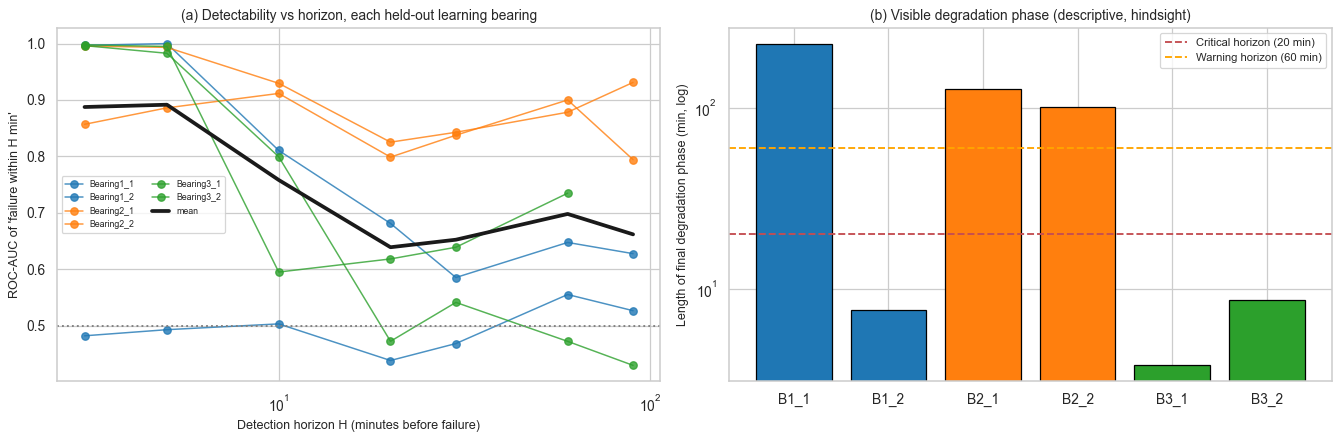

**Figure 8.** (a) Mean AUC of detecting 'failure within H minutes' falls from **0.89 (H=5 min)** to **0.70 (H=60 min)**, and for some bearings it is close to chance at long horizons. (b) The visible degradation phase of several learning bearings is shorter than the Warning horizon.

In [12]:
# Horizon analysis: how well can vibration detect "failure within H minutes"?  (Random Forest probe, LOBO, learning bearings only)
H = [3, 5, 10, 20, 30, 60, 90]
hz = []
for fi, f in enumerate(folds_dev):
    Ttr, mtr, Tte, mte = tab_windows(f)
    rf = RandomForestRegressor(150, min_samples_leaf=5, n_jobs=-1, random_state=SEED).fit(Ttr, mtr.rul_cap_min)
    score = -rf.predict(Tte)
    for h in H:
        y = (mte.rul_min <= h).astype(int)
        hz.append(dict(fold=fi, held_out=f["held_out"], H=h, auc=roc_auc_score(y, score) if 0 < y.sum() < len(y) else np.nan, positives=float(y.mean())))
hz = pd.DataFrame(hz)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for b, g in hz.groupby("held_out"):
    ax[0].plot(g.H, g.auc, marker="o", lw=1.2, label=b, color=COND_COLOR[C.condition_of(b)], alpha=0.8)
ax[0].plot(hz.groupby("H").auc.mean(), "k-", lw=3, label="mean"); ax[0].axhline(0.5, color="gray", ls=":")
ax[0].set_xscale("log"); ax[0].set_xlabel("Detection horizon H (minutes before failure)"); ax[0].set_ylabel("ROC-AUC of 'failure within H min'"); ax[0].set_title("(a) Detectability vs horizon, each held-out learning bearing"); ax[0].legend(fontsize=7, ncol=2)
lifemin = table.groupby("bearing").eol_s.first() / 60
ph10 = A.phase_table(table, C.LEARNING)["phase_min@10%"]
ax[1].bar(range(6), ph10.values, color=[COND_COLOR[C.condition_of(b)] for b in ph10.index], edgecolor="black")
ax[1].set_xticks(range(6)); ax[1].set_xticklabels([b.replace("Bearing", "B") for b in ph10.index]); ax[1].set_yscale("log")
ax[1].axhline(20, color="r", ls="--", label="Critical horizon (20 min)"); ax[1].axhline(60, color="orange", ls="--", label="Warning horizon (60 min)")
ax[1].set_ylabel("Length of final degradation phase (min, log)"); ax[1].set_title("(b) Visible degradation phase (descriptive, hindsight)"); ax[1].legend()
plt.tight_layout(); R.savefig(fig, "fig08_horizon_detectability.png"); plt.show()
m_auc = hz.groupby("H").auc.mean()
R.show(f"**Figure 8.** (a) Mean AUC of detecting 'failure within H minutes' falls from **{m_auc[5]:.2f} (H=5 min)** to **{m_auc[60]:.2f} (H=60 min)**, and for some bearings it is close to chance at long horizons. (b) The visible degradation phase of several learning bearings is shorter than the Warning horizon.")

### 11.3 What did we find, and what is the frozen target?

In [13]:
r = summ.copy(); a_, ac_, b_, c_ = r.iloc[0], r.iloc[1], r.iloc[2], r.iloc[3]
R.show("\n\n".join([
    f"* **Direct / capped RUL in minutes (A, A'):** the Random-Forest probe does **not** clearly beat the constant prediction (A: {a_.model:.1f} vs {a_.constant:.1f} min, better in {r.model_better_in_folds.iloc[0]} folds; A': {ac_.model:.1f} vs {ac_.constant:.1f} min, {r.model_better_in_folds.iloc[1]} folds). Minute-level RUL across bearings is therefore **not supported** by this data.",
    f"* **Life fraction (B)** gives lower error ({b_.model:.2f} vs {b_.constant:.2f}, {r.model_better_in_folds.iloc[2]} folds) because the target itself is normalised by the bearing's total lifetime - information that is unknown for a running machine. **Not deployable; not used.**",
    f"* **Stage classification (C)** beats the majority-class predictor in {r.model_better_in_folds.iloc[3]} folds (macro-F1 {c_.model:.2f} vs {c_.constant:.2f}), i.e. there is real but moderate signal about *how close to failure* a bearing is.",
    f"* **Detectability depends strongly on the horizon** (Figure 8): the mean AUC of 'failure within H min' is {m_auc[5]:.2f} at 5 min, {m_auc[20]:.2f} at 20 min and {m_auc[60]:.2f} at 60 min, and it is close to chance for the abrupt bearings at long horizons.",
    "**Frozen decision.** Keep formulation **E** (capped RUL + stage) with the *a priori* horizons (cap 120 min, Warning <= 60 min, Critical <= 20 min); they are **not tuned** to obtain better scores. Because horizon matters so much, every model is also evaluated at several horizons (AUC at 5, 10, 20, 30, 60 min). We record explicitly that **the dataset does not support reliable early RUL prediction for bearings that fail abruptly**. No vibration-based onset label is used for training; the onset-style analysis (D) is descriptive only.",
    "**Remaining hindsight assumptions.** (1) Training uses the failure time of the learning bearings (standard supervised learning). (2) The cap and stage boundaries are design choices fixed a priori; a sensitivity analysis follows. (3) The descriptive onset/phase-length tables use the whole trajectory (hindsight) and are never used as labels."]))

* **Direct / capped RUL in minutes (A, A'):** the Random-Forest probe does **not** clearly beat the constant prediction (A: 103.3 vs 97.2 min, better in 3/6 folds; A': 42.2 vs 38.8 min, 2/6 folds). Minute-level RUL across bearings is therefore **not supported** by this data.

* **Life fraction (B)** gives lower error (0.20 vs 0.25, 5/6 folds) because the target itself is normalised by the bearing's total lifetime - information that is unknown for a running machine. **Not deployable; not used.**

* **Stage classification (C)** beats the majority-class predictor in 5/6 folds (macro-F1 0.43 vs 0.25), i.e. there is real but moderate signal about *how close to failure* a bearing is.

* **Detectability depends strongly on the horizon** (Figure 8): the mean AUC of 'failure within H min' is 0.89 at 5 min, 0.64 at 20 min and 0.70 at 60 min, and it is close to chance for the abrupt bearings at long horizons.

**Frozen decision.** Keep formulation **E** (capped RUL + stage) with the *a priori* horizons (cap 120 min, Warning <= 60 min, Critical <= 20 min); they are **not tuned** to obtain better scores. Because horizon matters so much, every model is also evaluated at several horizons (AUC at 5, 10, 20, 30, 60 min). We record explicitly that **the dataset does not support reliable early RUL prediction for bearings that fail abruptly**. No vibration-based onset label is used for training; the onset-style analysis (D) is descriptive only.

**Remaining hindsight assumptions.** (1) Training uses the failure time of the learning bearings (standard supervised learning). (2) The cap and stage boundaries are design choices fixed a priori; a sensitivity analysis follows. (3) The descriptive onset/phase-length tables use the whole trajectory (hindsight) and are never used as labels.

In [14]:
# Sensitivity of the conclusion to the cap (learning bearings, LOBO, Random Forest probe + Ridge): "skill" = 1 - MAE_model/MAE_constant
sens = []
for cap in [60, 120, 240]:
    for fi, f in enumerate(folds_dev):
        Ttr, mtr, Tte, mte = tab_windows(f)
        ytr = np.minimum(mtr.rul_min, cap); yte = np.minimum(mte.rul_min, cap)
        for name, mdl in [("Random Forest", RandomForestRegressor(150, min_samples_leaf=5, n_jobs=-1, random_state=SEED)), ("Ridge", Ridge(1.0))]:
            p = mdl.fit(Ttr, ytr).predict(Tte)
            sens.append(dict(cap=cap, model=name, fold=fi, skill=1 - np.abs(p - yte).mean() / np.abs(ytr.mean() - yte).mean(),
                             auc60=roc_auc_score(mte.rul_min <= 60, -p) if 0 < (mte.rul_min <= 60).sum() < len(mte) else np.nan))
sens = pd.DataFrame(sens)
display(sens.groupby(["cap", "model"]).agg(mean_skill=("skill", "mean"), folds_with_skill_gt0=("skill", lambda s: f"{(s>0).sum()}/6"), mean_AUC_60min=("auc60", "mean")).round(3))
R.show("**Cap sensitivity (learning bearings only).** Skill > 0 means better than the constant. The picture (little or negative skill in minutes, moderate detection AUC) does not change with the cap, so the conclusion is not an artefact of the chosen cap. Nothing was tuned on this table.")

mean_skill folds_with_skill_gt0  mean_AUC_60min
cap model                                                         
60  Random Forest      -0.547                  2/6           0.646
    Ridge              -0.523                  3/6           0.732
120 Random Forest      -0.062                  2/6           0.698
    Ridge              -0.298                  2/6           0.803
240 Random Forest      -0.053                  3/6           0.645
    Ridge              -0.197                  3/6           0.851

**Cap sensitivity (learning bearings only).** Skill > 0 means better than the constant. The picture (little or negative skill in minutes, moderate detection AUC) does not change with the cap, so the conclusion is not an artefact of the chosen cap. Nothing was tuned on this table.

## 12. Leakage Prevention — automated checks

**WHAT** – executable tests. If any of them fails, the notebook stops with an `AssertionError`.
**WHY** – claims of "no leakage" are worthless unless they are tested. Each test corresponds to a leakage route relevant to this dataset.

| Test | Leakage route it closes |
|---|---|
| splits are disjoint, use only learning bearings, every learning bearing is held out once | train/test contamination |
| scaler statistics equal the training-bearing statistics and differ from all-data statistics | normalisation leakage |
| **poison test**: destroying the held-out bearing's data changes nothing used for training | any hidden use of held-out data |
| **truncation test**: deleting all snapshots after time *t* leaves windows up to *t* unchanged | future information in inputs |
| windows are contiguous inside one bearing | windows across bearing boundaries |
| features recomputed independently from a single raw file match | cross-snapshot information in features |
| **targets are unchanged when the vibration features are shuffled** | vibration-based hindsight in targets |
| configuration snapshot is stored and re-checked before the test | test-driven design changes |

In [15]:
checks = {}
folds = D.lobo_folds()
checks["splits disjoint, learning-only, each bearing held out once"] = L.check_splits(folds)
for fi, f in enumerate(folds):
    sc_f = D.fit_scaler(feats, table, f["train"])
    checks[f"fold {fi}: scaler fitted on training bearings only"] = L.check_scaler_train_only(sc_f, feats, table, f["train"])
    checks[f"fold {fi}: poison test (held-out data cannot reach training)"] = L.check_poison(table, feats, f)
sc_all_chk = D.fit_scaler(feats, table, C.LEARNING)
for b in ("Bearing1_1", "Bearing2_4", "Bearing1_3"):
    n_b = int((table.bearing == b).sum())
    checks[f"{b}: truncation / causality test"] = L.check_window_causality(table, feats, sc_all_chk, b, [40, n_b // 2, n_b - 30])
Xchk, mchk = D.make_windows(table, feats, C.LEARNING, sc_all_chk)
checks["windows contiguous inside each bearing"] = L.check_window_boundaries(Xchk, mchk)
checks["features recomputed independently from single raw files (all 17 bearings)"] = L.check_features_single_snapshot(raw)
checks["targets depend only on failure time (feature-shuffle test)"] = L.check_targets_only_from_failure_time(raw, table)
assert not (set(C.TEST) & set(D.lobo_folds()[0]["train"])), "test bearing in training"
CFG_FROZEN = L.config_snapshot()
checks["configuration snapshot stored (re-checked before the test)"] = True
display(pd.DataFrame({"check": list(checks), "passed": list(checks.values())}))
assert all(checks.values())
R.show(f"**All {len(checks)} leakage checks passed.** Frozen configuration: `{CFG_FROZEN}`")

,check,passed
0,"splits disjoint, learning-only, each bearing held out once",True
1,fold 0: scaler fitted on training bearings only,True
2,fold 0: poison test (held-out data cannot reach training),True
3,fold 1: scaler fitted on training bearings only,True
4,fold 1: poison test (held-out data cannot reach training),True
5,fold 2: scaler fitted on training bearings only,True
6,fold 2: poison test (held-out data cannot reach training),True
7,fold 3: scaler fitted on training bearings only,True
8,fold 3: poison test (held-out data cannot reach training),True
9,fold 4: scaler fitted on training bearings only,True


**All 20 leakage checks passed.** Frozen configuration: `{'WINDOW': 16, 'RUL_CAP_MIN': 120.0, 'STAGE_CRITICAL_MIN': 20.0, 'STAGE_WARNING_MIN': 60.0, 'ALARM_PERSISTENCE': 3, 'BATCH': 64, 'LR': 0.001, 'MAX_EPOCHS': 40, 'PATIENCE': 6, 'HUBER_DELTA': 0.1, 'LOSS_WEIGHTS': (('risk_output', 0.5), ('rul_output', 1.0)), 'SEEDS_FINAL': (42, 43, 44), 'SEED_LOBO': 42}`

### 12.1 What did we find?
All automated checks passed. In particular the **poison test** shows that everything derived for training (windows, scaler, targets) is bit-identical even if the held-out bearing's data is replaced by noise, and the **truncation test** shows that model inputs at time *t* do not depend on any later snapshot. **This supports the claim that the validation estimates below are free of leakage from the held-out bearings.** It does not remove the *selection* effects discussed in Section 3 (which are disclosed, not hidden).

## 13. Train / Validation / Test Split

**WHAT** – define the data protocol and demonstrate why random window splitting would be wrong.
**PROTOCOL.**
* **Method development and model selection:** the 6 learning bearings with **leave-one-bearing-out (LOBO)**. In each of the 6 folds: one bearing is *held out* (scored), the next learning bearing in cyclic order is the *validation* bearing (used only for early stopping), the other 4 train the model.
* **Final test:** the 11 test bearings, scored once after the design is frozen (Section 22). The final models train on all 6 learning bearings for a number of epochs fixed from the LOBO early-stopping results.

**WHY random splitting is wrong.** Windows overlap by 15 of 16 snapshots; a random split puts near-copies of test windows into training. The cell below measures the effect with the same Random Forest on the same learning bearings.

,fold,held-out (scored),validation (early stopping),training
0,0,Bearing1_1,Bearing1_2,"Bearing2_1, Bearing2_2, Bearing3_1, Bearing3_2"
1,1,Bearing1_2,Bearing2_1,"Bearing1_1, Bearing2_2, Bearing3_1, Bearing3_2"
2,2,Bearing2_1,Bearing2_2,"Bearing1_1, Bearing1_2, Bearing3_1, Bearing3_2"
3,3,Bearing2_2,Bearing3_1,"Bearing1_1, Bearing1_2, Bearing2_1, Bearing3_2"
4,4,Bearing3_1,Bearing3_2,"Bearing1_1, Bearing1_2, Bearing2_1, Bearing2_2"
5,5,Bearing3_2,Bearing1_1,"Bearing1_2, Bearing2_1, Bearing2_2, Bearing3_1"


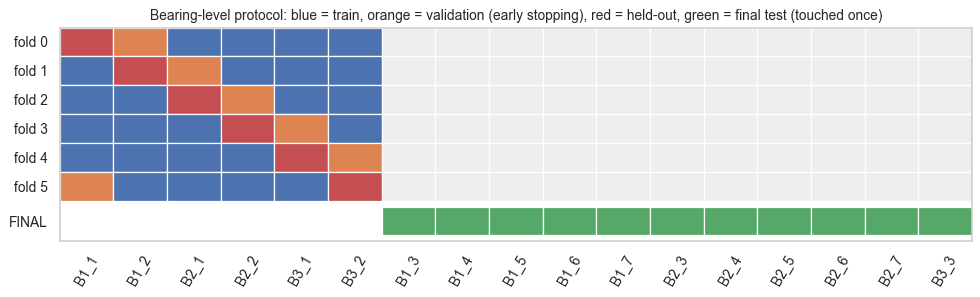

,MAE (min),AUC (failure within 60 min)
protocol,,
RANDOM window split (wrong),1.466,0.998
Bearing-level LOBO (correct),42.197,0.698


**Figure 9 / table.** Same model, same bearings: the random window split reports an MAE of **1.5 min** and AUC **1.00**, the correct bearing-level protocol **42.2 min** and **0.70**. The difference is pure leakage of near-duplicate windows. All results in this notebook use the bearing-level protocol.

In [16]:
fold_tbl = pd.DataFrame([{"fold": i, "held-out (scored)": f["held_out"], "validation (early stopping)": f["val"], "training": ", ".join(f["train"])} for i, f in enumerate(D.lobo_folds())])
display(fold_tbl)
fig, ax = plt.subplots(figsize=(11, 3.4))
colmap = {"train": "#4c72b0", "val": "#dd8452", "held": "#c44e52", "-": "#eeeeee", "test": "#55a868"}
grid = np.full((6, 17), "-", dtype=object)
for i, f in enumerate(D.lobo_folds()):
    for b in f["train"]: grid[i, (C.LEARNING + C.TEST).index(b)] = "train"
    grid[i, (C.LEARNING + C.TEST).index(f["val"])] = "val"; grid[i, (C.LEARNING + C.TEST).index(f["held_out"])] = "held"
    for b in C.TEST: grid[i, (C.LEARNING + C.TEST).index(b)] = "-"
for i in range(6):
    for j in range(17):
        ax.add_patch(plt.Rectangle((j, 5 - i), 1, 1, color=colmap[grid[i, j]], ec="white"))
for j in range(6, 17): ax.add_patch(plt.Rectangle((j, -1.2), 1, 1, color=colmap["test"], ec="white"))
ax.set_xlim(0, 17); ax.set_ylim(-1.4, 6); ax.set_xticks(np.arange(17) + 0.5); ax.set_xticklabels([b.replace("Bearing", "B") for b in C.LEARNING + C.TEST], rotation=60)
ax.set_yticks(list(np.arange(6) + 0.5) + [-0.7]); ax.set_yticklabels([f"fold {5-i}" for i in range(6)] + ["FINAL"]); ax.grid(False)
ax.set_title("Bearing-level protocol: blue = train, orange = validation (early stopping), red = held-out, green = final test (touched once)")
plt.tight_layout(); R.savefig(fig, "fig09_split_protocol.png"); plt.show()

# random-window split (WRONG protocol) vs bearing-level LOBO, same Random Forest, same learning bearings
sc_l = D.fit_scaler(feats, table, C.LEARNING); Xl, ml = D.make_windows(table, feats, C.LEARNING, sc_l); Tl = D.window_summary(Xl)
rng = np.random.default_rng(SEED); idx = rng.permutation(len(Tl)); cut = int(0.8 * len(idx)); tr_i, te_i = idx[:cut], idx[cut:]
rf = RandomForestRegressor(150, min_samples_leaf=5, n_jobs=-1, random_state=SEED).fit(Tl[tr_i], ml.rul_cap_min.values[tr_i])
p_rand = rf.predict(Tl[te_i]); mae_rand = np.abs(p_rand - ml.rul_cap_min.values[te_i]).mean()
auc_rand = roc_auc_score(ml.rul_min.values[te_i] <= 60, -p_rand)
lobo_maes, lobo_aucs = [], []
for f in D.lobo_folds():
    Ttr, mtr, Tte, mte = tab_windows(f)
    p = RandomForestRegressor(150, min_samples_leaf=5, n_jobs=-1, random_state=SEED).fit(Ttr, mtr.rul_cap_min).predict(Tte)
    lobo_maes.append(np.abs(p - mte.rul_cap_min).mean()); lobo_aucs.append(roc_auc_score(mte.rul_min <= 60, -p))
leak = pd.DataFrame({"protocol": ["RANDOM window split (wrong)", "Bearing-level LOBO (correct)"], "MAE (min)": [mae_rand, np.mean(lobo_maes)], "AUC (failure within 60 min)": [auc_rand, np.mean(lobo_aucs)]}).set_index("protocol")
display(leak.round(3))
R.show(f"**Figure 9 / table.** Same model, same bearings: the random window split reports an MAE of **{mae_rand:.1f} min** and AUC **{auc_rand:.2f}**, the correct bearing-level protocol **{np.mean(lobo_maes):.1f} min** and **{np.mean(lobo_aucs):.2f}**. "
       "The difference is pure leakage of near-duplicate windows. All results in this notebook use the bearing-level protocol.")

## 14. Baseline Models

**WHAT** – build progressively stronger models and evaluate them **with exactly the same protocol**: the same 16×34 windows (tabular models receive the same information as `[last snapshot, window mean, last − first]`), the same targets (capped RUL and 3-class stage), the same scaler rule, the same LOBO folds and the same metrics.
**WHY** – a complex model is only justified if it beats simple ones. If Random Forest wins, we say so.
**EXPECT** – the constant baseline shows what "no skill" looks like; Ridge and trees show what a fast tabular model can do; the neural models show whether temporal structure helps.

| Model | Family | What it can and cannot do |
|---|---|---|
| Constant | none | predicts the training mean / majority stage: the **no-skill reference** |
| Ridge | linear | linear map of the window summary; RUL by Ridge regression, stage by balanced logistic regression |
| Random Forest | trees (200) | non-linear, robust to feature scale; no notion of order inside the window beyond the 3 summaries |
| Gradient Boosting | trees (HistGradientBoosting, no new dependency) | usually the strongest tabular baseline |
| LSTM | recurrent | reads the 34-feature sequence directly |
| CNN | convolutional | local temporal patterns, then pooling |
| CNN + LSTM | conv → recurrent | local patterns then one-direction memory |
| CNN + BiLSTM | conv → bidirectional recurrent | memory in both directions of the past window, average pooling |
| CNN + BiLSTM + Attention (single head) | + attention | learned weighting of the 16 steps; RUL head only |
| CNN + BiLSTM (dual head, no attention) | ablation helper | isolates the effect of the second head from the effect of attention |
| **PROPOSED** | CNN + BiLSTM + Attention, **RUL head + stage head** | the model this project is about |

Classical models are evaluated here; the neural models are trained in Section 16 (same function, same folds).

In [17]:
SEEDS_LOBO = C.SEEDS_LOBO
t0 = time.time()
pred_cls, ep_cls, _, _ = E.run_lobo(table, feats, M.CLASSICAL, SEEDS_LOBO)
print(f"classical models, LOBO: {len(pred_cls):,} held-out window predictions in {time.time()-t0:.0f}s")

  LOBO fold 1/6 (held out Bearing1_1) done - 25s


  LOBO fold 2/6 (held out Bearing1_2) done - 64s


  LOBO fold 3/6 (held out Bearing2_1) done - 107s


  LOBO fold 4/6 (held out Bearing2_2) done - 149s


  LOBO fold 5/6 (held out Bearing3_1) done - 181s


  LOBO fold 6/6 (held out Bearing3_2) done - 202s
classical models, LOBO: 44,664 held-out window predictions in 202s


## 15. Proposed Architecture

```
Input window (16 snapshots x 34 features)
        |
   Conv1D(64, k=3) + BatchNorm + Dropout   x2      <- local patterns / feature combinations
        |
   Bidirectional LSTM (64 + 64)                     <- trend and order inside the 160 s window
        |
   Temporal attention:  alpha_t = softmax(u^T tanh(W h_t + b)),  c = sum_t alpha_t h_t
        |
   Shared Dense(64) + Dropout                        <- shared representation
      /                    \
RUL head                Risk / stage head
Dense(32) -> Dense(1, sigmoid)      Dense(32) -> Dense(3, softmax)
capped RUL / 120 min                Normal / Warning / Critical
```

**In simple words.** The CNN looks at short stretches of the last minutes and mixes the 34 features; the BiLSTM reads the whole 160 s window and remembers the *trend*; attention decides which of the 16 moments matter for this prediction and hands one summary vector to two small heads: one outputs "how many minutes are left" (capped at 120), the other "how worried should we be".

**Why each part (design arguments — Section 18 tests whether they hold).**
* *Why CNN?* Neighbouring snapshots are correlated; a convolution learns local combinations cheaply and smooths noise.
* *Why BiLSTM?* Degradation is a process in time; a recurrent layer models order and trend. "Bidirectional" is legitimate because the whole window lies in the past.
* *Why attention?* It gives the head a learned weighted summary and produces α_t that can be inspected (with the limits of Section 20).
* *Why two heads?* The stage task is coarser and easier; it can regularise the shared representation and gives operators an alarm level. It only helps if the tasks are consistent — tested in Section 18.
* *Why not only a CNN / only an LSTM / a Random Forest?* Not assumed — these are exactly the baselines and ablations that are evaluated with the same protocol.

,type,input_shape,output_shape,params,purpose
layer,,,,,
sequence_input,InputLayer,[],"(None, 16, 34)",0,16 snapshots x 34 features
conv1,Conv1D,"(None, 16, 34)","(None, 16, 64)",6592,local feature combinations over 3 neighbouring snapshots
bn1,BatchNormalization,"(None, 16, 64)","(None, 16, 64)",256,stabilises training
drop1,Dropout,"(None, 16, 64)","(None, 16, 64)",0,regularisation
conv2,Conv1D,"(None, 16, 64)","(None, 16, 64)",12352,second local layer
bn2,BatchNormalization,"(None, 16, 64)","(None, 16, 64)",256,stabilises training
drop2,Dropout,"(None, 16, 64)","(None, 16, 64)",0,regularisation
bilstm,Bidirectional,"(None, 16, 64)","(None, 16, 128)",66048,trend/order in both directions of the past window (2 x 64 units)
drop_bilstm,Dropout,"(None, 16, 128)","(None, 16, 128)",0,regularisation


,parameters
CNN,25729
LSTM,31617
CNN + LSTM,58753
CNN + BiLSTM,95873
CNN + BiLSTM + Attention (single head),112513
"CNN + BiLSTM (dual head, no attention)",98052
PROPOSED: CNN + BiLSTM + Attention (dual head),114692


**Proposed model: 114,692 parameters, trained on only 6 learning bearings.** The parameter-to-independent-history ratio is a warning sign that is tested in Sections 17-18.

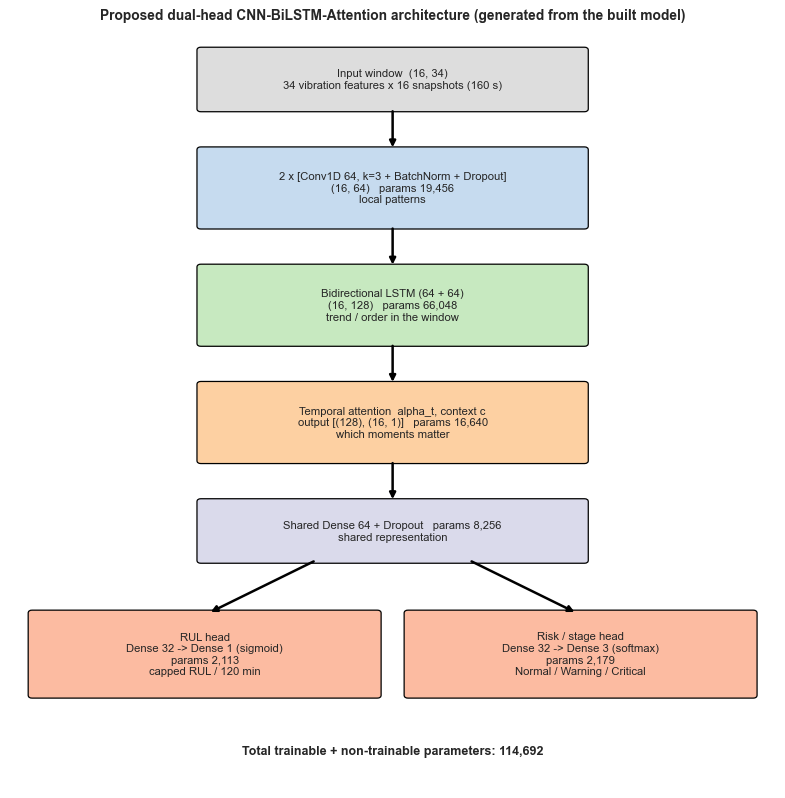

In [18]:
net = M.build_nn("proposed", len(F.FEATURES), C.WINDOW)
lt = M.layer_table(net)
purpose = {"sequence_input": "16 snapshots x 34 features", "conv1": "local feature combinations over 3 neighbouring snapshots", "bn1": "stabilises training", "drop1": "regularisation",
           "conv2": "second local layer", "bn2": "stabilises training", "drop2": "regularisation", "bilstm": "trend/order in both directions of the past window (2 x 64 units)",
           "drop_bilstm": "regularisation", "temporal_attention": "weights the 16 steps (alpha) and returns the context vector", "shared_dense": "shared representation for both heads",
           "drop_shared": "regularisation", "rul_dense": "RUL head hidden layer", "risk_dense": "stage head hidden layer", "rul_output": "capped RUL / 120 min in [0,1] (sigmoid)", "risk_output": "3 stage probabilities (softmax)"}
lt["purpose"] = lt.layer.map(purpose)
display(lt.set_index("layer"))
n_params = {k: M.build_nn(k, len(F.FEATURES), C.WINDOW).count_params() for k in M.NN_KINDS}
display(pd.Series({M.NN_KINDS[k][0]: v for k, v in n_params.items()}, name="parameters").to_frame())
R.show(f"**Proposed model: {n_params['proposed']:,} parameters, trained on only {len(C.LEARNING)} learning bearings.** The parameter-to-independent-history ratio is a warning sign that is tested in Sections 17-18.")

# Figure: architecture diagram generated from the layer table
from matplotlib.patches import FancyBboxPatch
def shp(name, which="output_shape"): return lt.set_index("layer").loc[name, which].replace("None, ", "")
def par(*names): return int(lt.set_index("layer").loc[list(names), "params"].sum())
fig, ax = plt.subplots(figsize=(11, 11)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 13)
def box(x, y, w, h, txt, col):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05", fc=col, ec="black")); ax.text(x + w / 2, y + h / 2, txt, ha="center", va="center", fontsize=9)
def arrow(x1, y1, x2, y2): ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="-|>", lw=2, color="black"), zorder=5)
box(2.5, 11.6, 5, 1.0, f"Input window  {shp('sequence_input')}\n34 vibration features x 16 snapshots (160 s)", "#dddddd"); arrow(5, 11.6, 5, 10.9)
box(2.5, 9.6, 5, 1.3, f"2 x [Conv1D 64, k=3 + BatchNorm + Dropout]\n{shp('conv2')}   params {par('conv1','bn1','conv2','bn2'):,}\nlocal patterns", "#c6dbef"); arrow(5, 9.6, 5, 8.9)
box(2.5, 7.6, 5, 1.3, f"Bidirectional LSTM (64 + 64)\n{shp('bilstm')}   params {par('bilstm'):,}\ntrend / order in the window", "#c7e9c0"); arrow(5, 7.6, 5, 6.9)
box(2.5, 5.6, 5, 1.3, f"Temporal attention  alpha_t, context c\noutput {shp('temporal_attention')}   params {par('temporal_attention'):,}\nwhich moments matter", "#fdd0a2"); arrow(5, 5.6, 5, 4.9)
box(2.5, 3.9, 5, 1.0, f"Shared Dense 64 + Dropout   params {par('shared_dense'):,}\nshared representation", "#dadaeb"); arrow(4, 3.9, 2.6, 3.0); arrow(6, 3.9, 7.4, 3.0)
box(0.3, 1.6, 4.5, 1.4, f"RUL head\nDense 32 -> Dense 1 (sigmoid)\nparams {par('rul_dense','rul_output'):,}\ncapped RUL / 120 min", "#fcbba1")
box(5.2, 1.6, 4.5, 1.4, f"Risk / stage head\nDense 32 -> Dense 3 (softmax)\nparams {par('risk_dense','risk_output'):,}\nNormal / Warning / Critical", "#fcbba1")
ax.text(5, 0.6, f"Total trainable + non-trainable parameters: {net.count_params():,}", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Proposed dual-head CNN-BiLSTM-Attention architecture (generated from the built model)", fontweight="bold")
R.savefig(fig, "fig_architecture.png"); plt.show()
del net

## 16. Training

**WHAT** – train every neural variant in every LOBO fold, with **two random seeds**, using the recipe below. Early stopping monitors the loss on the fold's *validation bearing* only; the held-out bearing is scored after training.
**WHY** – early stopping needs some validation data, but it must not be the bearing we score.
**EXPECT** – neural networks overfit the 4 training bearings quickly (validation loss stops improving after a few epochs).

| Setting | Value |
|---|---|
| Optimiser / learning rate | Adam, 1e-3, reduced ×0.5 on plateau (patience 3) |
| Batch size / max epochs / early stopping | 64 / 40 / patience 6, best weights restored |
| Loss (RUL head) | Huber, δ = 0.1, on capped RUL / 120 min |
| Loss (stage head) | sparse categorical cross-entropy with **balanced class weights** |
| Loss weights | RUL 1.0, stage 0.5 (fixed, **not tuned**) |
| Window / features | 16 snapshots × 34 features, `StandardScaler` fitted on the fold's training bearings only |
| Seeds | 42, 43 (LOBO); 42, 43, 44 (final). TensorFlow deterministic ops enabled |

In [19]:
t0 = time.time()
pred_nn, ep_nn, kept_lobo, hists = E.run_lobo(table, feats, list(M.NN_KINDS), SEEDS_LOBO, keep_models=("proposed",))
pred_lobo = pd.concat([pred_cls, pred_nn], ignore_index=True)
ep_lobo = pd.concat([ep_cls, ep_nn], ignore_index=True)
print(f"neural models, LOBO: done in {time.time()-t0:.0f}s | total held-out predictions: {len(pred_lobo):,}")
sm = E.summarize(pred_lobo)                                                  # metrics per model x seed x fold
fold_mean = sm.groupby(["model", "fold"]).mean(numeric_only=True)            # average seeds inside each fold -> 6 independent folds
pred_lobo.to_csv(C.ARTIFACTS / "lobo_predictions.csv", index=False); sm.to_csv(C.ARTIFACTS / "lobo_metrics_per_fold_seed.csv", index=False)

  LOBO fold 1/6 (held out Bearing1_1) done - 207s


  LOBO fold 2/6 (held out Bearing1_2) done - 476s


  LOBO fold 3/6 (held out Bearing2_1) done - 777s


  LOBO fold 4/6 (held out Bearing2_2) done - 1037s


  LOBO fold 5/6 (held out Bearing3_1) done - 1360s


  LOBO fold 6/6 (held out Bearing3_2) done - 1567s


neural models, LOBO: done in 1567s | total held-out predictions: 148,880


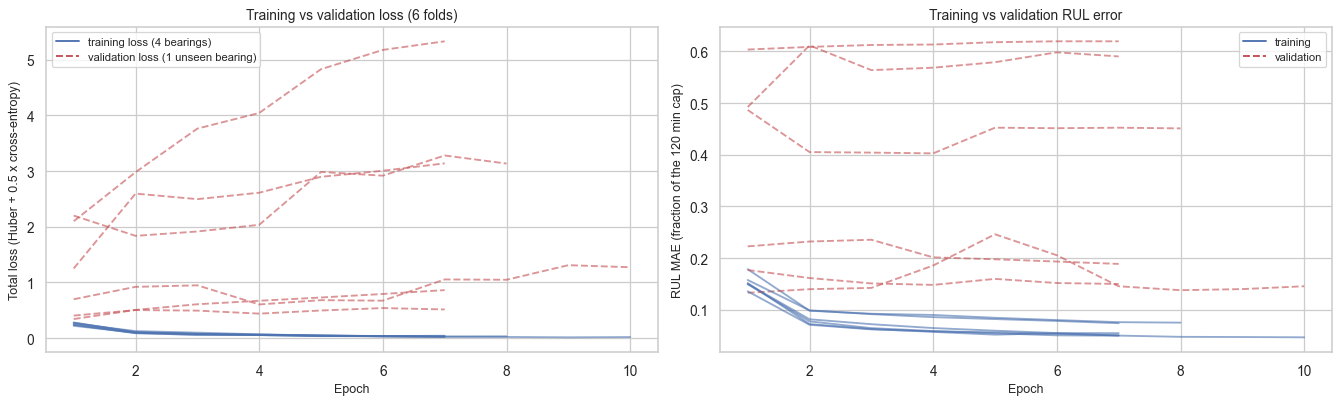

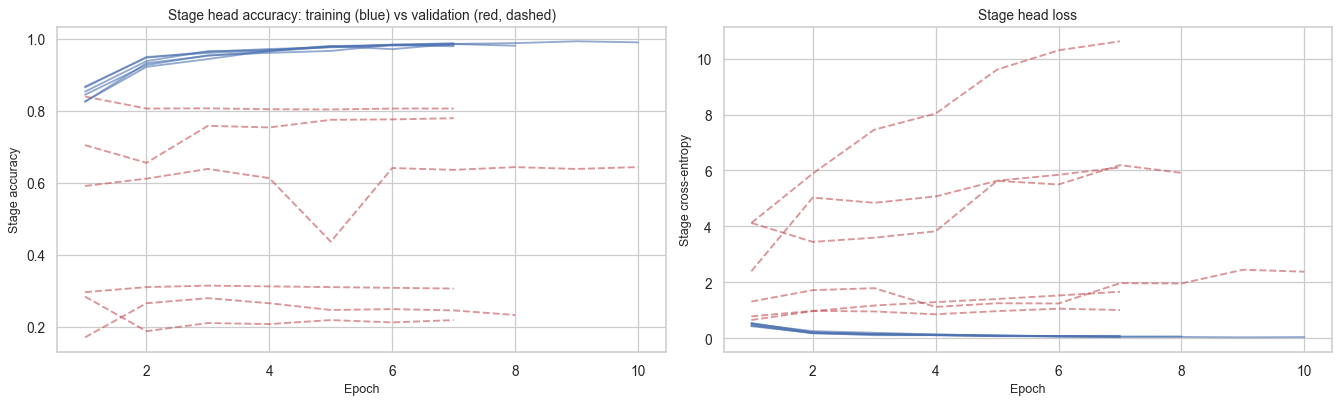

**Figures 10-11.** Validation loss (red) stops improving after a handful of epochs while training loss keeps falling. Median best epoch of the proposed model: **1.0**. At the end of training the stage accuracy on the training bearings exceeds that on the unseen validation bearing by **49 percentage points** on average: the model memorises the four training bearings.

In [20]:
# Figures: training vs validation loss and metrics (proposed model, seed 42, all six LOBO folds)
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
for fi in range(6):
    h = hists[("proposed", SEEDS_LOBO[0], fi)]; ep = np.arange(1, len(h["loss"]) + 1)
    ax[0].plot(ep, h["loss"], color="#4c72b0", alpha=0.6); ax[0].plot(ep, h["val_loss"], color="#c44e52", alpha=0.6, ls="--")
    ax[1].plot(ep, h["rul_output_mae"], color="#4c72b0", alpha=0.6); ax[1].plot(ep, h["val_rul_output_mae"], color="#c44e52", alpha=0.6, ls="--")
ax[0].plot([], [], color="#4c72b0", label="training loss (4 bearings)"); ax[0].plot([], [], color="#c44e52", ls="--", label="validation loss (1 unseen bearing)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Total loss (Huber + 0.5 x cross-entropy)"); ax[0].set_title("Training vs validation loss (6 folds)"); ax[0].legend()
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("RUL MAE (fraction of the 120 min cap)"); ax[1].set_title("Training vs validation RUL error")
ax[1].plot([], [], color="#4c72b0", label="training"); ax[1].plot([], [], color="#c44e52", ls="--", label="validation"); ax[1].legend()
plt.tight_layout(); R.savefig(fig, "fig_training_curves.png"); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
for fi in range(6):
    h = hists[("proposed", SEEDS_LOBO[0], fi)]; ep = np.arange(1, len(h["loss"]) + 1)
    ax[0].plot(ep, h["risk_output_accuracy"], color="#4c72b0", alpha=0.6); ax[0].plot(ep, h["val_risk_output_accuracy"], color="#c44e52", alpha=0.6, ls="--")
    ax[1].plot(ep, h["risk_output_loss"], color="#4c72b0", alpha=0.6); ax[1].plot(ep, h["val_risk_output_loss"], color="#c44e52", alpha=0.6, ls="--")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Stage accuracy"); ax[0].set_title("Stage head accuracy: training (blue) vs validation (red, dashed)")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Stage cross-entropy"); ax[1].set_title("Stage head loss")
plt.tight_layout(); R.savefig(fig, "fig_training_metrics.png"); plt.show()
best_ep = ep_nn.groupby("model").best_epoch.median()
gap = np.mean([hists[("proposed", SEEDS_LOBO[0], fi)]["risk_output_accuracy"][-1] - hists[("proposed", SEEDS_LOBO[0], fi)]["val_risk_output_accuracy"][-1] for fi in range(6)])
R.show(f"**Figures 10-11.** Validation loss (red) stops improving after a handful of epochs while training loss keeps falling. Median best epoch of the proposed model: **{best_ep['proposed']:.1f}**. "
       f"At the end of training the stage accuracy on the training bearings exceeds that on the unseen validation bearing by **{100*gap:.0f} percentage points** on average: the model memorises the four training bearings.")

### 16.1 What did we find?
As expected for 4–5 independent histories, **the networks overfit almost immediately**: the best epoch is early, and the gap between training and validation accuracy is large. This is an early, honest indication that model *capacity is not the bottleneck* — data is. It does not yet say whether the architecture helps; the comparison in Section 17 and the ablation in Section 18 answer that on bearings that were never used for training.

## 17. Model Comparison (leave-one-bearing-out, learning bearings only)

**WHAT** – compare all models on the six held-out learning bearings. For every model we average the seeds inside each fold and then report **mean ± std over the 6 folds** (the folds, i.e. bearings, are the independent units).
**METRICS (defined once in `src/metrics.py`).**
* *MAE (min)* – mean absolute error of the RUL, in minutes, against the capped true RUL, over all windows. Most windows are healthy (RUL ≥ 120), so a **constant prediction is hard to beat on this number**.
* *MAE actionable (min)* – the same error, only over windows where failure is within the 60-minute warning horizon: this is the region where a prediction is useful.
* *AUC h10 / h60 / mean-h* – ROC-AUC of detecting "failure within H minutes" from the predicted RUL (score = −predicted RUL) at H = 10 or 60 minutes, and the mean over H = 5, 10, 20, 30, 60. 0.5 = chance, 1 = perfect.
* *Macro-F1* – F1 of the three stages averaged over classes (uniform rule: stage from predicted RUL with the same thresholds for every model).
* *False-alarm rate* – fraction of truly Normal windows (RUL > 60 min) that lie in an alarm (predicted stage ≥ Warning for 3 consecutive windows).
* *Alarm active at end* – number of held-out bearings whose alarm is still on at the last window before failure (strict). *Sustained lead* – RUL at the start of that final uninterrupted alarm run (capped at 120 min); a run that started long before the warning zone is partly a false alarm, so read it together with the false-alarm rate.

In [21]:
cols = ["MAE_min", "MAE_min_actionable", "AUC_h10", "AUC_h60", "AUC_mean_h", "stage_macroF1", "false_alarm_rate"]
grp = fold_mean[cols].groupby("model", sort=False)
tab = pd.DataFrame({c: grp[c].apply(R.fmt_ms) for c in cols})
order_models = list(E.ALL_MODELS)
tab = tab.loc[order_models]; tab.index = [E.LABEL[m] for m in order_models]
tab["alarm active at end (of 6)"] = [f"{fold_mean.xs(m, level='model').alarm_at_end_bearings.sum():.1f}" for m in order_models]
tab["median sustained lead (min)"] = [f"{fold_mean.xs(m, level='model').lead_sustained_min_median.median():.1f}" for m in order_models]
tab["params"] = [n_params.get(m, np.nan) for m in order_models]
tab["fit+predict s (median)"] = [ep_lobo[ep_lobo.model == m].fit_predict_s.median() for m in order_models]
tab["best epoch (median)"] = [ep_lobo[ep_lobo.model == m].best_epoch.median() for m in order_models]
display(tab)
tab.to_csv(C.ARTIFACTS / "lobo_model_comparison.csv")
per_fold_auc = fold_mean["AUC_mean_h"].unstack(0)[order_models]; per_fold_mae = fold_mean["MAE_min_actionable"].unstack(0)[order_models]
per_fold_auc.index = [f"{f}: {C.LEARNING[f]}" for f in per_fold_auc.index]; per_fold_mae.index = per_fold_auc.index
per_fold_auc.columns = per_fold_mae.columns = [E.LABEL[m] for m in order_models]
R.show("**Per-fold mean AUC (higher is better)** - which held-out bearing is easy or hard:"); display(per_fold_auc.round(2))
R.show("**Per-fold actionable-region MAE in minutes (lower is better):**"); display(per_fold_mae.round(1))

,MAE_min,MAE_min_actionable,AUC_h10,AUC_h60,AUC_mean_h,stage_macroF1,false_alarm_rate,alarm active at end (of 6),median sustained lead (min),params,fit+predict s (median),best epoch (median)
Constant,40.310 +/- 4.179,53.373 +/- 11.107,0.500 +/- 0.000,0.500 +/- 0.000,0.500 +/- 0.000,0.246 +/- 0.058,0.000 +/- 0.000,0.0,nan,NaN,0.009719,NaN
Ridge,55.531 +/- 23.253,31.076 +/- 18.026,0.603 +/- 0.174,0.703 +/- 0.221,0.615 +/- 0.198,0.267 +/- 0.214,0.535 +/- 0.427,6.0,64.8,NaN,0.407146,NaN
Random Forest,44.125 +/- 17.331,38.902 +/- 21.387,0.776 +/- 0.162,0.662 +/- 0.168,0.717 +/- 0.159,0.342 +/- 0.165,0.365 +/- 0.372,4.0,28.2,NaN,13.370668,NaN
Gradient Boosting,43.007 +/- 16.689,39.680 +/- 20.811,0.781 +/- 0.161,0.670 +/- 0.142,0.725 +/- 0.091,0.335 +/- 0.141,0.362 +/- 0.363,4.0,29.8,NaN,4.314952,NaN
CNN,46.152 +/- 19.683,28.946 +/- 21.476,0.803 +/- 0.183,0.835 +/- 0.195,0.803 +/- 0.172,0.294 +/- 0.163,0.563 +/- 0.356,5.5,39.8,25729.0,7.662250,1.5
LSTM,42.477 +/- 21.791,27.978 +/- 26.595,0.940 +/- 0.049,0.822 +/- 0.128,0.886 +/- 0.104,0.373 +/- 0.160,0.454 +/- 0.341,5.5,63.5,31617.0,8.162054,1.0
CNN + LSTM,43.131 +/- 18.977,24.150 +/- 16.352,0.883 +/- 0.106,0.811 +/- 0.173,0.852 +/- 0.128,0.325 +/- 0.182,0.517 +/- 0.339,6.0,39.0,58753.0,17.088253,3.5
CNN + BiLSTM,46.738 +/- 20.546,28.407 +/- 22.156,0.893 +/- 0.077,0.810 +/- 0.175,0.873 +/- 0.116,0.314 +/- 0.179,0.537 +/- 0.346,5.5,59.3,95873.0,19.829744,2.5
CNN + BiLSTM + Attention (single head),44.922 +/- 18.441,23.340 +/- 17.162,0.848 +/- 0.144,0.789 +/- 0.193,0.830 +/- 0.149,0.315 +/- 0.156,0.586 +/- 0.345,6.0,67.0,112513.0,28.627504,6.5
"CNN + BiLSTM (dual head, no attention)",47.172 +/- 24.217,31.326 +/- 25.701,0.879 +/- 0.107,0.747 +/- 0.202,0.827 +/- 0.126,0.317 +/- 0.197,0.506 +/- 0.339,6.0,28.5,98052.0,20.903742,1.0


**Per-fold mean AUC (higher is better)** - which held-out bearing is easy or hard:

,Constant,Ridge,Random Forest,Gradient Boosting,CNN,LSTM,CNN + LSTM,CNN + BiLSTM,CNN + BiLSTM + Attention (single head),"CNN + BiLSTM (dual head, no attention)",PROPOSED: CNN + BiLSTM + Attention (dual head)
0: Bearing1_1,0.5,0.77,0.44,0.70,0.99,0.99,0.94,0.95,0.88,0.93,0.91
1: Bearing1_2,0.5,0.63,0.74,0.77,0.93,0.82,0.86,0.93,0.93,0.96,0.96
2: Bearing2_1,0.5,0.31,0.85,0.77,0.60,0.93,0.69,0.79,0.61,0.73,0.63
3: Bearing2_2,0.5,0.85,0.87,0.85,0.94,0.98,0.98,0.96,0.98,0.92,0.91
4: Bearing3_1,0.5,0.67,0.75,0.62,0.70,0.89,0.94,0.93,0.90,0.65,0.86
5: Bearing3_2,0.5,0.46,0.64,0.64,0.64,0.71,0.70,0.67,0.68,0.77,0.82


**Per-fold actionable-region MAE in minutes (lower is better):**

,Constant,Ridge,Random Forest,Gradient Boosting,CNN,LSTM,CNN + LSTM,CNN + BiLSTM,CNN + BiLSTM + Attention (single head),"CNN + BiLSTM (dual head, no attention)",PROPOSED: CNN + BiLSTM + Attention (dual head)
0: Bearing1_1,45.5,30.0,47.8,45.7,21.1,20.7,22.1,25.1,22.5,21.6,25.6
1: Bearing1_2,60.3,30.0,16.0,17.7,25.9,16.7,21.1,20.9,18.6,20.8,21.1
2: Bearing2_1,60.7,21.5,59.5,63.1,19.6,20.3,14.7,20.7,13.8,31.4,18.5
3: Bearing2_2,61.9,11.3,15.6,18.2,14.4,9.0,9.1,10.0,9.5,13.3,13.4
4: Bearing3_1,57.5,64.8,64.3,63.1,72.1,81.5,55.8,72.4,57.2,82.4,79.0
5: Bearing3_2,34.3,28.9,30.2,30.2,20.5,19.5,22.0,21.2,18.5,18.5,14.9


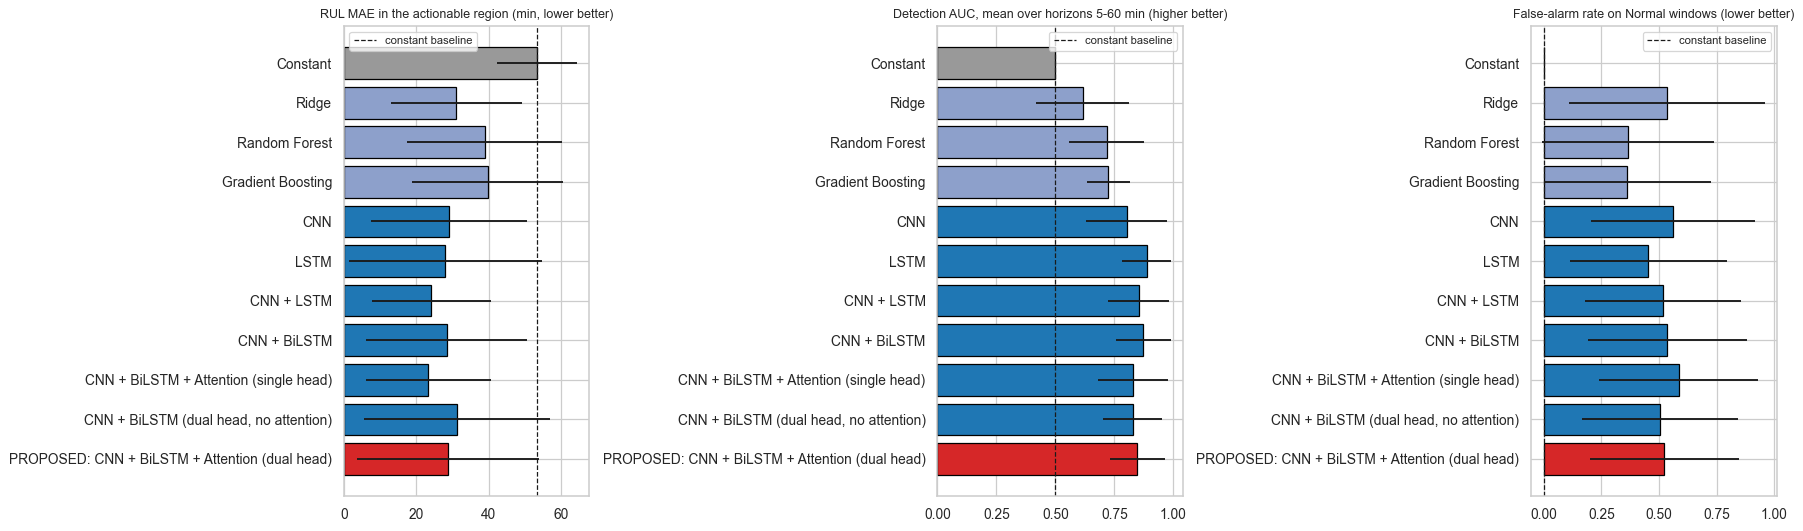

**Figure 12.** LOBO comparison (mean over 6 held-out bearings, error bars = std across bearings; grey = constant, purple = classical, blue = neural, red = proposed).

In [22]:
# Figure: model comparison (LOBO)
mm = fold_mean.groupby("model").agg(["mean", "std"])
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
for a_, (met, ttl, lower) in zip(ax, [("MAE_min_actionable", "RUL MAE in the actionable region (min, lower better)", True), ("AUC_mean_h", "Detection AUC, mean over horizons 5-60 min (higher better)", False), ("false_alarm_rate", "False-alarm rate on Normal windows (lower better)", True)]):
    m_ = mm[(met, "mean")].loc[order_models]; s_ = mm[(met, "std")].loc[order_models]
    cols_ = ["#999999" if k in ("Constant",) else ("#d62728" if k == "proposed" else ("#8da0cb" if k in M.CLASSICAL else "#1f77b4")) for k in order_models]
    a_.barh([E.LABEL[k] for k in order_models], m_, xerr=s_, color=cols_, edgecolor="black"); a_.invert_yaxis(); a_.set_title(ttl, fontsize=10)
    a_.axvline(m_["Constant"], color="k", ls="--", lw=1, label="constant baseline"); a_.legend()
plt.tight_layout(); R.savefig(fig, "fig_model_comparison_lobo.png"); plt.show()
R.show("**Figure 12.** LOBO comparison (mean over 6 held-out bearings, error bars = std across bearings; grey = constant, purple = classical, blue = neural, red = proposed).")

In [23]:
# ---- MODEL SELECTION: rules fixed in advance, applied to LOBO results ONLY; written to disk BEFORE any test bearing is scored ----
mmean = fold_mean.groupby("model").mean(numeric_only=True)
cand = mmean.drop(index="Constant")
sel = {"rule": "selection uses LOBO validation results only (learning bearings); the 11 test bearings are not touched before this file is written",
       "best_actionable_RUL_MAE": cand.MAE_min_actionable.idxmin(), "best_detection_AUC_mean_h": cand.AUC_mean_h.idxmax(),
       "lowest_false_alarm_rate": cand.false_alarm_rate.idxmin(), "interpretable_by_design": "proposed",
       "models_beating_constant_on_overall_MAE": [m for m in cand.index if cand.loc[m, "MAE_min"] < mmean.loc["Constant", "MAE_min"]],
       "models_beating_constant_on_actionable_MAE": [m for m in cand.index if cand.loc[m, "MAE_min_actionable"] < mmean.loc["Constant", "MAE_min_actionable"]],
       "epochs_by_model": {m: int(max(3, round(ep_lobo[ep_lobo.model == m].best_epoch.median()))) for m in M.NN_KINDS}}
json.dump(sel, open(C.ARTIFACTS / "selection.json", "w"), indent=1)
CFG_AT_SELECTION = L.config_snapshot()
R.show("**Selection (LOBO only, saved to `artifacts/selection.json`):**\n\n" + "\n".join(f"* {k}: `{v}`" for k, v in sel.items() if k != "epochs_by_model"))
R.show(f"Epochs used for the final training (median best LOBO epoch, at least 3): `{sel['epochs_by_model']}`")

**Selection (LOBO only, saved to `artifacts/selection.json`):**

* rule: `selection uses LOBO validation results only (learning bearings); the 11 test bearings are not touched before this file is written`
* best_actionable_RUL_MAE: `cnn_bilstm_attn`
* best_detection_AUC_mean_h: `lstm`
* lowest_false_alarm_rate: `Gradient Boosting`
* interpretable_by_design: `proposed`
* models_beating_constant_on_overall_MAE: `[]`
* models_beating_constant_on_actionable_MAE: `['Gradient Boosting', 'Random Forest', 'Ridge', 'cnn', 'cnn_bilstm', 'cnn_bilstm_attn', 'cnn_bilstm_dual', 'cnn_lstm', 'lstm', 'proposed']`

Epochs used for the final training (median best LOBO epoch, at least 3): `{'cnn': 3, 'lstm': 3, 'cnn_lstm': 4, 'cnn_bilstm': 3, 'cnn_bilstm_attn': 6, 'cnn_bilstm_dual': 3, 'proposed': 3}`

In [24]:
c0 = mmean.loc["Constant"]
best = mmean.drop(index="Constant")
txt = []
txt.append(f"**Do any models beat the constant baseline?** Overall RUL MAE (constant {c0.MAE_min:.1f} min): " + (", ".join(f"{E.LABEL[m]} {mmean.loc[m,'MAE_min']:.1f}" for m in sel['models_beating_constant_on_overall_MAE']) if sel['models_beating_constant_on_overall_MAE'] else "**no model** beats the constant") +
           f". Actionable-region MAE (constant {c0.MAE_min_actionable:.1f} min): " + (", ".join(f"{E.LABEL[m]} {mmean.loc[m,'MAE_min_actionable']:.1f}" for m in sel['models_beating_constant_on_actionable_MAE']) if sel['models_beating_constant_on_actionable_MAE'] else "**no model** beats the constant") + ".")
txt.append(f"**Detection (mean AUC over horizons, constant 0.50):** best = **{E.LABEL[sel['best_detection_AUC_mean_h']]}** ({best.AUC_mean_h.max():.2f}); proposed = {best.loc['proposed','AUC_mean_h']:.2f}; best tabular = {max(best.loc[m,'AUC_mean_h'] for m in M.CLASSICAL if m!='Constant'):.2f}.")
txt.append(f"**Lowest false-alarm rate:** {E.LABEL[sel['lowest_false_alarm_rate']]} ({best.false_alarm_rate.min():.2f}); proposed = {best.loc['proposed','false_alarm_rate']:.2f}. Note that false alarms of the *uniform rule* derive from the noisy RUL estimate.")
R.show("### 17.1 What did we find?\n\n" + "\n\n".join(txt))

### 17.1 What did we find?

**Do any models beat the constant baseline?** Overall RUL MAE (constant 40.3 min): **no model** beats the constant. Actionable-region MAE (constant 53.4 min): Gradient Boosting 39.7, Random Forest 38.9, Ridge 31.1, CNN 28.9, CNN + BiLSTM 28.4, CNN + BiLSTM + Attention (single head) 23.3, CNN + BiLSTM (dual head, no attention) 31.3, CNN + LSTM 24.2, LSTM 28.0, PROPOSED: CNN + BiLSTM + Attention (dual head) 28.8.

**Detection (mean AUC over horizons, constant 0.50):** best = **LSTM** (0.89); proposed = 0.85; best tabular = 0.72.

**Lowest false-alarm rate:** Gradient Boosting (0.36); proposed = 0.52. Note that false alarms of the *uniform rule* derive from the noisy RUL estimate.

### 17.2 What does this mean, and does it support the hypotheses?
* **H1 (sequence models detect impending failure better than tabular baselines):** judge from the AUC columns and the per-fold table: compare the neural rows with the tabular rows, fold by fold, and note the large differences between held-out bearings. Statistical support is limited by n = 6 folds (tested in Section 18).
* **H3 (a warning several tens of minutes ahead for every bearing):** the per-fold tables show the bearings for which this fails.
* **Important:** the dataset has only six independent learning histories. Differences between models that are smaller than the fold-to-fold spread should not be interpreted as real.

## 18. Ablation Study

**WHAT** – remove or add **one component at a time** along the chain CNN → CNN+LSTM → CNN+BiLSTM → +Attention → +Dual head, plus the side branch "dual head without attention", and measure the paired change over the 6 held-out learning bearings with a bootstrap 95 % confidence interval.
**WHY** – to test whether each part of the proposed architecture contributes, rather than assume it. **We do not claim a component helps unless the interval excludes zero.**
**EXPECT** – with only 6 folds, most intervals will be wide; a component is "supported" only if the improvement is consistent across bearings.

,step,metric,mean_diff,ci_lo,ci_hi,units_improved,verdict
0,CNN -> CNN+LSTM (add recurrence),detection AUC (mean over horizons),0.050,-0.024,0.134,4/6,no measurable difference (CI includes 0)
1,CNN -> CNN+LSTM (add recurrence),actionable RUL MAE (min),-4.796,-9.675,-0.772,4/6,measurable improvement
2,CNN -> CNN+LSTM (add recurrence),stage macro-F1,0.031,-0.020,0.078,5/6,no measurable difference (CI includes 0)
3,LSTM -> BiLSTM (make it bidirectional),detection AUC (mean over horizons),0.020,-0.016,0.060,3/6,no measurable difference (CI includes 0)
4,LSTM -> BiLSTM (make it bidirectional),actionable RUL MAE (min),4.257,0.422,9.578,2/6,measurable degradation
5,LSTM -> BiLSTM (make it bidirectional),stage macro-F1,-0.011,-0.038,0.017,2/6,no measurable difference (CI includes 0)
6,add attention (single head),detection AUC (mean over horizons),-0.042,-0.103,0.003,2/6,no measurable difference (CI includes 0)
7,add attention (single head),actionable RUL MAE (min),-5.067,-9.621,-1.860,6/6,measurable improvement
8,add attention (single head),stage macro-F1,0.001,-0.021,0.024,2/6,no measurable difference (CI includes 0)
9,add second head (dual head),detection AUC (mean over horizons),0.017,-0.031,0.071,4/6,no measurable difference (CI includes 0)


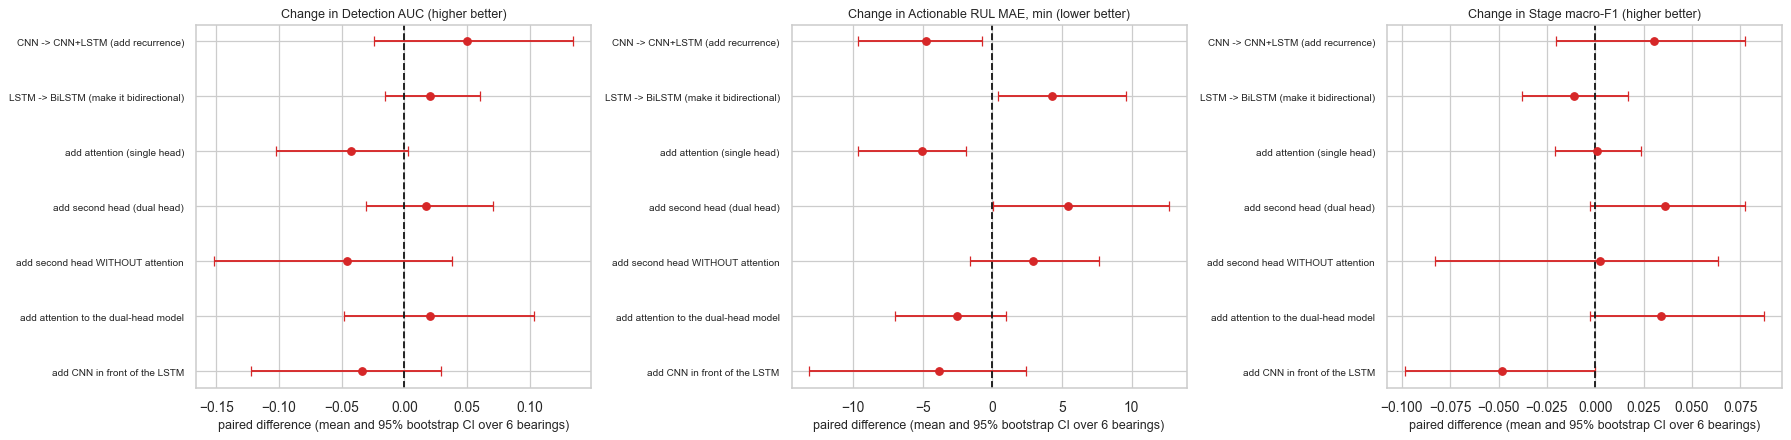

**Figure 13.** Paired change caused by each architectural step. A component is supported only if its interval excludes zero in the helpful direction.

In [25]:
chain = [("cnn", "cnn_lstm", "CNN -> CNN+LSTM (add recurrence)"), ("cnn_lstm", "cnn_bilstm", "LSTM -> BiLSTM (make it bidirectional)"),
         ("cnn_bilstm", "cnn_bilstm_attn", "add attention (single head)"), ("cnn_bilstm_attn", "proposed", "add second head (dual head)"),
         ("cnn_bilstm", "cnn_bilstm_dual", "add second head WITHOUT attention"), ("cnn_bilstm_dual", "proposed", "add attention to the dual-head model"),
         ("lstm", "cnn_lstm", "add CNN in front of the LSTM")]
rows = []
for a_, b_, lab in chain:
    for met, hib, nm in [("AUC_mean_h", True, "detection AUC (mean over horizons)"), ("MAE_min_actionable", False, "actionable RUL MAE (min)"), ("stage_macroF1", True, "stage macro-F1")]:
        va = fold_mean.xs(a_, level="model")[met].values; vb = fold_mean.xs(b_, level="model")[met].values
        r = R.paired_difference(va, vb, a_, b_, higher_is_better=hib); r.update({"step": lab, "metric": nm}); rows.append(r)
abl = pd.DataFrame(rows)[["step", "metric", "mean_diff", "ci_lo", "ci_hi", "units_improved", "verdict"]]
display(abl.round(3)); abl.to_csv(C.ARTIFACTS / "ablation_lobo.csv", index=False)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
for a_, (met, nm) in zip(ax, [("AUC_mean_h", "Detection AUC (higher better)"), ("MAE_min_actionable", "Actionable RUL MAE, min (lower better)"), ("stage_macroF1", "Stage macro-F1 (higher better)")]):
    sub = abl[abl.metric == {"AUC_mean_h": "detection AUC (mean over horizons)", "MAE_min_actionable": "actionable RUL MAE (min)", "stage_macroF1": "stage macro-F1"}[met]]
    y = np.arange(len(sub)); a_.errorbar(sub.mean_diff, y, xerr=[sub.mean_diff - sub.ci_lo, sub.ci_hi - sub.mean_diff], fmt="o", color="#d62728", capsize=4)
    a_.axvline(0, color="k", ls="--"); a_.set_yticks(y); a_.set_yticklabels(sub.step, fontsize=8); a_.invert_yaxis(); a_.set_title(f"Change in {nm}", fontsize=10); a_.set_xlabel("paired difference (mean and 95% bootstrap CI over 6 bearings)")
plt.tight_layout(); R.savefig(fig, "fig_ablation_lobo.png"); plt.show()
R.show("**Figure 13.** Paired change caused by each architectural step. A component is supported only if its interval excludes zero in the helpful direction.")

In [26]:
def verdicts(metric):
    d = abl[abl.metric == metric].set_index("step").verdict
    return d
rows = []
for step in abl.step.unique():
    s = abl[abl.step == step].set_index("metric").verdict
    rows.append(f"* **{step}** -> detection AUC: *{s['detection AUC (mean over horizons)']}*; actionable RUL MAE: *{s['actionable RUL MAE (min)']}*; stage macro-F1: *{s['stage macro-F1']}*")
att = abl[(abl.step == "add attention (single head)")].set_index("metric").verdict
dual = abl[(abl.step == "add second head (dual head)")].set_index("metric").verdict
R.show("### 18.1 What did we find?\n\n" + "\n".join(rows) +
       f"\n\n**Reading (validation bearings only).** Adding attention to the single-head model: actionable RUL MAE *{att['actionable RUL MAE (min)']}*, detection AUC *{att['detection AUC (mean over horizons)']}*. "
       f"Adding the second head: actionable RUL MAE *{dual['actionable RUL MAE (min)']}*, detection AUC *{dual['detection AUC (mean over horizons)']}*. "
       "No claim of improved accuracy is made from the validation ablation alone: the effects differ between metrics, and the **combined verdict for H2 (validation + test, every contrast) is computed in Section 26**.\n\n"
       "A verdict of *no measurable difference* means the experiment cannot distinguish the step from zero with 6 bearings; it is **not** evidence that the step is harmful or useless, only that it was not shown to help.")

### 18.1 What did we find?

* **CNN -> CNN+LSTM (add recurrence)** -> detection AUC: *no measurable difference (CI includes 0)*; actionable RUL MAE: *measurable improvement*; stage macro-F1: *no measurable difference (CI includes 0)*
* **LSTM -> BiLSTM (make it bidirectional)** -> detection AUC: *no measurable difference (CI includes 0)*; actionable RUL MAE: *measurable degradation*; stage macro-F1: *no measurable difference (CI includes 0)*
* **add attention (single head)** -> detection AUC: *no measurable difference (CI includes 0)*; actionable RUL MAE: *measurable improvement*; stage macro-F1: *no measurable difference (CI includes 0)*
* **add second head (dual head)** -> detection AUC: *no measurable difference (CI includes 0)*; actionable RUL MAE: *measurable degradation*; stage macro-F1: *no measurable difference (CI includes 0)*
* **add second head WITHOUT attention** -> detection AUC: *no measurable difference (CI includes 0)*; actionable RUL MAE: *no measurable difference (CI includes 0)*; stage macro-F1: *no measurable difference (CI includes 0)*
* **add attention to the dual-head model** -> detection AUC: *no measurable difference (CI includes 0)*; actionable RUL MAE: *no measurable difference (CI includes 0)*; stage macro-F1: *no measurable difference (CI includes 0)*
* **add CNN in front of the LSTM** -> detection AUC: *no measurable difference (CI includes 0)*; actionable RUL MAE: *no measurable difference (CI includes 0)*; stage macro-F1: *measurable degradation*

**Reading (validation bearings only).** Adding attention to the single-head model: actionable RUL MAE *measurable improvement*, detection AUC *no measurable difference (CI includes 0)*. Adding the second head: actionable RUL MAE *measurable degradation*, detection AUC *no measurable difference (CI includes 0)*. No claim of improved accuracy is made from the validation ablation alone: the effects differ between metrics, and the **combined verdict for H2 (validation + test, every contrast) is computed in Section 26**.

A verdict of *no measurable difference* means the experiment cannot distinguish the step from zero with 6 bearings; it is **not** evidence that the step is harmful or useless, only that it was not shown to help.

## 19. Evaluation of the Validation Predictions

**WHAT** – look at the LOBO predictions in detail: actual vs predicted RUL, per-bearing trajectories, error distribution, ROC curves for detecting "failure within 60 minutes", and confusion matrices of the stage.
**WHY** – aggregated numbers hide *where* a model fails (Figure 14–19).
**HOW TO READ.** Each held-out bearing was predicted by a model that never saw it.

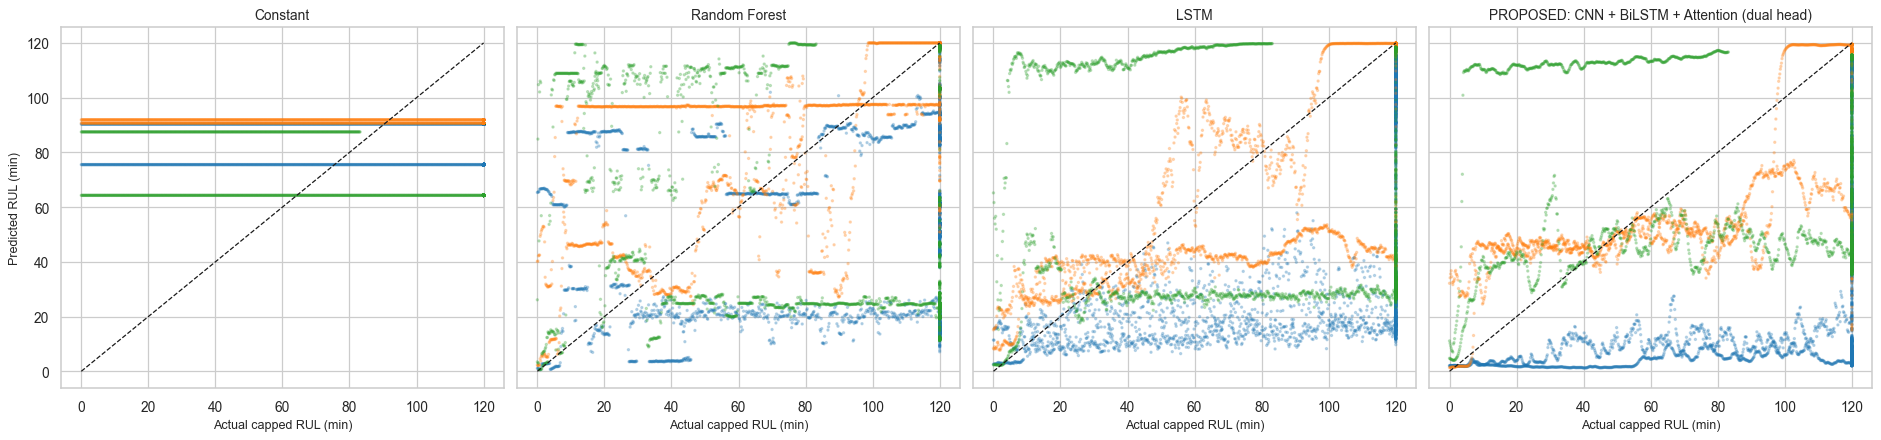

**Figure 14.** Actual vs predicted RUL for held-out bearings (colour = operating condition, dashed = perfect). A model with skill would follow the diagonal; a constant predictor is a horizontal line.

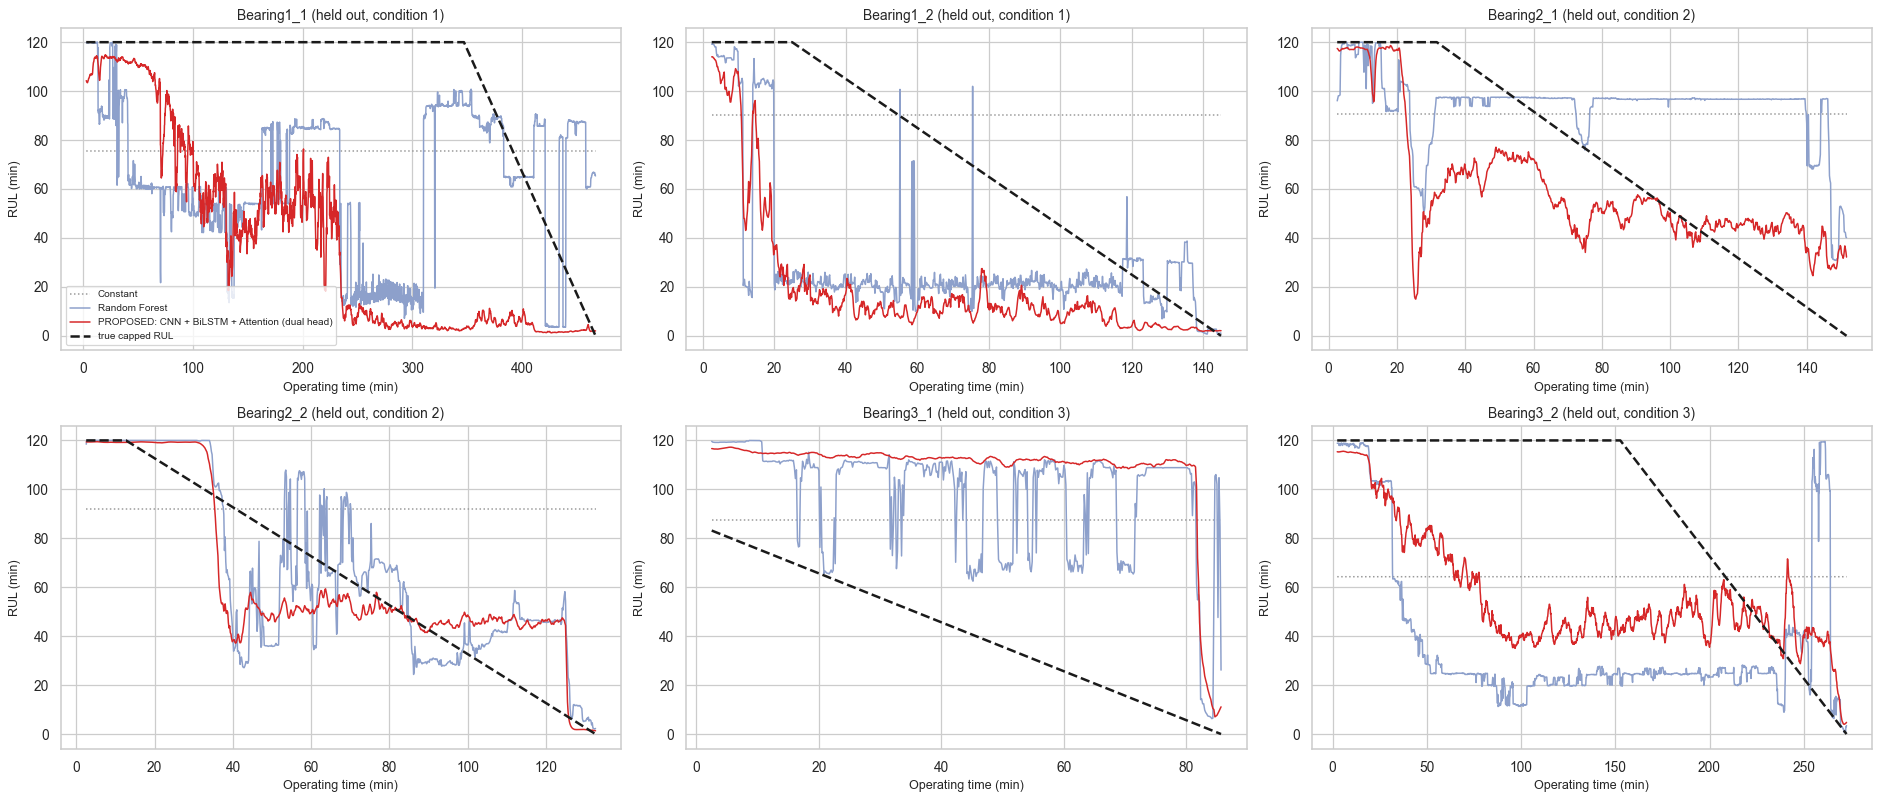

**Figure 15.** Predicted vs true capped RUL over the whole life of each held-out learning bearing (seed 42). Look at *when* the prediction drops: for gradually degrading bearings it starts before failure; for abrupt bearings it starts too late.

In [27]:
SHOW = ["Constant", "Random Forest", "lstm", "proposed"]
SEED0 = SEEDS_LOBO[0]
pl = pred_lobo[(pred_lobo.seed == SEED0)]
# ---- Figure: actual vs predicted RUL ----
fig, ax = plt.subplots(1, 4, figsize=(21, 5), sharex=True, sharey=True)
for a_, m in zip(ax, SHOW):
    g = pl[pl.model == m]
    a_.scatter(g.rul_cap_min, g.pred_min, s=3, alpha=0.25, c=[COND_COLOR[c] for c in g.condition])
    a_.plot([0, 120], [0, 120], "k--", lw=1); a_.set_title(E.LABEL[m]); a_.set_xlabel("Actual capped RUL (min)")
ax[0].set_ylabel("Predicted RUL (min)"); plt.tight_layout(); R.savefig(fig, "fig_actual_vs_predicted_lobo.png"); plt.show()
R.show("**Figure 14.** Actual vs predicted RUL for held-out bearings (colour = operating condition, dashed = perfect). A model with skill would follow the diagonal; a constant predictor is a horizontal line.")

# ---- Figure: per-bearing trajectories ----
fig, axes = plt.subplots(2, 3, figsize=(21, 9)); axes = axes.ravel()
for a_, b in zip(axes, C.LEARNING):
    for m, col, ls in [("Constant", "#999999", ":"), ("Random Forest", "#8da0cb", "-"), ("proposed", "#d62728", "-")]:
        g = pl[(pl.model == m) & (pl.bearing == b)].sort_values("time_min")
        a_.plot(g.time_min, g.pred_min, color=col, ls=ls, lw=1.2, label=E.LABEL[m])
    g = pl[(pl.model == "proposed") & (pl.bearing == b)].sort_values("time_min"); a_.plot(g.time_min, g.rul_cap_min, "k--", lw=2, label="true capped RUL")
    a_.set_title(f"{b} (held out, condition {C.condition_of(b)})"); a_.set_xlabel("Operating time (min)"); a_.set_ylabel("RUL (min)")
axes[0].legend(fontsize=8); plt.tight_layout(); R.savefig(fig, "fig_per_bearing_lobo.png"); plt.show()
R.show("**Figure 15.** Predicted vs true capped RUL over the whole life of each held-out learning bearing (seed 42). Look at *when* the prediction drops: for gradually degrading bearings it starts before failure; for abrupt bearings it starts too late.")

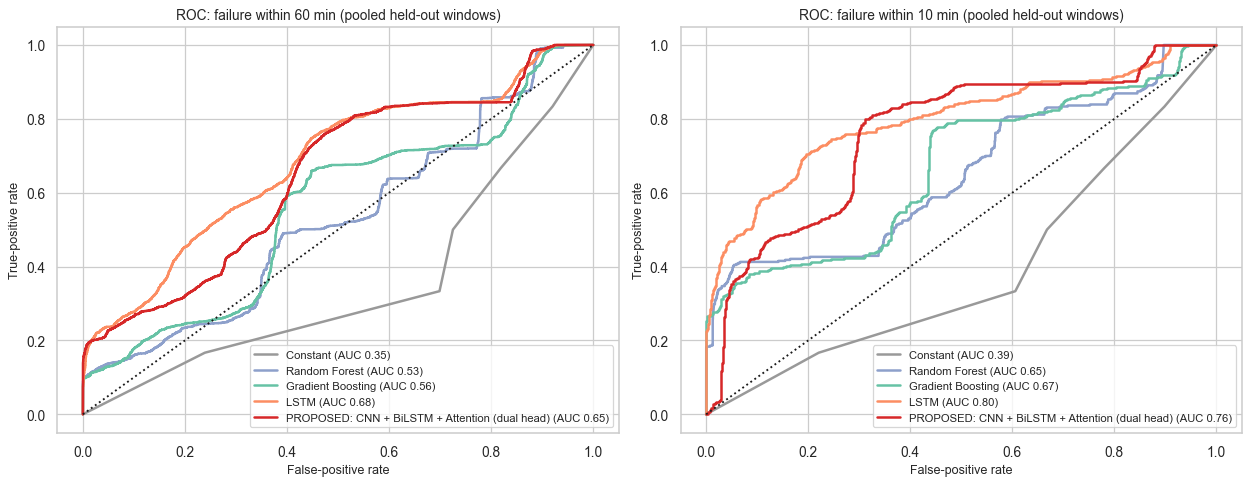

**Figure 16.** ROC curves for detecting an imminent failure from the predicted RUL. The longer horizon (left) is much harder than the short one (right).

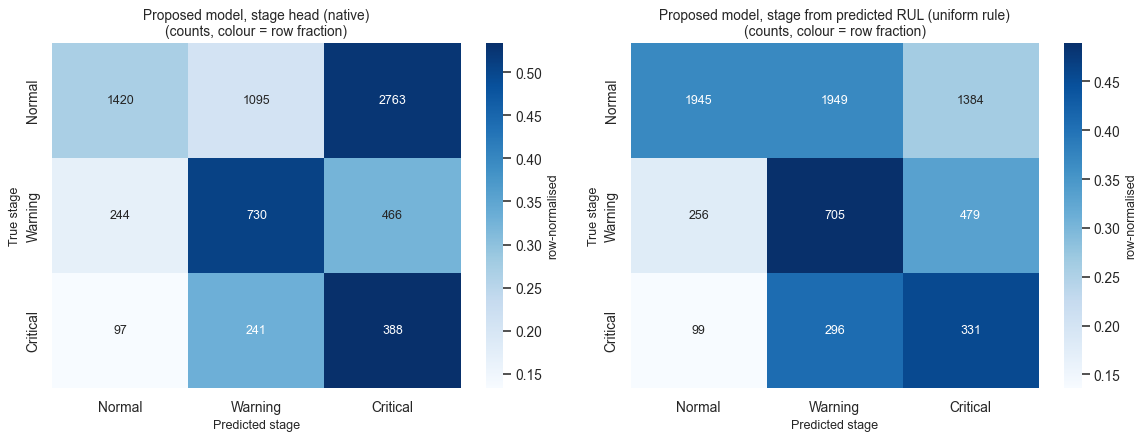

**Figure 17.** Confusion matrices of the proposed model on the held-out learning bearings. Colour is the fraction of each *true* class; numbers are window counts.

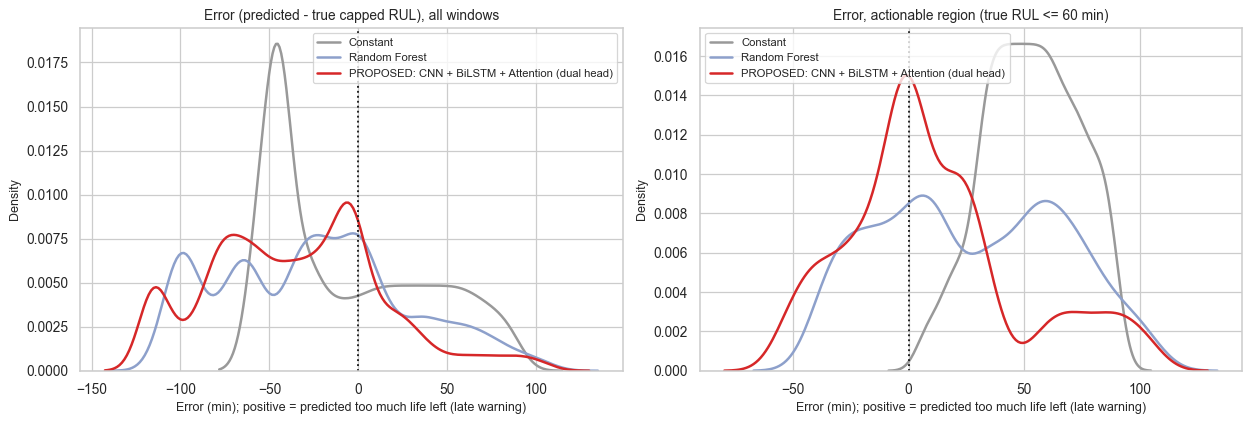

**Figure 18.** Error distributions. In the actionable region a shift to the right means the model over-estimates the remaining life, i.e. warns too late — the dangerous direction.

In [28]:
from sklearn.metrics import roc_curve, confusion_matrix
# ---- ROC for 'failure within 60 min' and 'within 10 min' (pooled over held-out bearings, seed 42) ----
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for a_, h in zip(ax, [60, 10]):
    for m, col in [("Constant", "#999999"), ("Random Forest", "#8da0cb"), ("Gradient Boosting", "#66c2a5"), ("lstm", "#fc8d62"), ("proposed", "#d62728")]:
        g = pl[pl.model == m]; y = (g.rul_min <= h).astype(int)
        fpr, tpr, _ = roc_curve(y, -g.pred_min); a_.plot(fpr, tpr, color=col, lw=2, label=f"{E.LABEL[m]} (AUC {roc_auc_score(y, -g.pred_min):.2f})")
    a_.plot([0, 1], [0, 1], "k:"); a_.set_xlabel("False-positive rate"); a_.set_ylabel("True-positive rate"); a_.set_title(f"ROC: failure within {h} min (pooled held-out windows)"); a_.legend()
plt.tight_layout(); R.savefig(fig, "fig_roc_lobo.png"); plt.show()
R.show("**Figure 16.** ROC curves for detecting an imminent failure from the predicted RUL. The longer horizon (left) is much harder than the short one (right).")

# ---- confusion matrices for the proposed model: native stage head vs uniform rule ----
g = pl[pl.model == "proposed"]
cm_n = confusion_matrix(g.stage, g[["prob0", "prob1", "prob2"]].values.argmax(1), labels=[0, 1, 2]); cm_u = confusion_matrix(g.stage, Mx.rul_to_stage(g.pred_min.values), labels=[0, 1, 2])
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a_, cm, ttl in [(ax[0], cm_n, "stage head (native)"), (ax[1], cm_u, "stage from predicted RUL (uniform rule)")]:
    sns.heatmap(cm / cm.sum(1, keepdims=True), annot=cm, fmt="d", cmap="Blues", ax=a_, xticklabels=["Normal", "Warning", "Critical"], yticklabels=["Normal", "Warning", "Critical"], cbar_kws={"label": "row-normalised"})
    a_.set_xlabel("Predicted stage"); a_.set_ylabel("True stage"); a_.set_title(f"Proposed model, {ttl}\n(counts, colour = row fraction)")
plt.tight_layout(); R.savefig(fig, "fig_confusion_lobo.png"); plt.show()
R.show("**Figure 17.** Confusion matrices of the proposed model on the held-out learning bearings. Colour is the fraction of each *true* class; numbers are window counts.")

# ---- error distribution ----
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for m, col in [("Constant", "#999999"), ("Random Forest", "#8da0cb"), ("proposed", "#d62728")]:
    g = pl[pl.model == m]; e_ = g.pred_min - g.rul_cap_min
    sns.kdeplot(e_, ax=ax[0], color=col, label=E.LABEL[m], lw=2); sns.kdeplot((g.pred_min - g.rul_cap_min)[g.rul_min <= 60], ax=ax[1], color=col, label=E.LABEL[m], lw=2)
ax[0].set_title("Error (predicted - true capped RUL), all windows"); ax[1].set_title("Error, actionable region (true RUL <= 60 min)")
for a_ in ax: a_.axvline(0, color="k", ls=":"); a_.set_xlabel("Error (min); positive = predicted too much life left (late warning)"); a_.legend()
plt.tight_layout(); R.savefig(fig, "fig_error_distribution_lobo.png"); plt.show()
R.show("**Figure 18.** Error distributions. In the actionable region a shift to the right means the model over-estimates the remaining life, i.e. warns too late — the dangerous direction.")

In [29]:
# per-bearing table of the proposed model on the held-out learning bearings (seed 42)
g = pl[pl.model == "proposed"].reset_index(drop=True)
pb_lobo = Mx.per_bearing_table(g[["bearing", "snapshot_idx", "time_min", "rul_min", "rul_cap_min", "y_rul", "stage", "condition"]], g.pred_min.values, Mx.rul_to_stage(g.pred_min.values))
display(pb_lobo[["windows", "MAE_min", "MAE_min_actionable", "stage_macroF1", "false_alarm_rate", "alarm_at_end_bearings", "lead_sustained_min_median"]].round(2))

,windows,MAE_min,MAE_min_actionable,stage_macroF1,false_alarm_rate,alarm_at_end_bearings,lead_sustained_min_median
bearing,,,,,,,
Bearing1_1,2788,65.93,28.06,0.21,0.65,1,120.00
Bearing1_2,856,50.14,23.20,0.19,0.84,1,120.00
Bearing2_1,896,23.54,15.45,0.43,0.42,1,87.33
Bearing2_2,782,15.59,13.16,0.60,0.51,1,95.67
Bearing3_1,500,66.77,75.81,0.22,0.00,1,3.17
Bearing3_2,1622,42.22,12.77,0.42,0.63,1,28.83


### 19.1 What did we find?
The scatter plots and trajectories make the numbers of Section 17 concrete. Read them with three questions: (1) does the prediction *start to fall before the true RUL reaches the warning zone*? (2) is the fall smooth or does it jump only at the very end? (3) how large are the false alarms while the bearing is healthy? The per-bearing table shows that **performance is very uneven across held-out bearings**, which is consistent with the horizon analysis of Section 11: the models can only warn as early as the vibration changes.

## 20. Explainability

**WHAT** – three complementary analyses, all on the **held-out learning bearings** (no test data): (a) the average **attention profile** per true stage and a *functional* test (replace the learned attention by uniform weights inside the same trained network and see whether predictions change); (b) **permutation feature importance** — shuffle one feature across held-out windows and measure how much the error grows (proposed model and Random Forest, per fold); (c) a representative bearing explained.
**WHY** – "explainable" must be measured, not asserted. Attention weights are a property of the model, not a proof of what is *physically causing* the prediction: attention weights can be uncorrelated with feature importance and very different weights can give the same prediction [9]. We therefore test what attention does functionally and report feature importance separately.
**EXPECT** – if attention matters, replacing it by uniform weights should change predictions noticeably; if the profile is near uniform, it explains little.

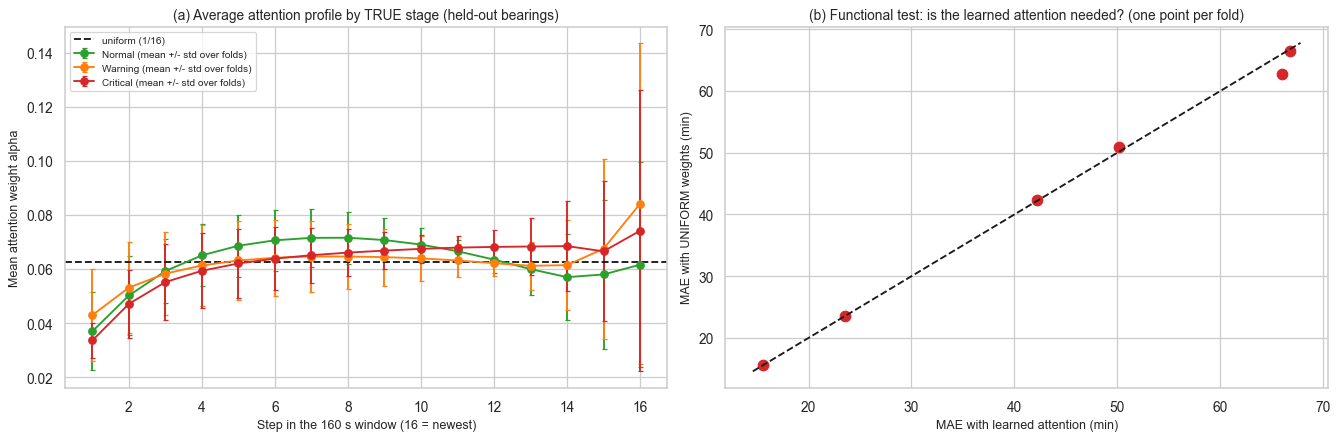

**Figure 20.** (a) Mean attention weight on the newest 4 steps (uniform = 0.25): Normal 0.236, Warning 0.274, Critical 0.277; Critical > Normal in 5/6 folds. Entropy (uniform = 2.773): 2.658. (b) Replacing the learned attention by uniform weights changes the RUL prediction by 1.4 min on average (correlation 0.996); MAE 44.0 -> 43.6 min.

In [30]:
from tensorflow.keras import layers as KL, Model as KModel
from scipy.stats import spearmanr
att_rows, abl_rows = [], []
fold_windows = {}
for fi, f in enumerate(D.lobo_folds()):
    net_f, sc_f = kept_lobo[("proposed", SEED0, fi)]
    Xh, mh = D.make_windows(table, feats, [f["held_out"]], sc_f); fold_windows[fi] = (Xh, mh)
    attn_m = KModel(net_f.input, net_f.get_layer("temporal_attention").output[1]); A_ = attn_m.predict(Xh, batch_size=512, verbose=0)[:, :, 0]
    ent = -(A_ * np.log(A_ + 1e-12)).sum(1); last4 = A_[:, -4:].sum(1)
    for s_, nm in enumerate(["Normal", "Warning", "Critical"]):
        m_ = mh.stage.values == s_
        if m_.any(): att_rows.append(dict(fold=fi, stage=nm, last4=last4[m_].mean(), entropy=ent[m_].mean(), profile=A_[m_].mean(0)))
    # functional test: uniform weights inside the same network
    u = KL.GlobalAveragePooling1D()(net_f.get_layer("drop_bilstm").output)
    u = net_f.get_layer("rul_output")(net_f.get_layer("rul_dense")(net_f.get_layer("shared_dense")(u)))
    uni = KModel(net_f.input, u)
    y_att = np.clip(net_f.predict(Xh, batch_size=512, verbose=0)["rul_output"].ravel(), 0, 1) * C.RUL_CAP_MIN
    y_uni = np.clip(uni.predict(Xh, batch_size=512, verbose=0).ravel(), 0, 1) * C.RUL_CAP_MIN
    act = mh.rul_min.values <= C.STAGE_WARNING_MIN
    abl_rows.append(dict(fold=fi, MAE_with_attention=np.abs(y_att - mh.rul_cap_min).mean(), MAE_uniform_weights=np.abs(y_uni - mh.rul_cap_min).mean(),
                         actionable_MAE_att=np.abs(y_att - mh.rul_cap_min)[act].mean(), actionable_MAE_uniform=np.abs(y_uni - mh.rul_cap_min)[act].mean(),
                         corr=np.corrcoef(y_att, y_uni)[0, 1], mean_abs_change_min=np.abs(y_att - y_uni).mean()))
att = pd.DataFrame(att_rows); abl_att = pd.DataFrame(abl_rows)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for nm, col in [("Normal", "#2ca02c"), ("Warning", "#ff7f0e"), ("Critical", "#d62728")]:
    P_ = np.stack(att[att.stage == nm].profile.values); ax[0].errorbar(np.arange(1, 17), P_.mean(0), yerr=P_.std(0), marker="o", color=col, capsize=2, label=f"{nm} (mean +/- std over folds)")
ax[0].axhline(1 / 16, color="k", ls="--", label="uniform (1/16)"); ax[0].set_xlabel("Step in the 160 s window (16 = newest)"); ax[0].set_ylabel("Mean attention weight alpha"); ax[0].set_title("(a) Average attention profile by TRUE stage (held-out bearings)"); ax[0].legend(fontsize=8)
ax[1].scatter(abl_att.MAE_with_attention, abl_att.MAE_uniform_weights, s=70, c="#d62728"); lim = [abl_att[["MAE_with_attention", "MAE_uniform_weights"]].min().min() - 1, abl_att[["MAE_with_attention", "MAE_uniform_weights"]].max().max() + 1]
ax[1].plot(lim, lim, "k--"); ax[1].set_xlabel("MAE with learned attention (min)"); ax[1].set_ylabel("MAE with UNIFORM weights (min)"); ax[1].set_title("(b) Functional test: is the learned attention needed? (one point per fold)")
plt.tight_layout(); R.savefig(fig, "fig_attention_lobo.png"); plt.show()
piv = att.pivot(index="fold", columns="stage", values="last4")
R.show(f"**Figure 20.** (a) Mean attention weight on the newest 4 steps (uniform = 0.25): Normal {piv.Normal.mean():.3f}, Warning {piv.Warning.mean():.3f}, Critical {piv.Critical.mean():.3f}; Critical > Normal in {(piv.Critical > piv.Normal).sum()}/{piv.Critical.notna().sum()} folds. "
       f"Entropy (uniform = {np.log(16):.3f}): {att.entropy.mean():.3f}. (b) Replacing the learned attention by uniform weights changes the RUL prediction by {abl_att.mean_abs_change_min.mean():.1f} min on average (correlation {abl_att['corr'].mean():.3f}); MAE {abl_att.MAE_with_attention.mean():.1f} -> {abl_att.MAE_uniform_weights.mean():.1f} min.")

  fold 1/6 done


  fold 2/6 done


  fold 3/6 done


  fold 4/6 done


  fold 5/6 done


  fold 6/6 done


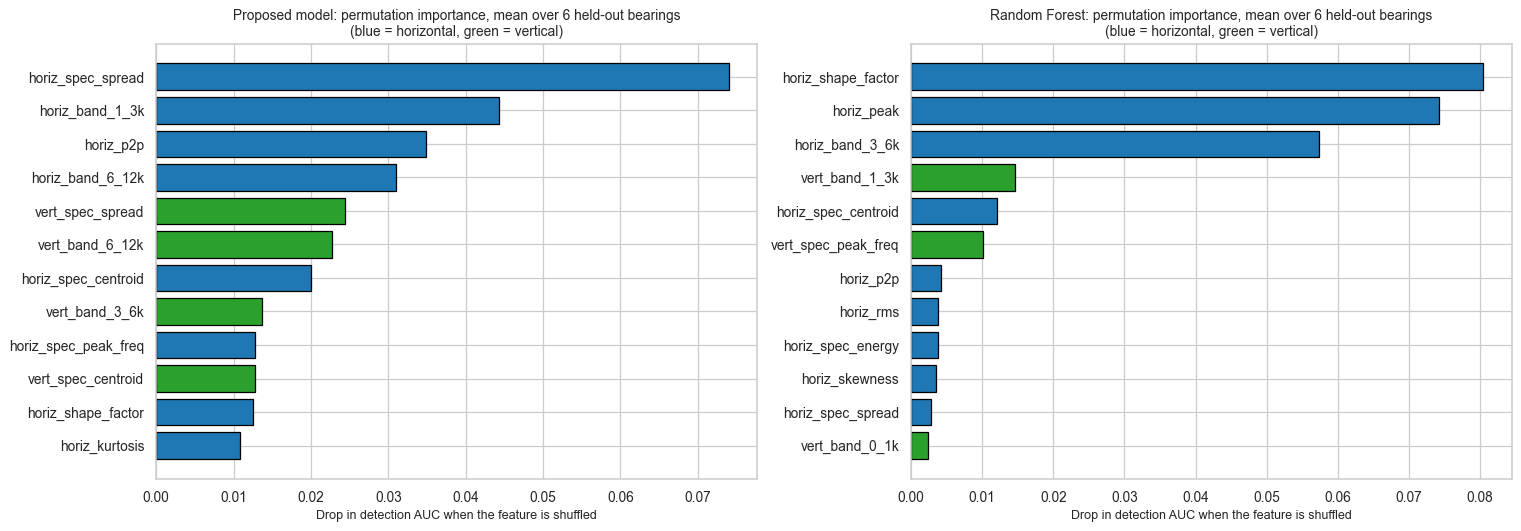

**Figure 21.** Top features by permutation importance. Proposed: `horiz_spec_spread` (+0.074), `horiz_band_1_3k` (+0.044), `horiz_p2p` (+0.035), `horiz_band_6_12k` (+0.031). Random Forest: `horiz_shape_factor` (+0.080), `horiz_peak` (+0.074), `horiz_band_3_6k` (+0.057), `vert_band_1_3k` (+0.015). Rank agreement between the two models (Spearman): **-0.05**. Importance of a feature inside a correlated block (Figure 7) is shared with its partners.

In [31]:
# ---- (b) permutation importance on held-out windows, per fold (proposed = fold model; Random Forest = refit in the fold) ----
def perm_importance(predict, Xh, mh, feat_axis_last=True, reps=2, seed=SEED):
    rng = np.random.default_rng(seed)
    def scores(pred_min):
        act = mh.rul_min.values <= C.STAGE_WARNING_MIN
        return np.abs(pred_min - mh.rul_cap_min.values)[act].mean(), Mx.detection_metrics(mh, -pred_min)["AUC_mean_h"]
    b_mae, b_auc = scores(predict(Xh)); out = []
    for j, name in enumerate(F.FEATURES):
        d_mae, d_auc = [], []
        for _ in range(reps):
            Xp = Xh.copy(); perm = rng.permutation(len(Xp))
            if Xp.ndim == 3: Xp[:, :, j] = Xp[perm, :, j]
            else: Xp[:, j] = Xp[perm, j]
            m_, a_ = scores(predict(Xp)); d_mae.append(m_ - b_mae); d_auc.append(b_auc - a_)
        out.append((name, np.mean(d_mae), np.mean(d_auc)))
    return pd.DataFrame(out, columns=["feature", "dMAE_actionable", "dAUC"]).set_index("feature")
imp_nn, imp_rf = [], []
for fi, f in enumerate(D.lobo_folds()):
    net_f, sc_f = kept_lobo[("proposed", SEED0, fi)]; Xh, mh = fold_windows[fi]
    imp_nn.append(perm_importance(lambda X: np.clip(net_f.predict(X, batch_size=1024, verbose=0)["rul_output"].ravel(), 0, 1) * C.RUL_CAP_MIN, Xh, mh))
    sc2 = D.fit_scaler(feats, table, f["train"] + [f["val"]]); Xt, mt = D.make_windows(table, feats, f["train"] + [f["val"]], sc2); Xh2, mh2 = D.make_windows(table, feats, [f["held_out"]], sc2)
    rf_f = M.Classical("Random Forest", SEED).fit(Xt, mt)
    imp_rf.append(perm_importance(lambda X: rf_f.predict(X)["pred_min"], Xh2, mh2))
    print(f"  fold {fi + 1}/6 done")
I_nn = pd.concat(imp_nn).groupby(level=0).mean(); I_rf = pd.concat(imp_rf).groupby(level=0).mean()
I_nn.to_csv(C.ARTIFACTS / "perm_importance_proposed_lobo.csv"); I_rf.to_csv(C.ARTIFACTS / "perm_importance_rf_lobo.csv")
fig, ax = plt.subplots(1, 2, figsize=(17, 6))
for a_, I, ttl in [(ax[0], I_nn, "Proposed model"), (ax[1], I_rf, "Random Forest")]:
    t_ = I.sort_values("dAUC", ascending=False).head(12).iloc[::-1]
    a_.barh(t_.index, t_.dAUC, color=["#1f77b4" if i.startswith("horiz") else "#2ca02c" for i in t_.index], edgecolor="black")
    a_.set_xlabel("Drop in detection AUC when the feature is shuffled"); a_.set_title(f"{ttl}: permutation importance, mean over 6 held-out bearings\n(blue = horizontal, green = vertical)")
plt.tight_layout(); R.savefig(fig, "fig_feature_importance_lobo.png"); plt.show()
rho = spearmanr(I_nn.dAUC, I_rf.dAUC)[0]
R.show(f"**Figure 21.** Top features by permutation importance. Proposed: " + ", ".join(f"`{i}` ({v:+.3f})" for i, v in I_nn.dAUC.sort_values(ascending=False).head(4).items()) +
       ". Random Forest: " + ", ".join(f"`{i}` ({v:+.3f})" for i, v in I_rf.dAUC.sort_values(ascending=False).head(4).items()) +
       f". Rank agreement between the two models (Spearman): **{rho:.2f}**. Importance of a feature inside a correlated block (Figure 7) is shared with its partners.")

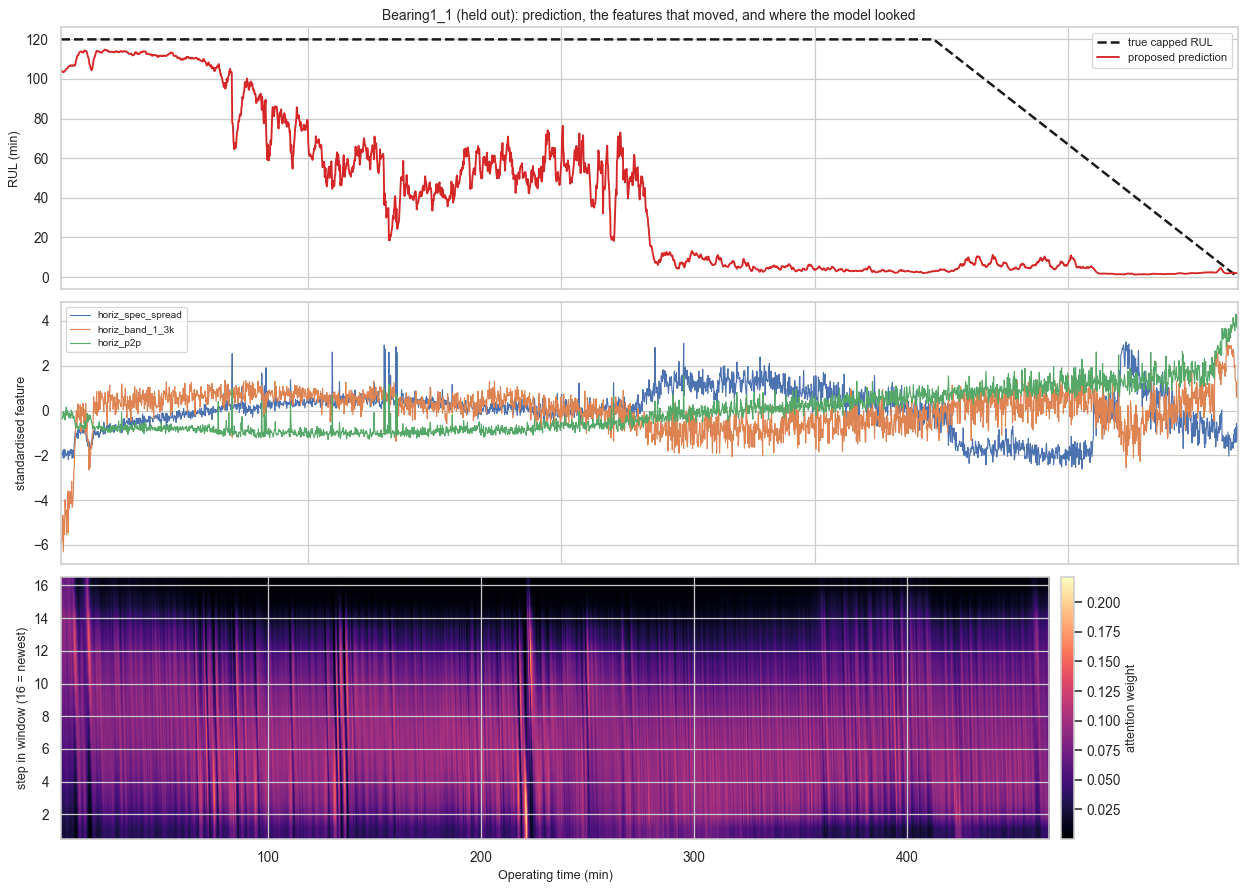

**Figure 22.** Example explanation for a held-out gradual bearing: prediction, the three features with the highest permutation importance, and the attention heat-map. Attention is shown as *what the model attended to*, not as the cause of the failure.

In [32]:
# ---- (c) representative explanation: one gradual bearing (Bearing1_1, fold 0) ----
fi = 0; b = C.LEARNING[fi]; net_f, sc_f = kept_lobo[("proposed", SEED0, fi)]; Xh, mh = fold_windows[fi]
attn_m = KModel(net_f.input, net_f.get_layer("temporal_attention").output[1]); A_ = attn_m.predict(Xh, batch_size=512, verbose=0)[:, :, 0]
pr = np.clip(net_f.predict(Xh, batch_size=512, verbose=0)["rul_output"].ravel(), 0, 1) * C.RUL_CAP_MIN
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
ax[0].plot(mh.time_min, mh.rul_cap_min, "k--", lw=2, label="true capped RUL"); ax[0].plot(mh.time_min, pr, color="#d62728", label="proposed prediction"); ax[0].set_ylabel("RUL (min)"); ax[0].legend(); ax[0].set_title(f"{b} (held out): prediction, the features that moved, and where the model looked")
top_f = list(I_nn.dAUC.sort_values(ascending=False).head(3).index)
for f_ in top_f:
    m = (table.bearing == b).values; g = table[m]
    ax[1].plot(g.time_min[C.WINDOW - 1:], (feats.loc[m, f_].values - feats.loc[m, f_].mean())[C.WINDOW - 1:] / (feats.loc[m, f_].std() + 1e-9), lw=0.9, label=f_)
ax[1].set_ylabel("standardised feature"); ax[1].legend(fontsize=8)
im = ax[2].imshow(A_.T, aspect="auto", origin="lower", extent=[mh.time_min.min(), mh.time_min.max(), 0.5, 16.5], cmap="magma"); ax[2].set_ylabel("step in window (16 = newest)"); ax[2].set_xlabel("Operating time (min)")
plt.colorbar(im, ax=ax[2], label="attention weight", pad=0.01); plt.tight_layout(); R.savefig(fig, "fig_explanation_example_lobo.png"); plt.show()
R.show("**Figure 22.** Example explanation for a held-out gradual bearing: prediction, the three features with the highest permutation importance, and the attention heat-map. Attention is shown as *what the model attended to*, not as the cause of the failure.")

In [33]:
p_uni = abl_att.mean_abs_change_min.mean(); c_uni = abl_att["corr"].mean()
verdict_att = ("**functionally important**: removing it changes predictions substantially" if p_uni > 10 or c_uni < 0.9 else "**functionally weak**: replacing it by uniform weights changes predictions only slightly")
R.show(f"### 20.1 What did we find?\n\n"
       f"* **Attention:** the attention layer is {verdict_att} (mean absolute change {p_uni:.1f} min, correlation {c_uni:.3f}). The stage-wise profiles differ only modestly from uniform weights (Figure 20a). "
       f"Attention therefore tells us *where in the 160 s window the network put more weight*, not *why the bearing is failing*.\n"
       f"* **Features:** permutation importance identifies which vibration features the models rely on (Figure 21); rank agreement between the proposed model and Random Forest is {rho:.2f}, so the two models rely on partly different cues, and correlated features share importance.\n"
       f"* **Does this support our hypothesis that the model is explainable?** Only in a limited sense: the model exposes inspectable weights and feature dependencies, but attention is **not** a causal explanation [9], and the importance analysis is descriptive. We claim *inspectability*, not *causal explanation*.")

### 20.1 What did we find?

* **Attention:** the attention layer is **functionally weak**: replacing it by uniform weights changes predictions only slightly (mean absolute change 1.4 min, correlation 0.996). The stage-wise profiles differ only modestly from uniform weights (Figure 20a). Attention therefore tells us *where in the 160 s window the network put more weight*, not *why the bearing is failing*.
* **Features:** permutation importance identifies which vibration features the models rely on (Figure 21); rank agreement between the proposed model and Random Forest is -0.05, so the two models rely on partly different cues, and correlated features share importance.
* **Does this support our hypothesis that the model is explainable?** Only in a limited sense: the model exposes inspectable weights and feature dependencies, but attention is **not** a causal explanation [9], and the importance analysis is descriptive. We claim *inspectability*, not *causal explanation*.

## 21. Early Warning Analysis (validation bearings)

**WHAT** – turn predictions into alarms and look at them as a maintenance engineer would: *when* does the model raise an alarm, *how much time is left*, and *how often does it cry wolf?*
**RULE (identical for all models).** An alarm is raised when the predicted stage is at least Warning (predicted RUL ≤ 60 min) for **3 consecutive windows**. Lead time = true remaining minutes at the first alarm inside the warning zone; false-alarm rate = fraction of truly Normal windows in alarm.
**EXPECT** – gradual bearings give tens of minutes of warning; abrupt bearings give little or none.

,false_alarm_rate,alarm active at end (of 6),median sustained lead (min),"median in-zone lead (min, lenient)"
model,,,,
Constant,0.00,0.0,NaN,NaN
Ridge,0.54,6.0,64.75,60.00
Random Forest,0.37,4.0,28.17,52.75
Gradient Boosting,0.36,4.0,29.75,52.75
CNN,0.56,5.5,61.83,60.00
LSTM,0.45,5.5,120.00,60.00
CNN + LSTM,0.52,6.0,50.08,60.00
CNN + BiLSTM,0.54,5.5,91.67,60.00
CNN + BiLSTM + Attention (single head),0.59,6.0,87.67,60.00


,alarm active at end,sustained lead (min),false-alarm rate,AUC h10,AUC h60
held-out bearing,,,,,
Bearing1_1,True,120.00,0.65,0.88,0.98
Bearing1_2,True,120.00,0.84,0.98,0.88
Bearing2_1,True,87.33,0.42,0.96,0.88
Bearing2_2,True,95.67,0.51,0.94,0.90
Bearing3_1,True,3.17,0.00,0.89,0.96
Bearing3_2,True,28.83,0.63,0.98,0.77


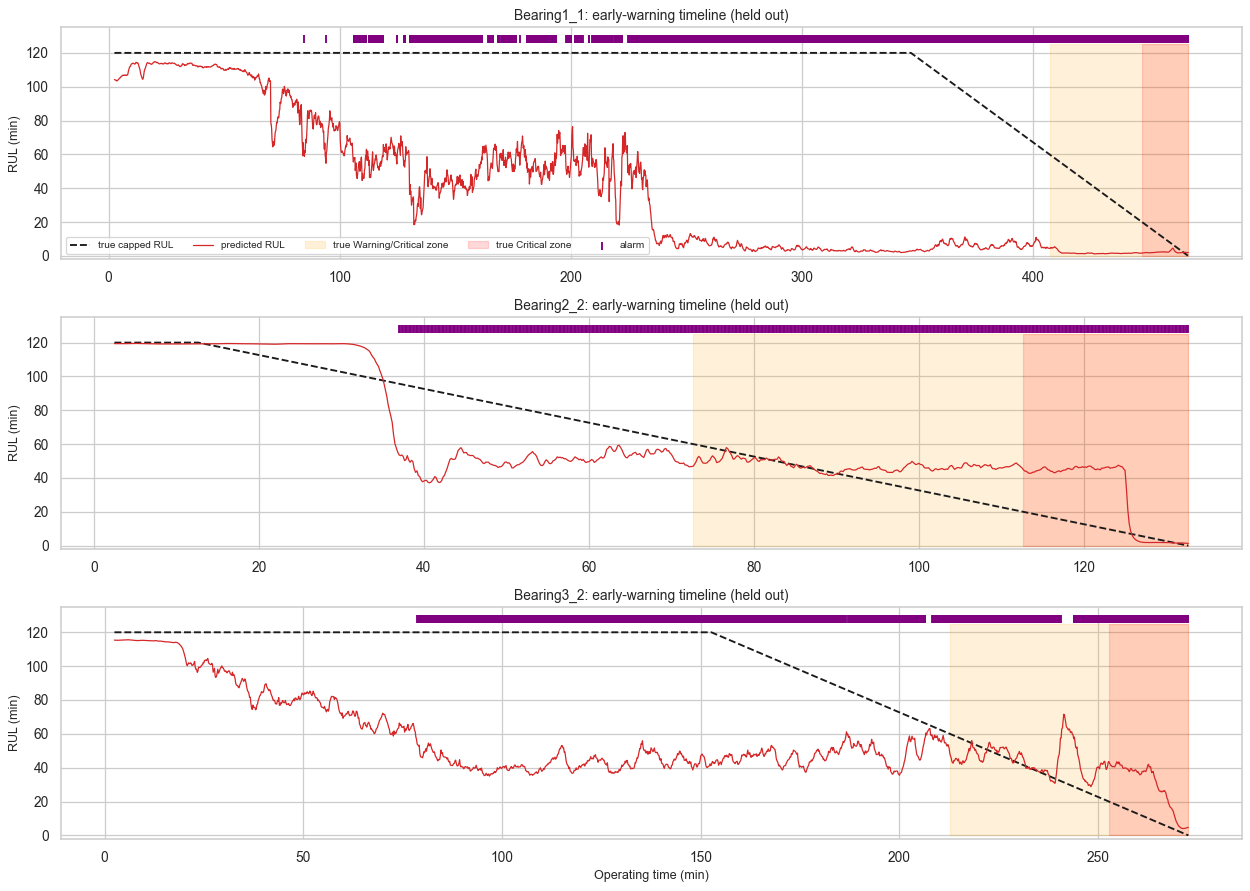

**Figure 23.** Early-warning timelines of three held-out learning bearings (gradual, hump, abrupt). Shaded = true warning/critical zones; purple ticks = alarms of the proposed model under the uniform rule.

In [34]:
rows = []
for m in E.ALL_MODELS:
    g = sm[sm.model == m]
    rows.append({"model": E.LABEL[m], "false_alarm_rate": g.false_alarm_rate.mean(), "alarm active at end (of 6)": g.alarm_at_end_bearings.mean() * 6 / 6 * 1.0,
                 "median sustained lead (min)": g.lead_sustained_min_median.median(), "median in-zone lead (min, lenient)": g.lead_min_median.median()})
ew = pd.DataFrame(rows).set_index("model"); ew["alarm active at end (of 6)"] = [sm[sm.model == m].groupby("fold").alarm_at_end_bearings.mean().sum() for m in E.ALL_MODELS]; display(ew.round(2))
# per bearing for the proposed model
g = sm[(sm.model == "proposed") & (sm.seed == SEED0)]
ewb = pd.DataFrame({"held-out bearing": [C.LEARNING[f] for f in g.fold], "alarm active at end": g.alarm_at_end_bearings.astype(bool).values, "sustained lead (min)": g.lead_sustained_min_median.values,
                    "false-alarm rate": g.false_alarm_rate.values, "AUC h10": g.AUC_h10.values, "AUC h60": g.AUC_h60.values}).set_index("held-out bearing")
display(ewb.round(2))

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for a_, b in zip(axes, ["Bearing1_1", "Bearing2_2", "Bearing3_2"]):
    g = pl[(pl.model == "proposed") & (pl.bearing == b)].sort_values("time_min")
    ps = Mx.rul_to_stage(g.pred_min.values); alarm = Mx.sustained(ps >= 1)
    a_.plot(g.time_min, g.rul_cap_min, "k--", lw=1.5, label="true capped RUL"); a_.plot(g.time_min, g.pred_min, color="#d62728", lw=1, label="predicted RUL")
    a_.fill_between(g.time_min, 0, 125, where=g.stage.values >= 1, color="orange", alpha=0.15, label="true Warning/Critical zone"); a_.fill_between(g.time_min, 0, 125, where=g.stage.values == 2, color="red", alpha=0.15, label="true Critical zone")
    a_.scatter(g.time_min[alarm], np.full(alarm.sum(), 128), marker="|", color="purple", s=40, label="alarm")
    a_.set_title(f"{b}: early-warning timeline (held out)"); a_.set_ylabel("RUL (min)"); a_.set_ylim(-2, 135)
axes[-1].set_xlabel("Operating time (min)"); axes[0].legend(ncol=5, fontsize=8); plt.tight_layout(); R.savefig(fig, "fig_early_warning_lobo.png"); plt.show()
R.show("**Figure 23.** Early-warning timelines of three held-out learning bearings (gradual, hump, abrupt). Shaded = true warning/critical zones; purple ticks = alarms of the proposed model under the uniform rule.")

### 21.1 What did we find?

In [35]:
pp_ = sm[sm.model == "proposed"]
far = pp_.false_alarm_rate.mean(); atend = int(pp_.groupby("fold").alarm_at_end_bearings.mean().sum())
weak = ewb[(~ewb["alarm active at end"]) | (ewb["sustained lead (min)"] < 10)]
R.show(f"* Under the uniform alarm rule the proposed model has a **false-alarm rate of {far:.2f}** on truly healthy windows in the validation bearings (Random Forest {sm[sm.model=='Random Forest'].false_alarm_rate.mean():.2f}, Gradient Boosting {sm[sm.model=='Gradient Boosting'].false_alarm_rate.mean():.2f}). A rate this high means the alarm is often already on before the warning zone; the *lenient* lead time therefore saturates at 60 min for almost every model and is **not** a meaningful measure of early warning.\n\n"
       f"* The strict view: the alarm is still active at the last window for {atend} of 6 held-out bearings (seed-mean); the median sustained lead is {ew.loc[E.LABEL['proposed'], 'median sustained lead (min)']:.1f} min. Bearings without a useful warning (alarm not active at the end or sustained lead < 10 min): " + (", ".join(weak.index) if len(weak) else "none") + ".\n\n"
       "* **H3 (a useful warning for every bearing)** cannot be concluded from this validation view alone; it is evaluated on the test bearings in Section 26. The false-alarm price of alarming early is the dominant limitation of the alarm layer.")

* Under the uniform alarm rule the proposed model has a **false-alarm rate of 0.52** on truly healthy windows in the validation bearings (Random Forest 0.37, Gradient Boosting 0.36). A rate this high means the alarm is often already on before the warning zone; the *lenient* lead time therefore saturates at 60 min for almost every model and is **not** a meaningful measure of early warning.

* The strict view: the alarm is still active at the last window for 6 of 6 held-out bearings (seed-mean); the median sustained lead is 91.5 min. Bearings without a useful warning (alarm not active at the end or sustained lead < 10 min): Bearing3_1.

* **H3 (a useful warning for every bearing)** cannot be concluded from this validation view alone; it is evaluated on the test bearings in Section 26. The false-alarm price of alarming early is the dominant limitation of the alarm layer.

## 22. Final Unseen Test

**WHAT** – the design is now **frozen**: features, targets, cap and stage boundaries, architecture, training recipe, epochs (from LOBO), and the model-selection file `artifacts/selection.json` were all fixed using the learning bearings only. Now (and only now) the models are trained on **all 6 learning bearings** and each is evaluated **once** on the 11 test bearings (`Full_Test_Set`, truncated at the official end of life).
**GUARDS.** The cell (i) asserts that the configuration equals the snapshot stored at selection time, (ii) asserts that the training data contains only learning bearings and the scoring data only test bearings, and (iii) refuses to run twice in the same session.
**WHY** – the test bearings simulate a *new machine*. Any use of them for decisions would invalidate the result.
**EXPECT** – test performance similar to (or worse than) the LOBO estimates, with the same bearing-to-bearing variability.

In [36]:
assert "TEST_SCORED" not in globals(), "The test bearings were already scored in this session: results must not be regenerated after inspection."
L.check_config_frozen(CFG_AT_SELECTION, L.config_snapshot())
assert (C.ARTIFACTS / "selection.json").exists()
D.assert_disjoint(C.LEARNING, C.TEST)
t0 = time.time()
pred_test, kept_final, hist_final, sc_final, (Xtr_f, mtr_f, Xte_f, mte_f) = E.run_final(table, feats, E.ALL_MODELS, C.SEEDS_FINAL, sel["epochs_by_model"])
assert set(mtr_f.bearing) == set(C.LEARNING) and set(mte_f.bearing) == set(C.TEST)
TEST_SCORED = True
print(f"final training on {len(Xtr_f):,} windows of 6 learning bearings; scored {len(Xte_f):,} windows of 11 test bearings  ({time.time()-t0:.0f}s)")
pred_test.to_csv(C.ARTIFACTS / "final_predictions_test.csv", index=False)

# ---- save the final proposed model and all preprocessing artefacts (used by the demo in Section 23 from disk) ----
import joblib
kept_final[("proposed", C.SEEDS_FINAL[0])].save(C.ARTIFACTS / "final_proposed_model.keras")
joblib.dump(sc_final, C.ARTIFACTS / "final_scaler.pkl")
json.dump({"features": F.FEATURES, "log10_features": F.LOG_FEATURES, "window": C.WINDOW, "rul_cap_min": C.RUL_CAP_MIN, "stage_bounds_min": [C.STAGE_CRITICAL_MIN, C.STAGE_WARNING_MIN]}, open(C.ARTIFACTS / "final_feature_config.json", "w"), indent=1)

  final Constant done - 0s


  final Ridge done - 1s


  final Random Forest done - 53s


  final Gradient Boosting done - 71s


  final cnn done - 92s


...

  final cnn_bilstm done - 262s


  final cnn_bilstm_attn done - 381s


  final cnn_bilstm_dual done - 455s


  final proposed done - 532s


final training on 7,444 windows of 6 learning bearings; scored 16,934 windows of 11 test bearings  (533s)


In [37]:
trunc = {b: D.truncated_length(b) for b in C.TEST}
metric_cols = ["MAE_min", "MAE_min_actionable", "AUC_h10", "AUC_h60", "AUC_mean_h", "stage_macroF1", "false_alarm_rate", "detected_bearings"]
sm_test = E.summarize(pred_test, by=("model", "seed"))
phm_rows = []
for (m, sd), g in pred_test.groupby(["model", "seed"], sort=False):
    sc_, tab_ = Mx.official_phm(g[["bearing", "snapshot_idx"]].reset_index(drop=True), g.pred_min.values, trunc); phm_rows.append({"model": m, "seed": sd, "PHM_official": sc_})
sm_test = sm_test.merge(pd.DataFrame(phm_rows), on=["model", "seed"])
sm_test.to_csv(C.ARTIFACTS / "final_metrics_per_model_seed.csv", index=False)
gt = sm_test.groupby("model", sort=False)
tab_test = pd.DataFrame({c: gt[c].apply(R.fmt_ms) for c in metric_cols[:-1] + ["PHM_official"]}).loc[E.ALL_MODELS]
tab_test["alarm active at end (of 11)"] = [f"{sm_test[sm_test.model==m].alarm_at_end_bearings.mean():.1f}" for m in E.ALL_MODELS]
tab_test.index = [E.LABEL[m] for m in E.ALL_MODELS]
display(tab_test); tab_test.to_csv(C.ARTIFACTS / "final_model_comparison_test.csv")

R.show("**Official PHM 2012 score, per bearing (proposed model, seed 42).** One prediction per test bearing at the truncation point, percentage error `%Er = 100 (ActRUL - PredRUL)/ActRUL`, `A = exp(-ln(0.5) Er/5)` if `Er <= 0` (late) else `exp(+ln(0.5) Er/20)` (early), mean over the 11 bearings [2]. The predictor is capped at 120 min = 7200 s, so it cannot exceed that; bearings 1_7 and 2_3 have official RUL above 7200 s.")
g = pred_test[(pred_test.model == "proposed") & (pred_test.seed == C.SEEDS_FINAL[0])].reset_index(drop=True)
sc_p, phm_tab = Mx.official_phm(g[["bearing", "snapshot_idx"]], g.pred_min.values, trunc); display(phm_tab.round(3)); print(f"official PHM-2012 score (proposed, seed 42): {sc_p:.3f}")
gc = pred_test[(pred_test.model == "Constant")].reset_index(drop=True); print(f"official PHM-2012 score of the constant predictor: {Mx.official_phm(gc[['bearing','snapshot_idx']], gc.pred_min.values, trunc)[0]:.3f}")

,MAE_min,MAE_min_actionable,AUC_h10,AUC_h60,AUC_mean_h,stage_macroF1,false_alarm_rate,PHM_official,alarm active at end (of 11)
Constant,35.623,56.354,0.500,0.500,0.500,0.291,0.000,0.124,0.0
Ridge,39.066,45.216,0.664,0.585,0.640,0.422,0.198,0.040,7.0
Random Forest,32.640 +/- 0.101,32.713 +/- 0.124,0.654 +/- 0.002,0.768 +/- 0.001,0.696 +/- 0.002,0.427 +/- 0.001,0.296 +/- 0.001,0.078 +/- 0.005,9.7
Gradient Boosting,30.146 +/- 0.000,32.651 +/- 0.000,0.694 +/- 0.000,0.778 +/- 0.000,0.725 +/- 0.000,0.471 +/- 0.000,0.237 +/- 0.000,0.037 +/- 0.000,10.0
CNN,27.806 +/- 0.889,42.575 +/- 2.302,0.751 +/- 0.030,0.694 +/- 0.035,0.732 +/- 0.032,0.454 +/- 0.019,0.146 +/- 0.011,0.181 +/- 0.022,10.0
LSTM,32.324 +/- 0.773,36.779 +/- 2.906,0.739 +/- 0.005,0.710 +/- 0.024,0.728 +/- 0.011,0.450 +/- 0.027,0.208 +/- 0.022,0.143 +/- 0.023,10.3
CNN + LSTM,30.610 +/- 3.932,42.055 +/- 1.535,0.719 +/- 0.010,0.708 +/- 0.034,0.715 +/- 0.009,0.423 +/- 0.065,0.182 +/- 0.059,0.221 +/- 0.027,10.0
CNN + BiLSTM,34.205 +/- 3.342,40.092 +/- 7.291,0.737 +/- 0.061,0.703 +/- 0.060,0.725 +/- 0.055,0.410 +/- 0.041,0.225 +/- 0.070,0.106 +/- 0.026,9.7
CNN + BiLSTM + Attention (single head),32.336 +/- 5.166,41.184 +/- 4.669,0.726 +/- 0.041,0.706 +/- 0.025,0.715 +/- 0.034,0.433 +/- 0.050,0.202 +/- 0.071,0.179 +/- 0.023,9.0
"CNN + BiLSTM (dual head, no attention)",35.047 +/- 3.243,34.110 +/- 5.958,0.741 +/- 0.029,0.769 +/- 0.038,0.748 +/- 0.026,0.399 +/- 0.045,0.277 +/- 0.055,0.093 +/- 0.031,8.7


**Official PHM 2012 score, per bearing (proposed model, seed 42).** One prediction per test bearing at the truncation point, percentage error `%Er = 100 (ActRUL - PredRUL)/ActRUL`, `A = exp(-ln(0.5) Er/5)` if `Er <= 0` (late) else `exp(+ln(0.5) Er/20)` (early), mean over the 11 bearings [2]. The predictor is capped at 120 min = 7200 s, so it cannot exceed that; bearings 1_7 and 2_3 have official RUL above 7200 s.

,actual_RUL_s,predicted_RUL_s,pct_error,A_i
bearing,,,,
Bearing1_3,5730,6376.9,-11.3,0.209
Bearing1_4,339,53.1,84.3,0.054
Bearing1_5,1610,6873.7,-326.9,0.000
Bearing1_6,1460,2827.1,-93.6,0.000
Bearing1_7,7570,468.4,93.8,0.039
Bearing2_3,7530,6932.8,7.9,0.760
Bearing2_4,1390,7102.0,-410.9,0.000
Bearing2_5,3090,5647.6,-82.8,0.000
Bearing2_6,1290,2734.1,-111.9,0.000


official PHM-2012 score (proposed, seed 42): 0.097
official PHM-2012 score of the constant predictor: 0.124


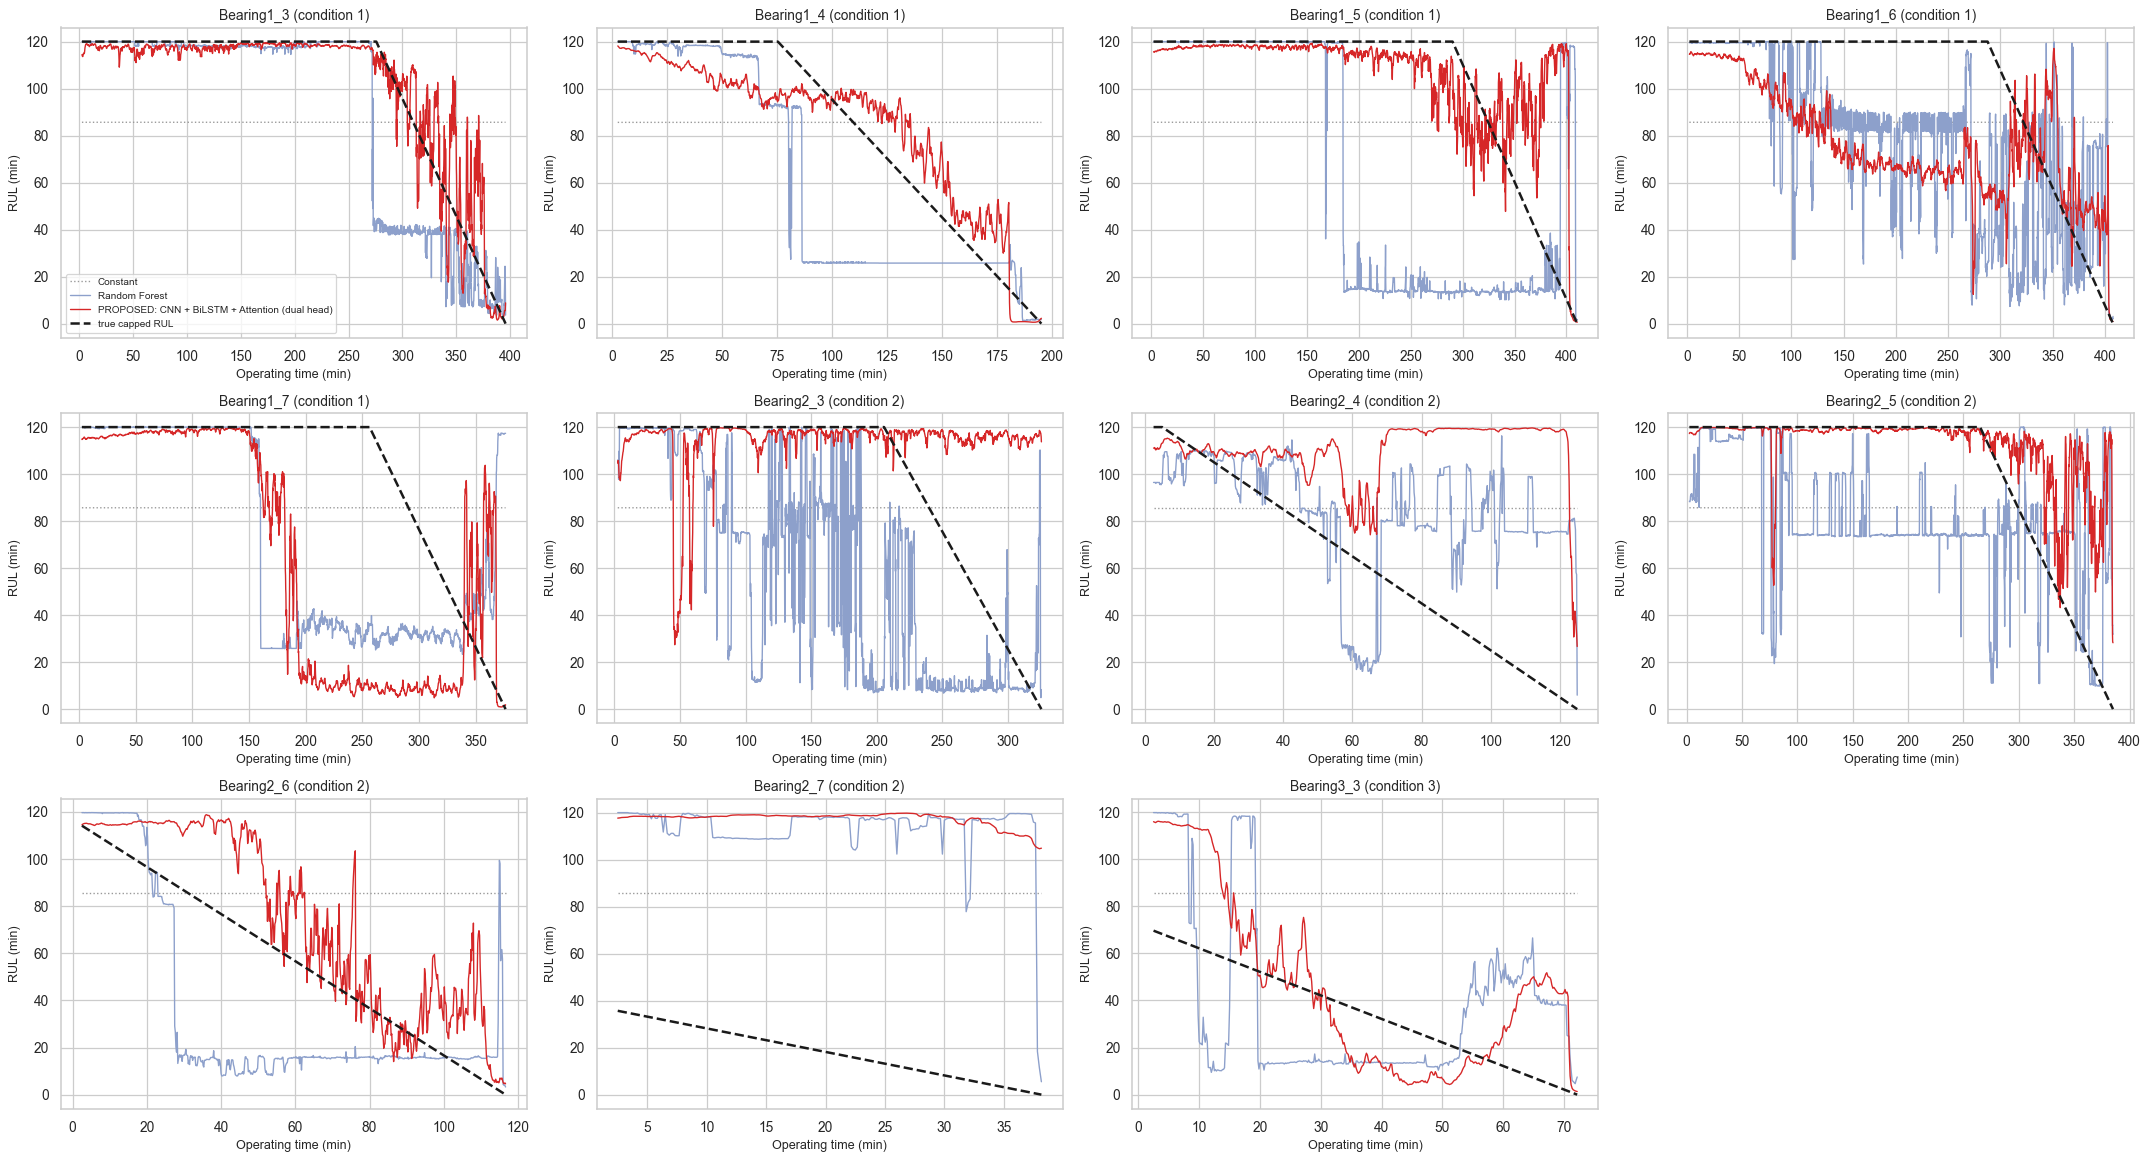

**Figure 24.** Predicted vs true capped RUL for every test bearing (seed 42). This is the direct visual answer to 'does the model warn in time?'.

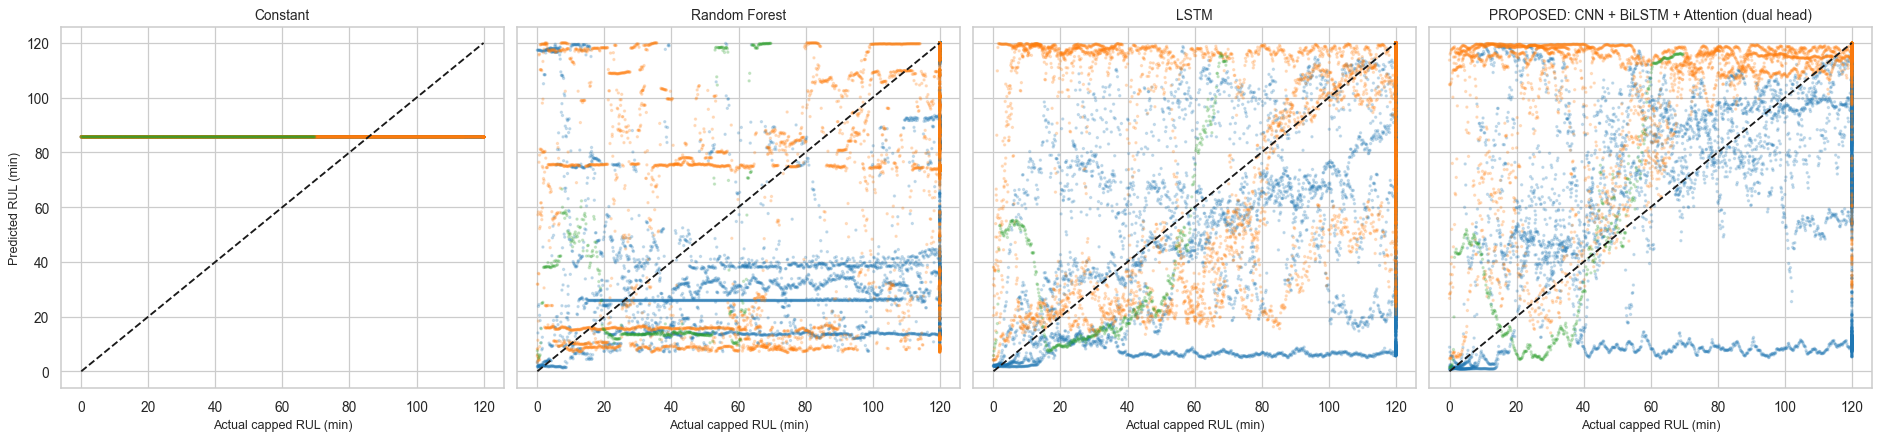

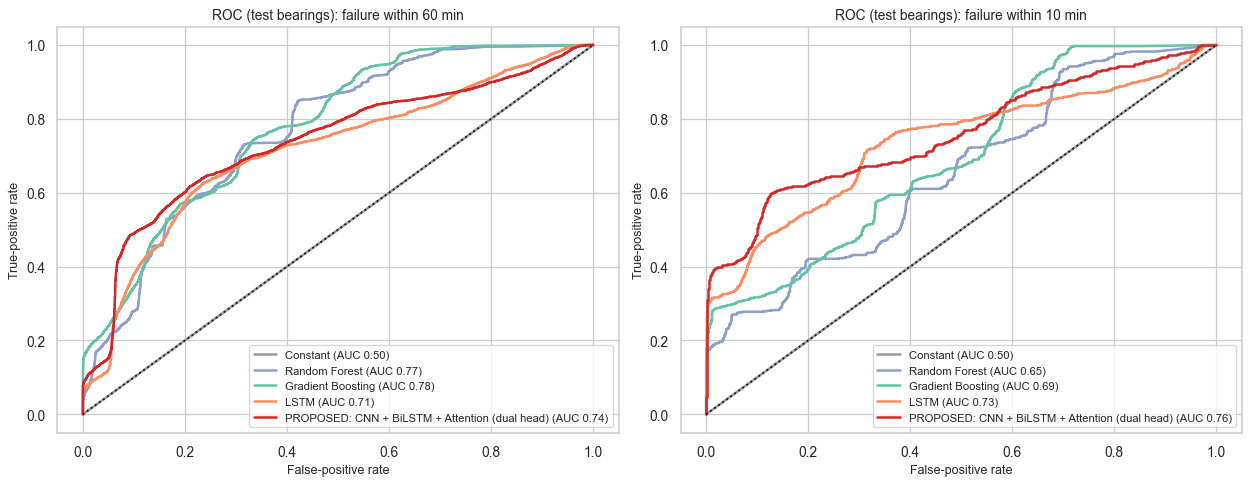

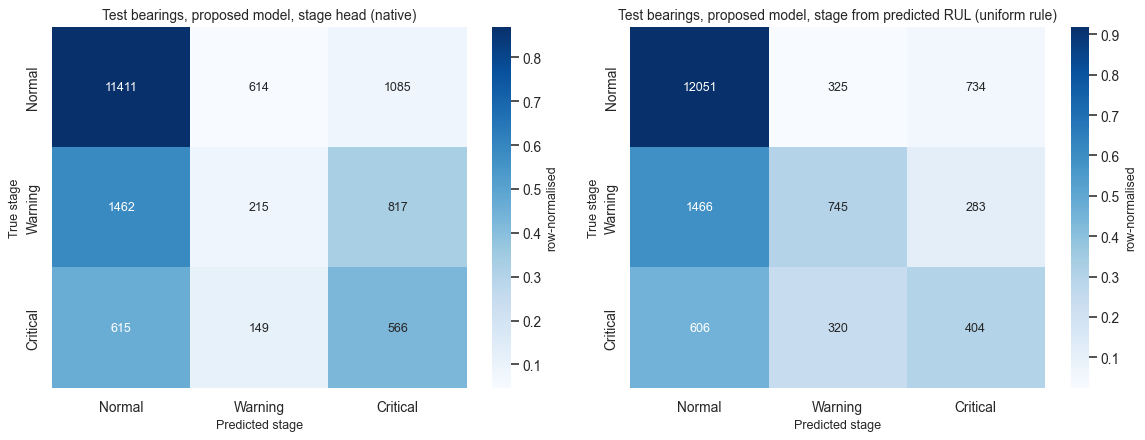

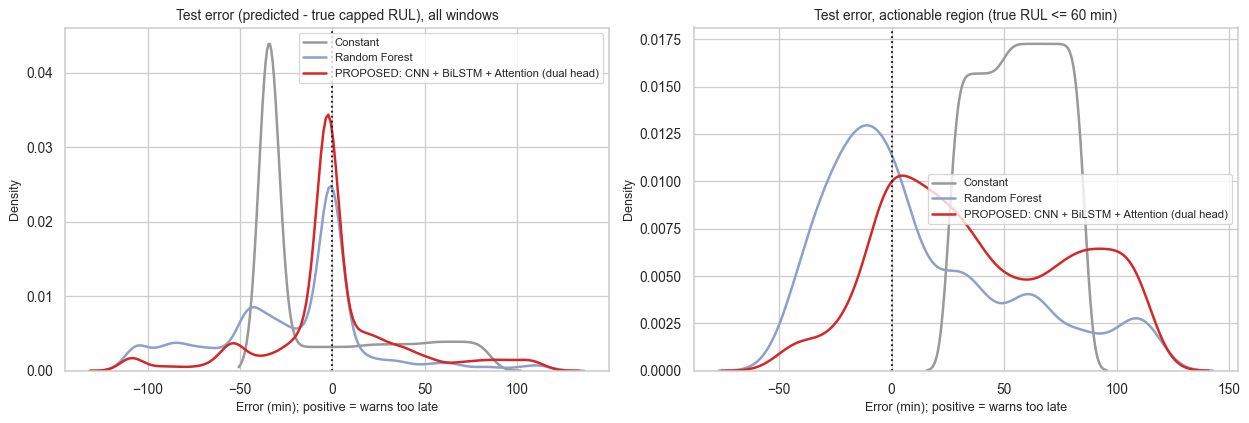

**Figures 25-27.** Actual-vs-predicted scatter, ROC curves and confusion matrices on the 11 unseen test bearings; error distribution (right-hand side positive = the model thinks more life is left than there is).

In [38]:
# ---- figures on the test bearings ----
SEED0 = C.SEEDS_FINAL[0]
pt = pred_test[pred_test.seed == SEED0]
fig, axes = plt.subplots(3, 4, figsize=(24, 13)); axes = axes.ravel()
for a_, b in zip(axes, C.TEST):
    for m, col, ls in [("Constant", "#999999", ":"), ("Random Forest", "#8da0cb", "-"), ("proposed", "#d62728", "-")]:
        g_ = pt[(pt.model == m) & (pt.bearing == b)].sort_values("time_min"); a_.plot(g_.time_min, g_.pred_min, color=col, ls=ls, lw=1.1, label=E.LABEL[m])
    g_ = pt[(pt.model == "proposed") & (pt.bearing == b)].sort_values("time_min"); a_.plot(g_.time_min, g_.rul_cap_min, "k--", lw=2, label="true capped RUL")
    a_.set_title(f"{b} (condition {C.condition_of(b)})"); a_.set_xlabel("Operating time (min)"); a_.set_ylabel("RUL (min)")
axes[0].legend(fontsize=8); axes[-1].axis("off"); plt.tight_layout(); R.savefig(fig, "fig_per_bearing_test.png"); plt.show()
R.show("**Figure 24.** Predicted vs true capped RUL for every test bearing (seed 42). This is the direct visual answer to 'does the model warn in time?'.")

fig, ax = plt.subplots(1, 4, figsize=(21, 5), sharex=True, sharey=True)
for a_, m in zip(ax, ["Constant", "Random Forest", "lstm", "proposed"]):
    g_ = pt[pt.model == m]; a_.scatter(g_.rul_cap_min, g_.pred_min, s=3, alpha=0.2, c=[COND_COLOR[c] for c in g_.condition]); a_.plot([0, 120], [0, 120], "k--"); a_.set_title(E.LABEL[m]); a_.set_xlabel("Actual capped RUL (min)")
ax[0].set_ylabel("Predicted RUL (min)"); plt.tight_layout(); R.savefig(fig, "fig_actual_vs_predicted_test.png"); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for a_, h in zip(ax, [60, 10]):
    for m, col in [("Constant", "#999999"), ("Random Forest", "#8da0cb"), ("Gradient Boosting", "#66c2a5"), ("lstm", "#fc8d62"), ("proposed", "#d62728")]:
        g_ = pt[pt.model == m]; y = (g_.rul_min <= h).astype(int); fpr, tpr, _ = roc_curve(y, -g_.pred_min); a_.plot(fpr, tpr, color=col, lw=2, label=f"{E.LABEL[m]} (AUC {roc_auc_score(y, -g_.pred_min):.2f})")
    a_.plot([0, 1], [0, 1], "k:"); a_.set_xlabel("False-positive rate"); a_.set_ylabel("True-positive rate"); a_.set_title(f"ROC (test bearings): failure within {h} min"); a_.legend()
plt.tight_layout(); R.savefig(fig, "fig_roc_test.png"); plt.show()
g_ = pt[pt.model == "proposed"]
cm_n = confusion_matrix(g_.stage, g_[["prob0", "prob1", "prob2"]].values.argmax(1), labels=[0, 1, 2]); cm_u = confusion_matrix(g_.stage, Mx.rul_to_stage(g_.pred_min.values), labels=[0, 1, 2])
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a_, cm, ttl in [(ax[0], cm_n, "stage head (native)"), (ax[1], cm_u, "stage from predicted RUL (uniform rule)")]:
    sns.heatmap(cm / cm.sum(1, keepdims=True), annot=cm, fmt="d", cmap="Blues", ax=a_, xticklabels=["Normal", "Warning", "Critical"], yticklabels=["Normal", "Warning", "Critical"], cbar_kws={"label": "row-normalised"}); a_.set_xlabel("Predicted stage"); a_.set_ylabel("True stage"); a_.set_title(f"Test bearings, proposed model, {ttl}")
plt.tight_layout(); R.savefig(fig, "fig_confusion_test.png"); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for m, col in [("Constant", "#999999"), ("Random Forest", "#8da0cb"), ("proposed", "#d62728")]:
    g_ = pt[pt.model == m]; sns.kdeplot(g_.pred_min - g_.rul_cap_min, ax=ax[0], color=col, label=E.LABEL[m], lw=2); sns.kdeplot((g_.pred_min - g_.rul_cap_min)[g_.rul_min <= 60], ax=ax[1], color=col, label=E.LABEL[m], lw=2)
ax[0].set_title("Test error (predicted - true capped RUL), all windows"); ax[1].set_title("Test error, actionable region (true RUL <= 60 min)")
for a_ in ax: a_.axvline(0, color="k", ls=":"); a_.set_xlabel("Error (min); positive = warns too late"); a_.legend()
plt.tight_layout(); R.savefig(fig, "fig_error_distribution_test.png"); plt.show()
R.show("**Figures 25-27.** Actual-vs-predicted scatter, ROC curves and confusion matrices on the 11 unseen test bearings; error distribution (right-hand side positive = the model thinks more life is left than there is).")

In [39]:
# ---- classification metrics of the stage (accuracy, precision, recall, F1 per class), final test, mean over seeds ----
cls_cols = ["stage_acc", "stage_precision_Normal", "stage_precision_Warning", "stage_precision_Critical", "stage_recall_Normal", "stage_recall_Warning", "stage_recall_Critical", "stage_macroF1"]
tb = sm_test.groupby("model", sort=False)[cls_cols].mean().loc[E.ALL_MODELS]; tb.index = [E.LABEL[m] for m in E.ALL_MODELS]
R.show("**Stage classification on the 11 test bearings - uniform rule (stage derived from the predicted RUL with the same thresholds for every model):**")
display(tb.round(3).rename(columns=lambda c: c.replace("stage_", "")))
nat_models = ["Random Forest", "cnn_bilstm_dual", "proposed"]
nat = sm_test[sm_test.model.isin(nat_models)].groupby("model", sort=False)[[c.replace("stage_", "native_") for c in cls_cols]].mean().loc[nat_models]; nat.index = [E.LABEL[m] for m in nat_models]
R.show("**Native stage heads / classifiers (their own class predictions):**")
display(nat.round(3).rename(columns=lambda c: c.replace("native_", "")))
pp_ = tb.loc[E.LABEL["proposed"]]; pn_ = nat.loc[E.LABEL["proposed"]]
R.show(f"**Reading.** Proposed model, uniform rule: accuracy {pp_.stage_acc:.2f}; recall Normal / Warning / Critical = {pp_.stage_recall_Normal:.2f} / {pp_.stage_recall_Warning:.2f} / {pp_.stage_recall_Critical:.2f}; precision = {pp_.stage_precision_Normal:.2f} / {pp_.stage_precision_Warning:.2f} / {pp_.stage_precision_Critical:.2f}. "
       f"Its native stage head: accuracy {pn_.native_acc:.2f}, recall {pn_.native_recall_Normal:.2f} / {pn_.native_recall_Warning:.2f} / {pn_.native_recall_Critical:.2f}. "
       "Accuracy is dominated by the large Normal class; recall of the rare Critical class (the operationally important one) and macro-F1 are the informative numbers.")

**Stage classification on the 11 test bearings - uniform rule (stage derived from the predicted RUL with the same thresholds for every model):**

,acc,precision_Normal,precision_Warning,precision_Critical,recall_Normal,recall_Warning,recall_Critical,macroF1
Constant,0.774,0.774,0.000,0.000,1.000,0.000,0.000,0.291
Ridge,0.628,0.808,0.150,0.449,0.739,0.257,0.230,0.422
Random Forest,0.616,0.892,0.238,0.158,0.693,0.336,0.384,0.427
Gradient Boosting,0.652,0.867,0.237,0.439,0.722,0.506,0.229,0.471
CNN,0.689,0.845,0.263,0.448,0.800,0.354,0.217,0.454
LSTM,0.645,0.875,0.228,0.221,0.730,0.307,0.433,0.450
CNN + LSTM,0.639,0.856,0.168,0.234,0.743,0.207,0.421,0.423
CNN + BiLSTM,0.600,0.857,0.161,0.245,0.690,0.233,0.405,0.410
CNN + BiLSTM + Attention (single head),0.632,0.861,0.208,0.231,0.724,0.274,0.396,0.433
"CNN + BiLSTM (dual head, no attention)",0.577,0.890,0.162,0.186,0.650,0.256,0.448,0.399


**Native stage heads / classifiers (their own class predictions):**

,acc,precision_Normal,precision_Warning,precision_Critical,recall_Normal,recall_Warning,recall_Critical,macroF1
Random Forest,0.681,0.868,0.230,0.170,0.818,0.057,0.504,0.396
"CNN + BiLSTM (dual head, no attention)",0.511,0.892,0.131,0.131,0.576,0.111,0.624,0.345
PROPOSED: CNN + BiLSTM + Attention (dual head),0.596,0.871,0.165,0.167,0.695,0.097,0.549,0.377


**Reading.** Proposed model, uniform rule: accuracy 0.67; recall Normal / Warning / Critical = 0.76 / 0.33 / 0.39; precision = 0.87 / 0.31 / 0.26. Its native stage head: accuracy 0.60, recall 0.70 / 0.10 / 0.55. Accuracy is dominated by the large Normal class; recall of the rare Critical class (the operationally important one) and macro-F1 are the informative numbers.

,windows,MAE_min,MAE_min_actionable,AUC_h10,AUC_h60,stage_macroF1,false_alarm_rate,alarm_at_end_bearings,lead_sustained_min_median
bearing,,,,,,,,,
Bearing1_3,2360,5.95,17.81,0.99,0.99,0.84,0.01,1,19.67
Bearing1_4,1157,13.36,13.91,0.99,1.00,0.83,0.00,1,41.32
Bearing1_5,2448,14.59,58.92,0.91,0.74,0.50,0.00,1,7.67
Bearing1_6,2433,33.58,23.08,0.96,0.86,0.58,0.09,1,4.17
Bearing1_7,2244,42.20,35.39,0.90,0.73,0.39,0.41,1,8.00
Bearing2_3,1940,25.39,85.36,0.65,0.70,0.29,0.03,0,NaN
Bearing2_4,736,49.72,84.08,0.44,0.10,0.23,0.00,1,1.17
Bearing2_5,2296,13.94,58.77,0.84,0.96,0.36,0.00,1,0.33
Bearing2_6,686,19.54,16.11,0.88,0.99,0.63,0.00,1,6.50


,false_alarm_rate,alarm active at end (of 11),median sustained lead (min),"in-zone lead, lenient (min)"
model,,,,
Constant,0.00,0.00,NaN,NaN
Ridge,0.20,7.00,44.50,35.00
Random Forest,0.30,9.67,1.25,60.00
Gradient Boosting,0.24,10.00,1.08,60.00
CNN,0.15,10.00,9.92,50.92
LSTM,0.21,10.33,19.83,59.98
CNN + LSTM,0.18,10.00,10.91,59.65
CNN + BiLSTM,0.22,9.67,17.67,60.00
CNN + BiLSTM + Attention (single head),0.20,9.00,18.67,59.99


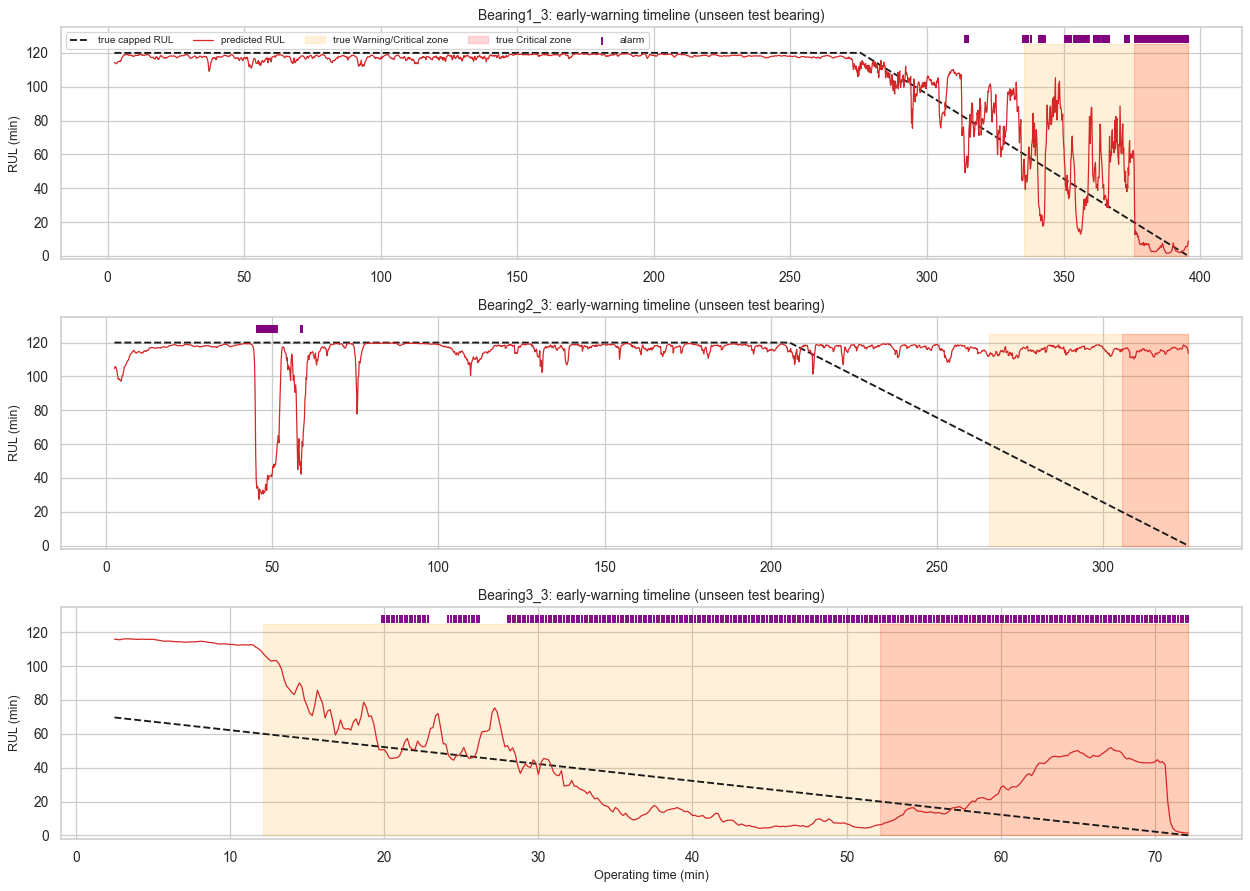

**Figure 28.** Early-warning timelines for the first test bearing of each operating condition (chosen by a rule fixed in advance, not by result).

In [40]:
# ---- per-bearing test results (proposed) and early warning ----
g = pt[pt.model == "proposed"].reset_index(drop=True)
pb_test = Mx.per_bearing_table(g[["bearing", "snapshot_idx", "time_min", "rul_min", "rul_cap_min", "y_rul", "stage", "condition"]], g.pred_min.values, Mx.rul_to_stage(g.pred_min.values))
pb_test["AUC_h10"] = [roc_auc_score(g[g.bearing == b].rul_min <= 10, -g[g.bearing == b].pred_min) for b in pb_test.index]
pb_test["AUC_h60"] = [roc_auc_score(g[g.bearing == b].rul_min <= 60, -g[g.bearing == b].pred_min) if 0 < (g[g.bearing == b].rul_min <= 60).mean() < 1 else np.nan for b in pb_test.index]
display(pb_test[["windows", "MAE_min", "MAE_min_actionable", "AUC_h10", "AUC_h60", "stage_macroF1", "false_alarm_rate", "alarm_at_end_bearings", "lead_sustained_min_median"]].round(2))
pb_test.to_csv(C.ARTIFACTS / "final_per_bearing_proposed.csv")
ew_t = pd.DataFrame([{"model": E.LABEL[m], "false_alarm_rate": sm_test[sm_test.model == m].false_alarm_rate.mean(), "alarm active at end (of 11)": sm_test[sm_test.model == m].alarm_at_end_bearings.mean(),
                      "median sustained lead (min)": sm_test[sm_test.model == m].lead_sustained_min_median.median(), "in-zone lead, lenient (min)": sm_test[sm_test.model == m].lead_min_median.median()} for m in E.ALL_MODELS]).set_index("model"); display(ew_t.round(2))

REP = ["Bearing1_3", "Bearing2_3", "Bearing3_3"]      # rule fixed in advance: the first test bearing of each operating condition
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for a_, b in zip(axes, REP):
    g_ = pt[(pt.model == "proposed") & (pt.bearing == b)].sort_values("time_min"); ps = Mx.rul_to_stage(g_.pred_min.values); alarm = Mx.sustained(ps >= 1)
    a_.plot(g_.time_min, g_.rul_cap_min, "k--", lw=1.5, label="true capped RUL"); a_.plot(g_.time_min, g_.pred_min, color="#d62728", lw=1, label="predicted RUL")
    a_.fill_between(g_.time_min, 0, 125, where=g_.stage.values >= 1, color="orange", alpha=0.15, label="true Warning/Critical zone"); a_.fill_between(g_.time_min, 0, 125, where=g_.stage.values == 2, color="red", alpha=0.15, label="true Critical zone")
    a_.scatter(g_.time_min[alarm], np.full(alarm.sum(), 128), marker="|", color="purple", s=40, label="alarm"); a_.set_title(f"{b}: early-warning timeline (unseen test bearing)"); a_.set_ylabel("RUL (min)"); a_.set_ylim(-2, 135)
axes[-1].set_xlabel("Operating time (min)"); axes[0].legend(ncol=5, fontsize=8); plt.tight_layout(); R.savefig(fig, "fig_early_warning_test.png"); plt.show()
R.show("**Figure 28.** Early-warning timelines for the first test bearing of each operating condition (chosen by a rule fixed in advance, not by result).")

,step,metric,mean_diff,ci_lo,ci_hi,units_improved,verdict
0,CNN -> CNN+LSTM (add recurrence),detection AUC at 10 min,-0.055,-0.110,-0.002,3/11,measurable degradation
1,CNN -> CNN+LSTM (add recurrence),actionable RUL MAE (min),-0.396,-6.187,3.527,4/11,no measurable difference (CI includes 0)
2,LSTM -> BiLSTM (make it bidirectional),detection AUC at 10 min,0.020,-0.026,0.074,6/11,no measurable difference (CI includes 0)
3,LSTM -> BiLSTM (make it bidirectional),actionable RUL MAE (min),-1.976,-7.567,3.523,7/11,no measurable difference (CI includes 0)
4,add attention (single head),detection AUC at 10 min,-0.024,-0.072,0.022,4/11,no measurable difference (CI includes 0)
5,add attention (single head),actionable RUL MAE (min),1.099,-4.000,6.421,6/11,no measurable difference (CI includes 0)
6,add second head (dual head),detection AUC at 10 min,0.065,0.002,0.138,8/11,measurable improvement
7,add second head (dual head),actionable RUL MAE (min),-2.816,-11.652,3.416,4/11,no measurable difference (CI includes 0)
8,add second head WITHOUT attention,detection AUC at 10 min,-0.009,-0.070,0.054,5/11,no measurable difference (CI includes 0)
9,add second head WITHOUT attention,actionable RUL MAE (min),-5.567,-14.464,1.556,5/11,no measurable difference (CI includes 0)


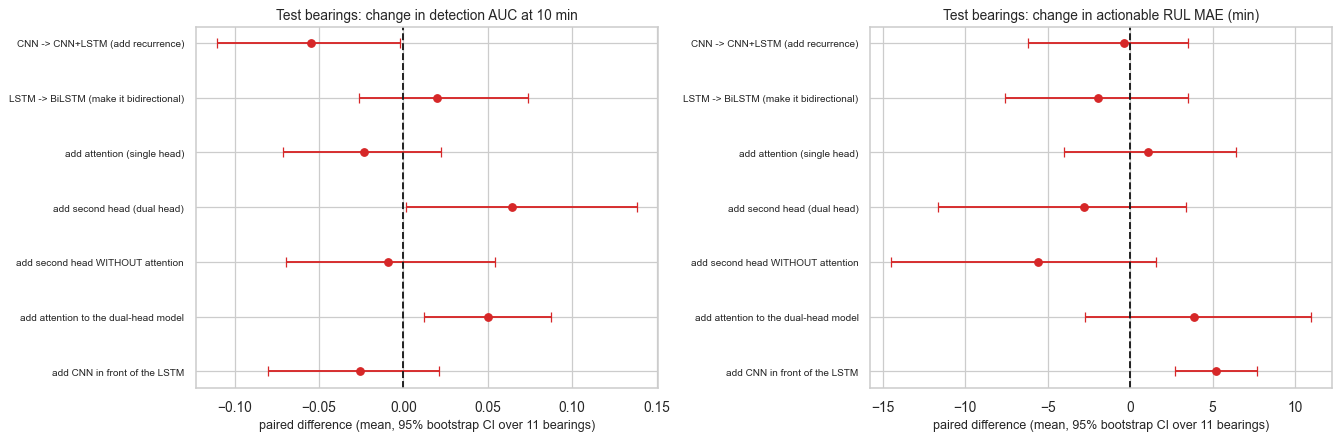

**Figure 29.** Ablation on the unseen test bearings (same steps as Figure 13). Compare with the LOBO ablation: components that were not supported there should not be supported here either.

In [41]:
# ---- ablation on the test bearings (paired over the 11 test bearings; metrics defined on every bearing) ----
def per_bearing_metric(m, seed, kind):
    g_ = pred_test[(pred_test.model == m) & (pred_test.seed == seed)]
    out = []
    for b in C.TEST:
        gb = g_[g_.bearing == b]; act = gb.rul_min.values <= 60
        out.append(np.abs(gb.pred_min - gb.rul_cap_min).values[act].mean() if kind == "mae" else roc_auc_score(gb.rul_min <= 10, -gb.pred_min))
    return np.array(out)
def seed_avg(m, kind): return np.mean([per_bearing_metric(m, s, kind) for s in ([C.SEEDS_FINAL[0]] if m in ("Constant", "Ridge") else C.SEEDS_FINAL)], axis=0)
rows = []
for a_, b_, lab in chain:
    for kind, hib, nm in [("auc", True, "detection AUC at 10 min"), ("mae", False, "actionable RUL MAE (min)")]:
        r = R.paired_difference(seed_avg(a_, kind), seed_avg(b_, kind), a_, b_, higher_is_better=hib); r.update({"step": lab, "metric": nm}); rows.append(r)
abl_t = pd.DataFrame(rows)[["step", "metric", "mean_diff", "ci_lo", "ci_hi", "units_improved", "verdict"]]; display(abl_t.round(3)); abl_t.to_csv(C.ARTIFACTS / "ablation_test.csv", index=False)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for a_, nm in zip(ax, ["detection AUC at 10 min", "actionable RUL MAE (min)"]):
    sub = abl_t[abl_t.metric == nm]; y = np.arange(len(sub)); a_.errorbar(sub.mean_diff, y, xerr=[sub.mean_diff - sub.ci_lo, sub.ci_hi - sub.mean_diff], fmt="o", color="#d62728", capsize=4)
    a_.axvline(0, color="k", ls="--"); a_.set_yticks(y); a_.set_yticklabels(sub.step, fontsize=8); a_.invert_yaxis(); a_.set_title(f"Test bearings: change in {nm}"); a_.set_xlabel("paired difference (mean, 95% bootstrap CI over 11 bearings)")
plt.tight_layout(); R.savefig(fig, "fig_ablation_test.png"); plt.show()
R.show("**Figure 29.** Ablation on the unseen test bearings (same steps as Figure 13). Compare with the LOBO ablation: components that were not supported there should not be supported here either.")

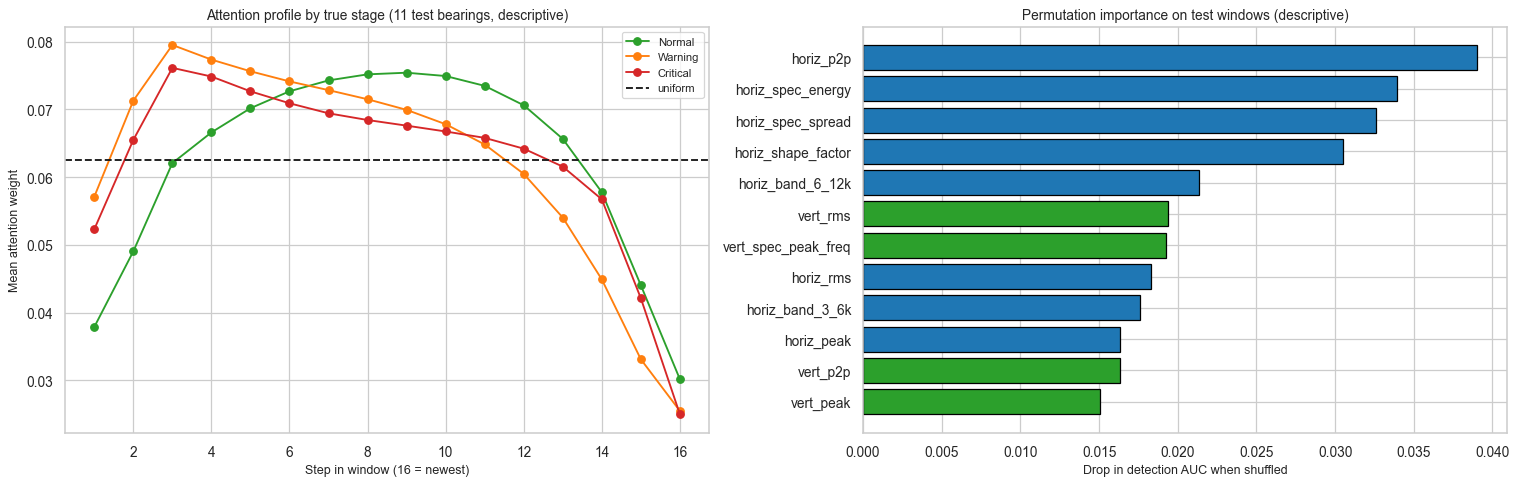

**Figure 30.** Descriptive explainability on the test bearings (no decision uses it). Replacing the learned attention by uniform weights changes predictions by 2.5 min on average (correlation 0.990). Top features on test: `horiz_p2p` (+0.039), `horiz_spec_energy` (+0.034), `horiz_spec_spread` (+0.033), `horiz_shape_factor` (+0.031); overlap of the top-5 with the LOBO top-5: 3/5.

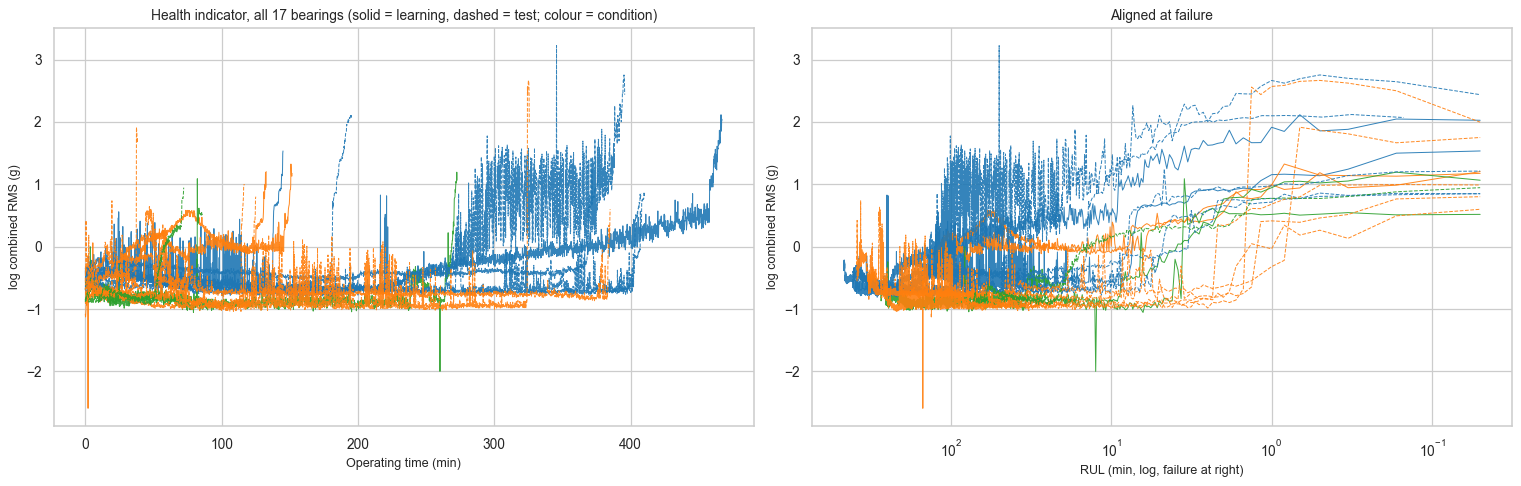

,lifetime_min,phase_min@5%,phase_min@10%,phase_min@20%,AUC_h10 (proposed),AUC_h60 (proposed),"MAE_actionable (proposed, min)"
bearing,,,,,,,
Bearing1_3,395.7,155.2,128.2,112.0,0.99,0.99,17.81
Bearing1_4,195.2,14.8,14.3,14.0,0.99,1.00,13.91
Bearing1_5,410.3,12.0,9.0,8.7,0.91,0.74,58.92
Bearing1_6,407.8,6.2,5.8,5.3,0.96,0.86,23.08
Bearing1_7,376.3,206.3,175.2,9.8,0.90,0.73,35.39
Bearing2_3,325.7,1.5,1.3,1.3,0.65,0.70,85.36
Bearing2_4,125.0,2.3,1.3,1.2,0.44,0.10,84.08
Bearing2_5,385.0,1.7,1.7,1.7,0.84,0.96,58.77
Bearing2_6,116.7,3.7,2.2,2.2,0.88,0.99,16.11


**Figure 31 / table (descriptive, hindsight-based, not used for any decision).** All 17 health indicators; the table lists the visible degradation-phase length of each test bearing and the proposed model's detection quality on it.

In [42]:
# ---- test-set explainability (DESCRIPTIVE, after the freeze; no decision depends on it) ----
net_t = kept_final[("proposed", SEED0)]
attn_m = KModel(net_t.input, net_t.get_layer("temporal_attention").output[1]); A_t = attn_m.predict(Xte_f, batch_size=512, verbose=0)[:, :, 0]
prof = {nm: A_t[mte_f.stage.values == s_].mean(0) for s_, nm in enumerate(["Normal", "Warning", "Critical"])}
u = KL.GlobalAveragePooling1D()(net_t.get_layer("drop_bilstm").output); u = net_t.get_layer("rul_output")(net_t.get_layer("rul_dense")(net_t.get_layer("shared_dense")(u))); uni_t = KModel(net_t.input, u)
y_a = np.clip(net_t.predict(Xte_f, batch_size=512, verbose=0)["rul_output"].ravel(), 0, 1) * C.RUL_CAP_MIN; y_u = np.clip(uni_t.predict(Xte_f, batch_size=512, verbose=0).ravel(), 0, 1) * C.RUL_CAP_MIN
I_t = perm_importance(lambda X: np.clip(net_t.predict(X, batch_size=1024, verbose=0)["rul_output"].ravel(), 0, 1) * C.RUL_CAP_MIN, Xte_f, mte_f)
I_t.to_csv(C.ARTIFACTS / "perm_importance_proposed_test.csv")
fig, ax = plt.subplots(1, 2, figsize=(17, 5.5))
for nm, col in [("Normal", "#2ca02c"), ("Warning", "#ff7f0e"), ("Critical", "#d62728")]: ax[0].plot(np.arange(1, 17), prof[nm], marker="o", color=col, label=nm)
ax[0].axhline(1 / 16, color="k", ls="--", label="uniform"); ax[0].set_xlabel("Step in window (16 = newest)"); ax[0].set_ylabel("Mean attention weight"); ax[0].set_title("Attention profile by true stage (11 test bearings, descriptive)"); ax[0].legend()
t_ = I_t.sort_values("dAUC", ascending=False).head(12).iloc[::-1]; ax[1].barh(t_.index, t_.dAUC, color=["#1f77b4" if i.startswith("horiz") else "#2ca02c" for i in t_.index], edgecolor="black")
ax[1].set_xlabel("Drop in detection AUC when shuffled"); ax[1].set_title("Permutation importance on test windows (descriptive)")
plt.tight_layout(); R.savefig(fig, "fig_explainability_test.png"); plt.show()
R.show(f"**Figure 30.** Descriptive explainability on the test bearings (no decision uses it). Replacing the learned attention by uniform weights changes predictions by {np.abs(y_a - y_u).mean():.1f} min on average (correlation {np.corrcoef(y_a, y_u)[0,1]:.3f}). "
       f"Top features on test: " + ", ".join(f"`{i}` ({v:+.3f})" for i, v in I_t.dAUC.sort_values(ascending=False).head(4).items()) + f"; overlap of the top-5 with the LOBO top-5: {len(set(I_t.dAUC.nlargest(5).index) & set(I_nn.dAUC.nlargest(5).index))}/5.")

# ---- descriptive: health indicator of ALL 17 bearings, shown only now (after the freeze) ----
allb = table.copy(); allb["hi"] = np.nan
for b in C.LEARNING + C.TEST:
    m = allb.bearing == b; allb.loc[m, "hi"] = A.combined_rms_hi(allb[m])
fig, ax = plt.subplots(1, 2, figsize=(17, 5.5))
for b in C.LEARNING + C.TEST:
    g_ = allb[allb.bearing == b]; ax[0].plot(g_.time_min, g_.hi, lw=0.8, color=COND_COLOR[C.condition_of(b)], alpha=0.9, ls="-" if b in C.LEARNING else "--"); ax[1].plot(np.maximum(g_.rul_min, 0.05), g_.hi, lw=0.8, color=COND_COLOR[C.condition_of(b)], alpha=0.9, ls="-" if b in C.LEARNING else "--")
ax[0].set_xlabel("Operating time (min)"); ax[0].set_ylabel("log combined RMS (g)"); ax[0].set_title("Health indicator, all 17 bearings (solid = learning, dashed = test; colour = condition)")
ax[1].set_xscale("log"); ax[1].invert_xaxis(); ax[1].set_xlabel("RUL (min, log, failure at right)"); ax[1].set_ylabel("log combined RMS (g)"); ax[1].set_title("Aligned at failure")
plt.tight_layout(); R.savefig(fig, "fig_health_indicator_all17.png"); plt.show()
ph_test = A.phase_table(table, C.TEST); ph_test["AUC_h10 (proposed)"] = pb_test.AUC_h10; ph_test["AUC_h60 (proposed)"] = pb_test.AUC_h60; ph_test["MAE_actionable (proposed, min)"] = pb_test.MAE_min_actionable
display(ph_test.round(2)); ph_test.to_csv(C.ARTIFACTS / "test_phase_lengths_descriptive.csv")
R.show("**Figure 31 / table (descriptive, hindsight-based, not used for any decision).** All 17 health indicators; the table lists the visible degradation-phase length of each test bearing and the proposed model's detection quality on it.")

### 22.1 What did we find on the unseen test bearings?

In [43]:
mt = sm_test.groupby("model").mean(numeric_only=True)
sd_t = sm_test.groupby("model").std(numeric_only=True)
ct = mt.loc["Constant"]
b_prop = mt.loc["proposed"]
cand_t = mt.drop(index="Constant")
def tied(col, lower, tol):
    """Models whose mean is within max(tol, seed std of the best model) of the best one: statistically indistinguishable here."""
    best_m = cand_t[col].idxmin() if lower else cand_t[col].idxmax()
    band = max(tol, float(sd_t.loc[best_m, col]) if not np.isnan(sd_t.loc[best_m, col]) else 0.0)
    ok = [m for m in cand_t.index if (cand_t.loc[m, col] - cand_t.loc[best_m, col]) * (1 if lower else -1) <= band]
    return best_m, ok, band
best_det_test, tie_det, band_det = tied("AUC_mean_h", False, 0.02)
best_mae_test, tie_mae, band_mae = tied("MAE_min_actionable", True, 2.0)
rk = cand_t.AUC_mean_h.rank(ascending=False); rk_mae = cand_t.MAE_min_actionable.rank(ascending=True)
lobo_rank = mmean.drop(index="Constant").AUC_mean_h.rank(ascending=False); rho_rank = spearmanr(lobo_rank.loc[rk.index], rk)[0]
lobo_rank_m = mmean.drop(index="Constant").MAE_min_actionable.rank(ascending=True); rho_rank_m = spearmanr(lobo_rank_m.loc[rk_mae.index], rk_mae)[0]
R.show("\n\n".join([
    f"**Detection (mean AUC over horizons 5-60 min; constant = 0.50):** proposed **{b_prop.AUC_mean_h:.3f}** (seed std {sd_t.loc['proposed','AUC_mean_h']:.3f}); highest mean on test: {E.LABEL[best_det_test]} ({mt.loc[best_det_test].AUC_mean_h:.3f}). "
    f"Models within {band_det:.3f} of the best are **statistically indistinguishable** here (seed noise): " + ", ".join(E.LABEL[m] for m in tie_det) + ". "
    f"The LOBO-selected detection model was **{E.LABEL[sel['best_detection_AUC_mean_h']]}**; it ranks #{int(rk[sel['best_detection_AUC_mean_h']])} of 10 on test. Rank correlation LOBO vs test (10 models): {rho_rank:.2f}.",
    f"**RUL in the actionable region (constant {ct.MAE_min_actionable:.1f} min):** proposed {b_prop.MAE_min_actionable:.1f} min; lowest on test {E.LABEL[best_mae_test]} ({mt.loc[best_mae_test].MAE_min_actionable:.1f} min); tied within {band_mae:.1f} min: " + ", ".join(E.LABEL[m] for m in tie_mae) +
    f". The LOBO-selected RUL model was **{E.LABEL[sel['best_actionable_RUL_MAE']]}**; it ranks #{int(rk_mae[sel['best_actionable_RUL_MAE']])} of 10 on test (rank correlation LOBO vs test {rho_rank_m:.2f}). **Overall MAE** (constant {ct.MAE_min:.1f} min): proposed {b_prop.MAE_min:.1f} min.",
    f"**Official PHM-2012 score** (one prediction per bearing at the truncation point; higher = better, 1 = perfect): proposed {b_prop.PHM_official:.3f}, constant {ct.PHM_official:.3f}, Random Forest {mt.loc['Random Forest'].PHM_official:.3f}. With only 11 predictions and a capped predictor this score is very noisy; the per-bearing table shows that at the truncation points of the abrupt bearings the model still predicts a healthy bearing (RUL > 100 min), which is punished as a very late prediction.",
    f"**False alarms** on truly Normal windows: proposed {b_prop.false_alarm_rate:.2f}, Random Forest {mt.loc['Random Forest'].false_alarm_rate:.2f}, Gradient Boosting {mt.loc['Gradient Boosting'].false_alarm_rate:.2f} (uniform rule). **Stage macro-F1:** proposed {b_prop.stage_macroF1:.2f} (uniform rule), constant {ct.stage_macroF1:.2f}.",
    ("**Consistency of validation and test.** The rank correlations between LOBO and test are " + f"{rho_rank:.2f} (detection) and {rho_rank_m:.2f} (actionable RUL error): " +
     ("the validation ranking is only weakly or not at all reproduced on the test bearings, so six learning bearings give an **unstable model ranking**; differences between the top models must not be over-interpreted." if min(rho_rank, rho_rank_m) < 0.7
      else "the validation ranking is largely reproduced on the test bearings."))]))

**Detection (mean AUC over horizons 5-60 min; constant = 0.50):** proposed **0.749** (seed std 0.017); highest mean on test: PROPOSED: CNN + BiLSTM + Attention (dual head) (0.749). Models within 0.020 of the best are **statistically indistinguishable** here (seed noise): CNN, CNN + BiLSTM (dual head, no attention), PROPOSED: CNN + BiLSTM + Attention (dual head). The LOBO-selected detection model was **LSTM**; it ranks #4 of 10 on test. Rank correlation LOBO vs test (10 models): 0.47.

**RUL in the actionable region (constant 56.4 min):** proposed 38.1 min; lowest on test Gradient Boosting (32.7 min); tied within 2.0 min: Gradient Boosting, Random Forest, CNN + BiLSTM (dual head, no attention). The LOBO-selected RUL model was **CNN + BiLSTM + Attention (single head)**; it ranks #7 of 10 on test (rank correlation LOBO vs test -0.52). **Overall MAE** (constant 35.6 min): proposed 29.6 min.

**Official PHM-2012 score** (one prediction per bearing at the truncation point; higher = better, 1 = perfect): proposed 0.146, constant 0.124, Random Forest 0.078. With only 11 predictions and a capped predictor this score is very noisy; the per-bearing table shows that at the truncation points of the abrupt bearings the model still predicts a healthy bearing (RUL > 100 min), which is punished as a very late prediction.

**False alarms** on truly Normal windows: proposed 0.17, Random Forest 0.30, Gradient Boosting 0.24 (uniform rule). **Stage macro-F1:** proposed 0.47 (uniform rule), constant 0.29.

**Consistency of validation and test.** The rank correlations between LOBO and test are 0.47 (detection) and -0.52 (actionable RUL error): the validation ranking is only weakly or not at all reproduced on the test bearings, so six learning bearings give an **unstable model ranking**; differences between the top models must not be over-interpreted.

### 22.2 What does this mean, and does it support the hypotheses?
The numbers above are the **final, one-shot** test result. Compare them with the LOBO estimates: consistent ranking between validation and test increases confidence that the conclusions are not artefacts of the six learning bearings; disagreement means the estimates are unstable. Bearing-to-bearing variability (per-bearing table and phase-length table) is large, and the models detect impending failure well only for bearings with a visible degradation phase. **H1, H2 and H3 are judged in Section 26 from these measurements, not assumed.**

## 23. Sample Prediction Demonstration (for the review)

**WHAT** – pick a test bearing and a time; the demo takes **only the data available up to that time** (asserted), rebuilds the 16-snapshot window from the raw table, loads the **saved model and scaler from disk**, and shows the predicted RUL, stage probabilities, the true values for comparison, the health indicator and the raw waveform.
**HOW TO USE.** Change `DEMO_BEARING` and `DEMO_TIME_MIN` in the next cell and run it. `DEMO_TIME_MIN=None` uses the moment when the true RUL is 30 minutes.
**DEFAULT CHOICE.** The default bearing is the test bearing whose proposed-model actionable-region error is the **median** of the 11 (so the demonstration is neither the best nor the worst case). This choice was made *after* the test result, for demonstration only, and is disclosed here.

### Sample prediction - Bearing1_7 (condition 1: 1800 rpm, 4000 N)
* **Input sample:** window of 16 snapshots covering 343.8-346.3 min of operation (snapshot 2078); the model sees nothing after 346.3 min.
* **Predicted RUL (capped at 120 min):** **56.0 min**   |   **true RUL:** 30.0 min (capped 30.0)   |   error +26.0 min
* **Predicted stage (stage head):** **Critical (<= 20 min)** (probabilities N/W/C = 0.37/0.03/0.60)   |   from predicted RUL: Warning (20-60 min)   |   **true stage:** Warning (20-60 min)
* **Health indicator (log combined RMS):** -0.39  (median of this bearing's first 10 snapshots: -0.47)

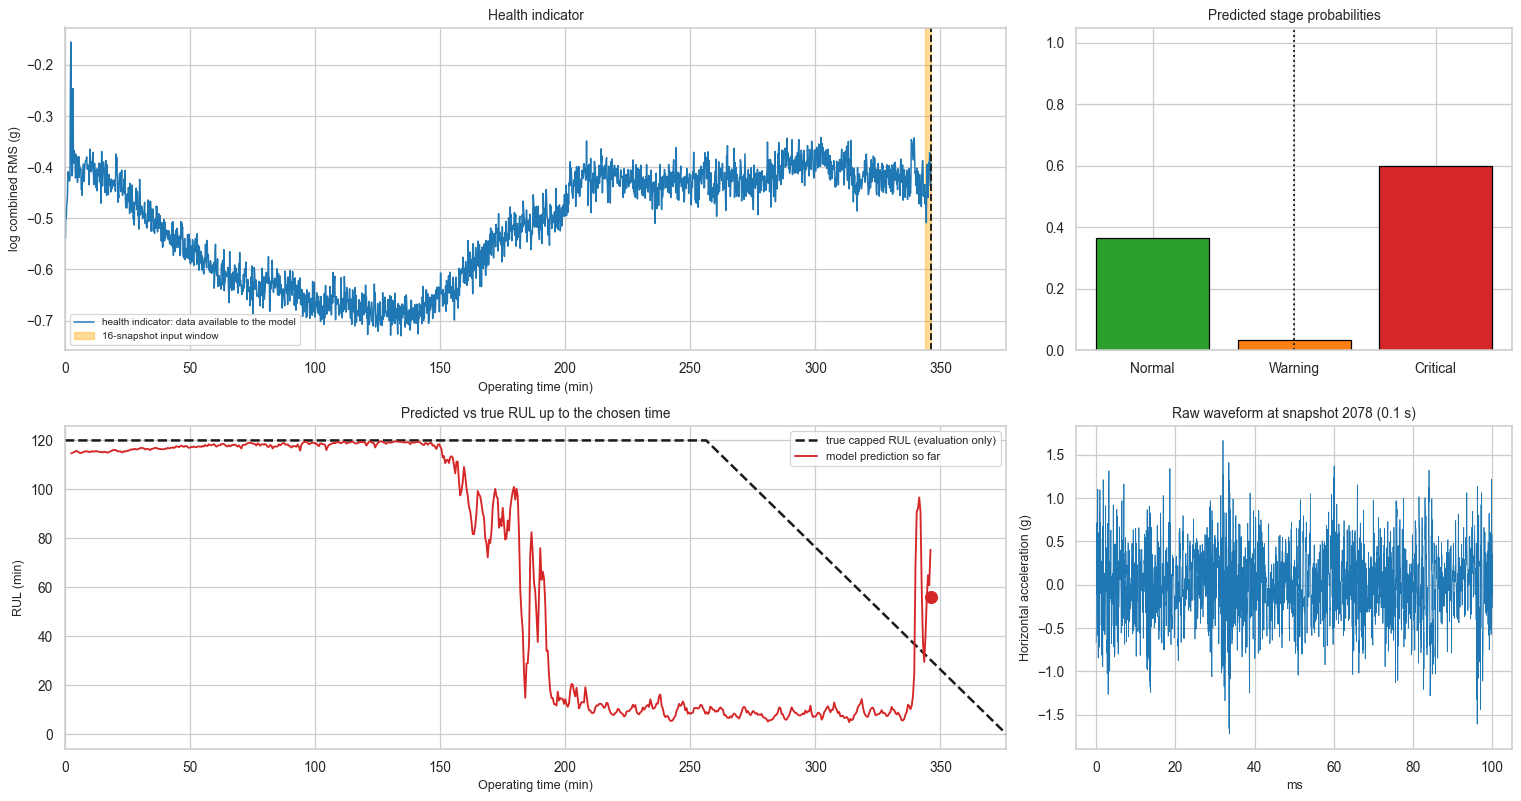

In [44]:
# ------------------ EDIT THESE TWO LINES TO DEMONSTRATE ANOTHER BEARING / TIME ------------------
med_b = pb_test.MAE_min_actionable.sort_values().index[len(pb_test) // 2]
DEMO_BEARING = med_b            # any of C.TEST, e.g. "Bearing1_3"
DEMO_TIME_MIN = None            # operating time in minutes since start; None -> 30 minutes before failure
# --------------------------------------------------------------------------------------------------
scaler_disk = joblib.load(C.ARTIFACTS / "final_scaler.pkl")
model_disk = tf.keras.models.load_model(C.ARTIFACTS / "final_proposed_model.keras")
cfg_disk = json.load(open(C.ARTIFACTS / "final_feature_config.json"))
STAGES = ["Normal (RUL > 60 min)", "Warning (20-60 min)", "Critical (<= 20 min)"]

def predict_sample(bearing, t_min=None):
    tb = table[table.bearing == bearing].sort_values("snapshot_idx")
    if t_min is None:
        t_min = float(tb.time_min[tb.rul_min <= 30].iloc[0])
    k = int(np.argmin(np.abs(tb.time_min.values - t_min)))
    assert k >= C.WINDOW - 1, "need at least 16 snapshots of history"
    past = tb.iloc[: k + 1]                                   # ONLY data up to the chosen time
    x = scaler_disk.transform(feats.loc[past.index].values)[-C.WINDOW:][None].astype("float32")
    out = model_disk.predict(x, verbose=0)
    pred = float(np.clip(out["rul_output"][0, 0], 0, 1) * cfg_disk["rul_cap_min"]); prob = out["risk_output"][0]
    row = tb.iloc[k]
    return dict(bearing=bearing, snapshot=int(row.snapshot_idx), t_min=float(row.time_min), window=(float(tb.iloc[k - C.WINDOW + 1].time_min), float(row.time_min)), pred_rul=pred, prob=prob,
                stage_native=int(prob.argmax()), stage_uniform=int(D.stage_from_rul_min([pred])[0]), true_rul=float(row.rul_min), true_capped=float(row.rul_cap_min), true_stage=int(row.stage),
                past=past, features_now=feats.loc[past.index[-1]])

def demo(bearing, t_min=None):
    r = predict_sample(bearing, t_min); tb = table[table.bearing == bearing].sort_values("snapshot_idx"); past = r["past"]
    R.show(f"### Sample prediction - {bearing} (condition {C.condition_of(bearing)}: {C.CONDITION[C.condition_of(bearing)][0]} rpm, {C.CONDITION[C.condition_of(bearing)][1]} N)\n"
           f"* **Input sample:** window of 16 snapshots covering {r['window'][0]:.1f}-{r['window'][1]:.1f} min of operation (snapshot {r['snapshot']}); the model sees nothing after {r['t_min']:.1f} min.\n"
           f"* **Predicted RUL (capped at 120 min):** **{r['pred_rul']:.1f} min**   |   **true RUL:** {r['true_rul']:.1f} min (capped {r['true_capped']:.1f})   |   error {r['pred_rul'] - r['true_capped']:+.1f} min\n"
           f"* **Predicted stage (stage head):** **{STAGES[r['stage_native']]}** (probabilities N/W/C = {r['prob'][0]:.2f}/{r['prob'][1]:.2f}/{r['prob'][2]:.2f})   |   from predicted RUL: {STAGES[r['stage_uniform']]}   |   **true stage:** {STAGES[r['true_stage']]}\n"
           f"* **Health indicator (log combined RMS):** {A.combined_rms_hi(past.iloc[[-1]])[0]:.2f}  (median of this bearing's first 10 snapshots: {np.median(A.combined_rms_hi(past.iloc[:10])):.2f})")
    fig = plt.figure(figsize=(17, 9)); gs = fig.add_gridspec(2, 3)
    a0 = fig.add_subplot(gs[0, :2])
    a0.plot(past.time_min, A.combined_rms_hi(past), color="#1f77b4", lw=1.2, label="health indicator: data available to the model"); a0.set_xlim(0, tb.time_min.max()); a0.axvspan(r["window"][0], r["window"][1], color="orange", alpha=0.4, label="16-snapshot input window"); a0.axvline(r["t_min"], color="k", ls="--")
    a0.set_xlabel("Operating time (min)"); a0.set_ylabel("log combined RMS (g)"); a0.set_title("Health indicator"); a0.legend(fontsize=8)
    a1 = fig.add_subplot(gs[0, 2]); a1.bar(["Normal", "Warning", "Critical"], r["prob"], color=["#2ca02c", "#ff7f0e", "#d62728"], edgecolor="black"); a1.set_ylim(0, 1.05); a1.set_title("Predicted stage probabilities"); a1.axvline(r["true_stage"], color="k", ls=":")
    a2 = fig.add_subplot(gs[1, :2]); ks = np.arange(C.WINDOW - 1, len(past), 3); xs = scaler_disk.transform(feats.loc[past.index].values).astype("float32"); Wn = np.stack([xs[i - C.WINDOW + 1:i + 1] for i in ks])
    traj = np.clip(model_disk.predict(Wn, verbose=0)["rul_output"].ravel(), 0, 1) * C.RUL_CAP_MIN
    a2.plot(tb.time_min, tb.rul_cap_min, "k--", lw=2, label="true capped RUL (evaluation only)"); a2.set_xlim(0, tb.time_min.max()); a2.plot(past.time_min.values[ks], traj, color="#d62728", lw=1.5, label="model prediction so far"); a2.scatter([r["t_min"]], [r["pred_rul"]], s=90, color="#d62728", zorder=5)
    a2.set_xlabel("Operating time (min)"); a2.set_ylabel("RUL (min)"); a2.set_title("Predicted vs true RUL up to the chosen time"); a2.legend()
    a3 = fig.add_subplot(gs[1, 2]); sub = "Learning_set" if bearing in C.LEARNING else "Full_Test_Set"; arr_, _ = F.read_snapshot(C.DATASET / sub / bearing / f"acc_{r['snapshot']+1:05d}.csv")
    a3.plot(np.arange(len(arr_)) / C.FS * 1000, arr_[:, 4], lw=0.6, color="#1f77b4"); a3.set_xlabel("ms"); a3.set_ylabel("Horizontal acceleration (g)"); a3.set_title(f"Raw waveform at snapshot {r['snapshot']} (0.1 s)")
    plt.tight_layout(); R.savefig(fig, f"fig_sample_prediction_{bearing}_t{int(round(r['t_min']))}min.png"); plt.show(); return r

r_demo = demo(DEMO_BEARING, DEMO_TIME_MIN)

### Sample prediction - Bearing1_7 (condition 1: 1800 rpm, 4000 N)
* **Input sample:** window of 16 snapshots covering 91.5-94.0 min of operation (snapshot 564); the model sees nothing after 94.0 min.
* **Predicted RUL (capped at 120 min):** **115.8 min**   |   **true RUL:** 282.3 min (capped 120.0)   |   error -4.2 min
* **Predicted stage (stage head):** **Normal (RUL > 60 min)** (probabilities N/W/C = 1.00/0.00/0.00)   |   from predicted RUL: Normal (RUL > 60 min)   |   **true stage:** Normal (RUL > 60 min)
* **Health indicator (log combined RMS):** -0.62  (median of this bearing's first 10 snapshots: -0.47)

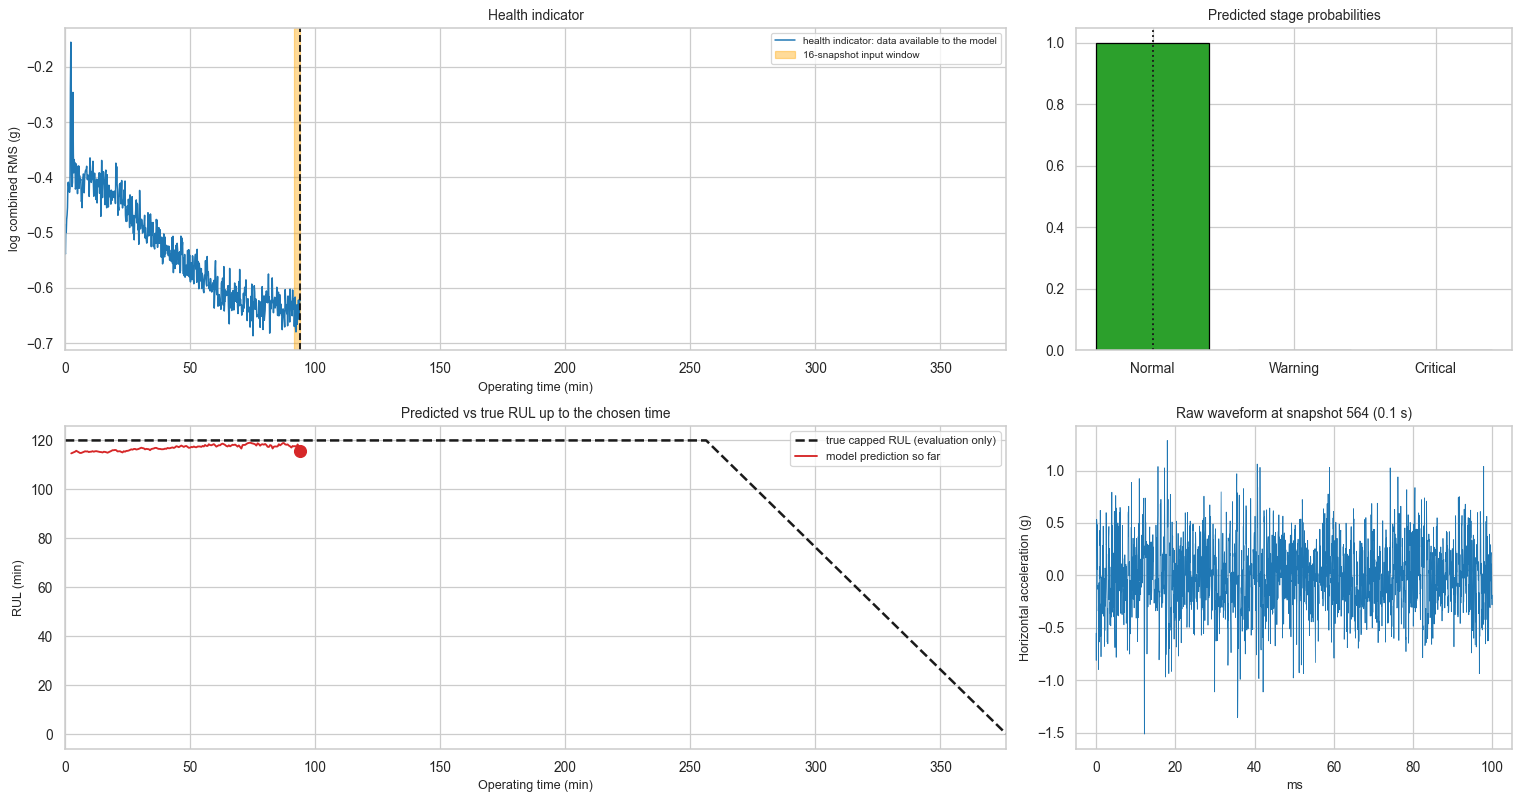

In [45]:
# a second, healthy-phase example for the same bearing (t = 25% of life) to show a "Normal" case
_ = demo(DEMO_BEARING, float(table[table.bearing == DEMO_BEARING].time_min.max() * 0.25))

### 23.1 What did we find?
The demonstration shows the complete deployment path on a bearing the model never saw: causal window → saved scaler → saved network → RUL and stage. Use it in the review to explain the prediction *and its uncertainty*: compare predicted with true RUL and note the stage probabilities. The first example is 30 minutes before failure; the second is a healthy phase.

## 24. Results Summary and Model Selection

**WHAT** – one objective comparison across the dimensions that matter (accuracy, generalisation, cost, interpretability, stability, false alarms, RUL performance, detection, size). **A model is called best only for the criterion where the numbers say so.**

In [46]:
rows = []
for m in E.ALL_MODELS:
    l = fold_mean.xs(m, level="model"); t_ = sm_test[sm_test.model == m]
    rows.append({"model": E.LABEL[m], "detection AUC LOBO": l.AUC_mean_h.mean(), "detection AUC test": t_.AUC_mean_h.mean(), "actionable MAE LOBO (min)": l.MAE_min_actionable.mean(), "actionable MAE test (min)": t_.MAE_min_actionable.mean(),
                 "overall MAE test (min)": t_.MAE_min.mean(), "false-alarm rate test": t_.false_alarm_rate.mean(), "PHM-2012 score test": t_.PHM_official.mean(),
                 "stability: std of test AUC over seeds": t_.AUC_mean_h.std(), "stability: std of LOBO AUC over folds": l.AUC_mean_h.std(),
                 "generalisation gap AUC (LOBO - test)": l.AUC_mean_h.mean() - t_.AUC_mean_h.mean(), "parameters": n_params.get(m, np.nan),
                 "fit+predict s (LOBO median)": ep_lobo[ep_lobo.model == m].fit_predict_s.median(),
                 "interpretability": {"Constant": "trivial", "Ridge": "coefficients", "Random Forest": "importances", "Gradient Boosting": "importances"}.get(m, "attention + permutation" if m == "proposed" else "black box")})
crit = pd.DataFrame(rows).set_index("model"); display(crit.round(3)); crit.to_csv(C.ARTIFACTS / "final_multicriteria_comparison.csv")
pick = lambda col, lower: (crit.drop(index="Constant")[col].idxmin() if lower else crit.drop(index="Constant")[col].idxmax())
purposes = pd.DataFrame({"purpose": ["best detection of imminent failure (test AUC)", "lowest actionable RUL error (test)", "lowest false-alarm rate (test)", "most stable across seeds (test AUC std)", "cheapest to train", "richest built-in explanation"],
                         "model with the best mean": [pick("detection AUC test", False), pick("actionable MAE test (min)", True), pick("false-alarm rate test", True), pick("stability: std of test AUC over seeds", True),
                                                      crit.drop(index="Constant")["fit+predict s (LOBO median)"].idxmin(), "PROPOSED: CNN + BiLSTM + Attention (dual head)"],
                         "statistically tied with it": [", ".join(E.LABEL[m] for m in tie_det), ", ".join(E.LABEL[m] for m in tie_mae), "see table (no seed-noise band computed)", "-", "-", "design property, not a measurement"]})
display(purposes)
R.show("**Selection rule reminder.** The recommendation for detection and RUL was fixed on **LOBO** results (Section 17) and saved *before* the test; the test columns here confirm or contradict it. 'Richest built-in explanation' is a design property of the proposed model, not a performance claim.")

,detection AUC LOBO,detection AUC test,actionable MAE LOBO (min),actionable MAE test (min),overall MAE test (min),false-alarm rate test,PHM-2012 score test,stability: std of test AUC over seeds,stability: std of LOBO AUC over folds,generalisation gap AUC (LOBO - test),parameters,fit+predict s (LOBO median),interpretability
model,,,,,,,,,,,,,
Constant,0.500,0.500,53.373,56.354,35.623,0.000,0.124,NaN,0.000,0.000,NaN,0.010,trivial
Ridge,0.615,0.640,31.076,45.216,39.066,0.198,0.040,NaN,0.198,-0.025,NaN,0.407,coefficients
Random Forest,0.717,0.696,38.902,32.713,32.640,0.296,0.078,0.002,0.159,0.022,NaN,13.371,importances
Gradient Boosting,0.725,0.725,39.680,32.651,30.146,0.237,0.037,0.000,0.091,0.000,NaN,4.315,importances
CNN,0.803,0.732,28.946,42.575,27.806,0.146,0.181,0.032,0.172,0.071,25729.0,7.662,black box
LSTM,0.886,0.728,27.978,36.779,32.324,0.208,0.143,0.011,0.104,0.159,31617.0,8.162,black box
CNN + LSTM,0.852,0.715,24.150,42.055,30.610,0.182,0.221,0.009,0.128,0.137,58753.0,17.088,black box
CNN + BiLSTM,0.873,0.725,28.407,40.092,34.205,0.225,0.106,0.055,0.116,0.148,95873.0,19.830,black box
CNN + BiLSTM + Attention (single head),0.830,0.715,23.340,41.184,32.336,0.202,0.179,0.034,0.149,0.115,112513.0,28.628,black box


,purpose,model with the best mean,statistically tied with it
0,best detection of imminent failure (test AUC),PROPOSED: CNN + BiLSTM + Attention (dual head),"CNN, CNN + BiLSTM (dual head, no attention), PROPOSED: CNN + BiLSTM + Attention (dual head)"
1,lowest actionable RUL error (test),Gradient Boosting,"Gradient Boosting, Random Forest, CNN + BiLSTM (dual head, no attention)"
2,lowest false-alarm rate (test),CNN,see table (no seed-noise band computed)
3,most stable across seeds (test AUC std),Gradient Boosting,-
4,cheapest to train,Ridge,-
5,richest built-in explanation,PROPOSED: CNN + BiLSTM + Attention (dual head),"design property, not a measurement"


**Selection rule reminder.** The recommendation for detection and RUL was fixed on **LOBO** results (Section 17) and saved *before* the test; the test columns here confirm or contradict it. 'Richest built-in explanation' is a design property of the proposed model, not a performance claim.

## 25. Limitations

* **Very few independent bearings.** 6 learning bearings (3 conditions; Condition 3 has 2) and 11 test bearings. Every conclusion has wide uncertainty; LOBO has only six folds and bootstrap intervals over six units are wide.
* **Different operating conditions and heterogeneous degradation.** Conditions were not separate in training; degradation patterns differ strongly between bearings [1], [2].
* **Abrupt failures.** For several bearings the vibration is almost healthy until the last minutes. No model can give a long warning there (Figure 8, phase-length tables). This is a property of the data.
* **Label uncertainty.** End of life comes from recording durations and the official RUL table. The 20 g criterion is not visible in every snapshot (only 0.1 s per 10 s is recorded), and Bearing1_4 in `Full_Test_Set` extends beyond its official end of life. Bearing2_1/2_2 may contain early level shifts that are not damage.
* **Design choices.** The cap (120 min) and stage boundaries (20/60 min) were chosen a priori for operational meaning; conclusions were checked for cap sensitivity but the horizons still define what "success" means.
* **Hindsight in offline analysis.** Training uses the failure time of the learning bearings. Descriptive onset/phase-length tables use whole trajectories and are not real-time detectors.
* **Prior exposure to the test bearings.** In earlier experiments (v1/v2) I inspected test-bearing health-indicator curves and results. The final target does not use any vibration-derived label, and all design decisions here were made on learning bearings, but the choice of formulation was motivated by earlier findings. This cannot be undone.
* **Detection is not RUL estimation.** Good AUC at short horizons shows that *imminent failure can be recognised*; it does not show accurate minute-level RUL prediction, which the results do not support.
* **RUL metric.** MAE over all windows is dominated by the healthy phase; the actionable-region MAE is more informative but is computed only on windows within 60 minutes of failure. The official PHM score uses one prediction per bearing and a capped predictor (cannot exceed 120 min), so it is noisy and not comparable with challenge leaderboards.
* **Attention.** Attention weights are not causal explanations [9]; Section 20 tests their functional role.
* **Small models, limited tuning.** No hyper-parameter search was performed (deliberately, to avoid over-fitting six bearings); better settings may exist. Window length (16) was not varied.
* **Computational cost.** Deterministic TensorFlow on CPU: the full notebook takes about an hour; the network is small (~100 k parameters) and inference is fast.
* **Dataset specificity.** One test rig, one bearing type, three conditions: results may not transfer to other machines.

## 26. Conclusions

In [47]:
# Hypothesis verdicts computed from the measurements (no verdict is typed by hand)
# ---- H1: family comparison using LOBO-SELECTED representatives (nothing is selected on the test bearings) ----
rep_nn = max(M.NN_KINDS, key=lambda m: mmean.loc[m, "AUC_mean_h"]); rep_tab = max([m for m in M.CLASSICAL if m != "Constant"], key=lambda m: mmean.loc[m, "AUC_mean_h"])
h1_l = R.paired_difference(fold_mean.xs(rep_tab, level="model").AUC_mean_h.values, fold_mean.xs(rep_nn, level="model").AUC_mean_h.values, rep_tab, rep_nn, higher_is_better=True)
h1_t = R.paired_difference(seed_avg(rep_tab, "auc"), seed_avg(rep_nn, "auc"), rep_tab, rep_nn, higher_is_better=True)
n_ok = int(h1_l["verdict"] == "measurable improvement") + int(h1_t["verdict"] == "measurable improvement")
h1_label = {2: "SUPPORTED", 1: "PARTLY SUPPORTED", 0: "NOT SUPPORTED"}[n_ok]

# ---- H2: every ablation contrast that adds the component, LOBO (AUC, actionable MAE) and test (AUC@10, actionable MAE) ----
def collect(steps):
    v = []
    for s in steps:
        v += list(abl[(abl.step == s) & abl.metric.isin(["detection AUC (mean over horizons)", "actionable RUL MAE (min)"])].verdict)
        v += list(abl_t[abl_t.step == s].verdict)
    return v
def status(v):
    imp = sum(x == "measurable improvement" for x in v); deg = sum(x == "measurable degradation" for x in v); no = len(v) - imp - deg
    lab = "SUPPORTED" if (imp >= 0.5 * len(v) and deg == 0) else ("NOT SUPPORTED" if imp == 0 else "MIXED")
    return lab, imp, deg, no
att_lab, ai, ad, an = status(collect(["add attention (single head)", "add attention to the dual-head model"]))
dual_lab, di, dd, dn = status(collect(["add second head (dual head)", "add second head WITHOUT attention"]))

# ---- H3: a USEFUL warning = alarm still active at the end AND sustained lead >= 10 min, per test bearing (proposed, seed 42, uniform rule) ----
abrupt = (ph_test["phase_min@10%"] < 20).values
useful = ((pb_test.alarm_at_end_bearings == 1) & (pb_test.lead_sustained_min_median >= 10)).values
n_useful = int(useful.sum()); n_grad_useful = int(useful[~abrupt].sum()); n_abrupt_useful = int(useful[abrupt].sum())
h3_label = "SUPPORTED" if n_useful == 11 else "NOT SUPPORTED"
R.show("\n\n".join([
    f"* **H1 - sequence models detect impending failure better than tabular baselines: {h1_label}.** Representatives chosen on LOBO: {E.LABEL[rep_nn]} vs {E.LABEL[rep_tab]}. LOBO (6 folds): mean difference in AUC {h1_l['mean_diff']:+.3f} (95% CI {h1_l['ci_lo']:+.3f} to {h1_l['ci_hi']:+.3f}; {h1_l['verdict']}); test (11 bearings, AUC at 10 min): {h1_t['mean_diff']:+.3f} (CI {h1_t['ci_lo']:+.3f} to {h1_t['ci_hi']:+.3f}; {h1_t['verdict']}).",
    f"* **H2 - attention and the dual head improve accuracy.** Attention: **{att_lab}** ({ai} improvements, {ad} degradations, {an} no difference among the ablation contrasts on LOBO and test). Dual head: **{dual_lab}** ({di} improvements, {dd} degradations, {dn} no difference). *MIXED* means the effect changes sign or significance between metrics or between validation and test, i.e. no robust claim can be made.",
    f"* **H3 - a useful warning for every bearing: {h3_label}.** A useful warning (alarm active at the end and sustained lead >= 10 min) exists for {n_useful}/11 test bearings ({n_grad_useful}/{int((~abrupt).sum())} with a visible degradation phase >= 20 min, {n_abrupt_useful}/{int(abrupt.sum())} of the abrupt ones), at a false-alarm rate of {pb_test.false_alarm_rate.mean():.2f} on healthy windows (proposed, seed 42, uniform rule).",
    f"* **RQ3/RQ6:** on unseen bearings the proposed model reaches mean detection AUC {mt.loc['proposed'].AUC_mean_h:.2f} (constant 0.50), but minute-level RUL accuracy is limited: actionable-region MAE {mt.loc['proposed'].MAE_min_actionable:.1f} min vs {mt.loc['Constant'].MAE_min_actionable:.1f} min for a constant, and the official PHM score is {mt.loc['proposed'].PHM_official:.3f} vs {mt.loc['Constant'].PHM_official:.3f} for a constant.",
    f"* **RQ4 - is the proposed model the best?** Highest mean detection AUC on test: **{E.LABEL[best_det_test]}**; models statistically tied with it: {', '.join(E.LABEL[m] for m in tie_det)}. Lowest actionable RUL error: **{E.LABEL[best_mae_test]}**; tied: {', '.join(E.LABEL[m] for m in tie_mae)}. "
    f"The proposed model is {'in' if 'proposed' in tie_det else 'not in'} the detection tie group and {'in' if 'proposed' in tie_mae else 'not in'} the RUL tie group. Its distinctive property is the combination of an alarm head with inspectable attention/feature analysis (functional value measured in Section 20); it is **not** shown to be more accurate than the simplest competitive baselines.",
    "* **RQ5:** the model is *inspectable* (attention, permutation importance), but attention is not a causal explanation and appears only weakly functional (Section 20)."]))

* **H1 - sequence models detect impending failure better than tabular baselines: PARTLY SUPPORTED.** Representatives chosen on LOBO: LSTM vs Gradient Boosting. LOBO (6 folds): mean difference in AUC +0.162 (95% CI +0.092 to +0.238; measurable improvement); test (11 bearings, AUC at 10 min): +0.048 (CI -0.097 to +0.187; no measurable difference (CI includes 0)).

* **H2 - attention and the dual head improve accuracy.** Attention: **MIXED** (2 improvements, 0 degradations, 6 no difference among the ablation contrasts on LOBO and test). Dual head: **MIXED** (1 improvements, 1 degradations, 6 no difference). *MIXED* means the effect changes sign or significance between metrics or between validation and test, i.e. no robust claim can be made.

* **H3 - a useful warning for every bearing: NOT SUPPORTED.** A useful warning (alarm active at the end and sustained lead >= 10 min) exists for 3/11 test bearings (2/3 with a visible degradation phase >= 20 min, 1/8 of the abrupt ones), at a false-alarm rate of 0.05 on healthy windows (proposed, seed 42, uniform rule).

* **RQ3/RQ6:** on unseen bearings the proposed model reaches mean detection AUC 0.75 (constant 0.50), but minute-level RUL accuracy is limited: actionable-region MAE 38.1 min vs 56.4 min for a constant, and the official PHM score is 0.146 vs 0.124 for a constant.

* **RQ4 - is the proposed model the best?** Highest mean detection AUC on test: **PROPOSED: CNN + BiLSTM + Attention (dual head)**; models statistically tied with it: CNN, CNN + BiLSTM (dual head, no attention), PROPOSED: CNN + BiLSTM + Attention (dual head). Lowest actionable RUL error: **Gradient Boosting**; tied: Gradient Boosting, Random Forest, CNN + BiLSTM (dual head, no attention). The proposed model is in the detection tie group and not in the RUL tie group. Its distinctive property is the combination of an alarm head with inspectable attention/feature analysis (functional value measured in Section 20); it is **not** shown to be more accurate than the simplest competitive baselines.

* **RQ5:** the model is *inspectable* (attention, permutation importance), but attention is not a causal explanation and appears only weakly functional (Section 20).

### 26.1 One-paragraph conclusion (for an IEEE-style paper)
The claims that this project **supports** are limited to: (i) a leakage-controlled bearing-level evaluation protocol on PRONOSTIA with automated checks; (ii) on unseen bearings, vibration-based models recognise an *imminent* failure better than chance but far from perfectly (see the test AUC tables), with large differences between bearings, detectability falling as the horizon grows, and poor performance for bearings that fail abruptly; (iii) the proposed CNN–BiLSTM–Attention dual-head network is compared honestly with simple baselines and ablations, and the tables above state where it is or is not better. The claims that this project does **not** support are: accurate minute-level RUL prediction; a long warning for all bearings; causal explanation by attention; comparability with challenge leaderboards.

## 27. Reproducibility and Saved Artifacts

In [48]:
config_all = {"seeds": {"global": SEED, "lobo": C.SEEDS_LOBO, "final": C.SEEDS_FINAL}, "window": C.WINDOW, "rul_cap_min": C.RUL_CAP_MIN, "stage_bounds_min": [C.STAGE_CRITICAL_MIN, C.STAGE_WARNING_MIN],
              "alarm_persistence": C.ALARM_PERSISTENCE, "optimizer": "Adam", "learning_rate": C.LR, "batch_size": C.BATCH, "max_epochs": C.MAX_EPOCHS, "early_stopping_patience": C.PATIENCE,
              "loss": {"rul": f"Huber(delta={C.HUBER_DELTA})", "stage": "sparse categorical cross-entropy, balanced class weights"}, "loss_weights": C.LOSS_WEIGHTS,
              "epochs_final_by_model": sel["epochs_by_model"], "scaler": "StandardScaler fitted on training bearings only", "features": len(F.FEATURES), "log10_features": F.LOG_FEATURES,
              "tf_deterministic_ops": True, "parameters": {k: int(v) for k, v in n_params.items()}, "versions": VERSIONS,
              "lobo_folds": D.lobo_folds(), "final_train": C.LEARNING, "final_test": C.TEST, "official_rul_s": C.OFFICIAL_RUL_S}
json.dump(config_all, open(C.ARTIFACTS / "experiment_config.json", "w"), indent=1, default=str)
final_metrics = {"lobo": {E.LABEL[m]: {k: float(v) for k, v in fold_mean.xs(m, level="model").mean(numeric_only=True)[metric_cols[:-1] + ["detected_bearings", "alarm_at_end_bearings"]].items()} for m in E.ALL_MODELS},
                 "test": {E.LABEL[m]: {k: float(v) for k, v in sm_test[sm_test.model == m].mean(numeric_only=True)[metric_cols[:-1] + ["detected_bearings", "alarm_at_end_bearings", "PHM_official"]].items()} for m in E.ALL_MODELS}}
json.dump(final_metrics, open(C.ARTIFACTS / "final_metrics.json", "w"), indent=1)

# dataset audit report (generated from the audit table and anomaly list, not typed)
def md_table(df):
    d = df.reset_index(); head = "| " + " | ".join(map(str, d.columns)) + " |\n|" + "---|" * len(d.columns) + "\n"
    return head + "\n".join("| " + " | ".join(str(v) for v in r) + " |" for r in d.values)
(C.PROJECT / "DATASET_AUDIT_REPORT.md").write_text("# Dataset audit report (generated by the notebook)\n\nSource: IEEE PHM 2012 / PRONOSTIA files in the project folder; official facts from the challenge document [2].\n\n" + md_table(audit) +
    "\n\n## Anomalies\n\n" + "\n".join("* " + a.replace("**", "") for a in anom) + "\n", encoding="utf8")

expected = ["features_raw.csv", "dataset_audit_table.csv", "feature_documentation.csv", "feature_names.json", "selection.json", "lobo_predictions.csv", "lobo_metrics_per_fold_seed.csv", "lobo_model_comparison.csv",
            "ablation_lobo.csv", "final_predictions_test.csv", "final_metrics_per_model_seed.csv", "final_model_comparison_test.csv", "final_per_bearing_proposed.csv", "ablation_test.csv",
            "final_multicriteria_comparison.csv", "final_metrics.json", "final_proposed_model.keras", "final_scaler.pkl", "final_feature_config.json", "experiment_config.json"]
missing = [f for f in expected if not (C.ARTIFACTS / f).exists()]; assert not missing, f"missing artifacts: {missing}"
figs = sorted(p.name for p in C.FIGURES.glob("*.png"))
R.show(f"**{len(expected)} artifacts verified in `artifacts/`** and **{len(figs)} figures** in `figures/`. Re-running the notebook top-to-bottom from a clean kernel regenerates everything (features are always re-extracted from the raw files).")
display(pd.DataFrame({"artifact": expected, "size_KB": [round((C.ARTIFACTS / f).stat().st_size / 1024, 1) for f in expected]}).set_index("artifact"))
print(*figs, sep="\n")

**20 artifacts verified in `artifacts/`** and **35 figures** in `figures/`. Re-running the notebook top-to-bottom from a clean kernel regenerates everything (features are always re-extracted from the raw files).

,size_KB
artifact,
features_raw.csv,15787.0
dataset_audit_table.csv,1.8
feature_documentation.csv,1.9
feature_names.json,0.7
selection.json,0.7
lobo_predictions.csv,19473.7
lobo_metrics_per_fold_seed.csv,61.2
lobo_model_comparison.csv,2.0
ablation_lobo.csv,3.3


fig01_dataset_overview.png
fig02_sample_raw_signal.png
fig03_healthy_vs_degraded.png
fig04_health_indicator_learning.png
fig05_feature_vs_life_learning.png
fig06_feature_distributions.png
fig07_feature_correlation.png
fig08_horizon_detectability.png
fig09_split_protocol.png
fig_ablation_lobo.png
fig_ablation_test.png
fig_actual_vs_predicted_lobo.png
fig_actual_vs_predicted_test.png
fig_architecture.png
fig_attention_lobo.png
fig_confusion_lobo.png
fig_confusion_test.png
fig_early_warning_lobo.png
fig_early_warning_test.png
fig_error_distribution_lobo.png
fig_error_distribution_test.png
fig_explainability_test.png
fig_explanation_example_lobo.png
fig_feature_importance_lobo.png
fig_health_indicator_all17.png
fig_model_comparison_lobo.png
fig_per_bearing_lobo.png
fig_per_bearing_test.png
fig_roc_lobo.png
fig_roc_test.png
fig_sample_prediction_Bearing1_7.png
fig_sample_prediction_Bearing1_7_t346min.png
fig_sample_prediction_Bearing1_7_t94min.png
fig_training_curves.png
fig_training_metric

## How to Explain This Project in a Review

In [49]:
pp, cc, rf_ = mt.loc["proposed"], mt.loc["Constant"], mt.loc["Random Forest"]
R.show(f"""
### 1. 30-second explanation
Bearings fail suddenly and unplanned stops are expensive. I use vibration data from real run-to-failure bearings to estimate how much life is left and to give a Normal / Warning / Critical alarm. The main result: on bearings the model has never seen, on average it recognises an *imminent* failure better than chance (AUC {pp.AUC_h10:.2f} at 10 minutes vs 0.50, with large differences between bearings), but the data do not allow reliable long-horizon prediction, especially for bearings that fail abruptly.

### 2. 1-minute explanation
Data: the public PRONOSTIA / IEEE PHM 2012 benchmark, 17 bearings, two accelerometers, 25.6 kHz. Each 0.1 s recording becomes 34 vibration features; the model looks at the last 16 recordings (160 s). A CNN finds local patterns, a BiLSTM follows the trend, attention weights the moments, and two heads output remaining life (capped at 120 min) and a stage. To avoid leakage I split **by bearing**, use leave-one-bearing-out validation on the 6 learning bearings, and score the 11 test bearings once after freezing the design. I compared the model with a constant predictor, Ridge, Random Forest, Gradient Boosting, LSTM, CNN and ablations.

### 3. 2-minute technical explanation
Formulation: multi-task learning with a capped-RUL regression head (Huber loss) and a 3-class stage head (cross-entropy, balanced weights), targets derived only from the failure time (no vibration-based onset label). The end of life follows the official durations; an audit found that `Full_Test_Set` Bearing1_4 extends past its official end of life, which is corrected. Scaler and all statistics are fitted on training bearings; automated leakage checks (poison, truncation, causality, target-shuffle, scaler) must pass. Evaluation: MAE (minutes) overall and in the actionable region, detection AUC at several horizons, stage macro-F1, false-alarm rate, lead time, and the official PHM-2012 score at the truncation points. Ablation with bootstrap intervals over bearings tests each component. Explainability: attention profile plus a uniform-attention functional test, and permutation importance.

### 4. Dataset explanation
17 run-to-failure bearings from the PRONOSTIA platform (FEMTO-ST): 6 learning + 11 test bearings, 3 operating conditions (1800/1650/1500 rpm; 4000/4200/5000 N), 2560 samples per 0.1 s snapshot every 10 s, lifetimes from {audit.lifetime_min.min():.0f} to {audit.lifetime_min.max():.0f} min.

### 5. Problem statement
Given the recent vibration history of a bearing, estimate its remaining useful life and health stage, for bearings never seen during training.

### 6. Why this dataset?
It is the standard public benchmark for bearing prognostics with real run-to-failure data and an official protocol and score [2].

### 7. Why these features?
Amplitude (RMS, peak) shows energy growth, impulsiveness (kurtosis, crest factor) shows early impacts, spectral shape and band energies show resonance excitation; each is documented (Section 9) and screened on learning bearings only (Section 8).

### 8-11. Why CNN, BiLSTM, attention, dual head?
CNN: local patterns/noise smoothing. BiLSTM: trend inside the window. Attention: learned weighting of the 16 steps, giving inspectable weights. Dual head: an alarm level next to the number, and possible regularisation. **Whether each part helps was measured (Sections 18 and 22):** attention *{att_lab}* ({ai} improvements / {ad} degradations / {an} no difference), dual head *{dual_lab}* ({di} / {dd} / {dn}), from paired comparisons on validation and test bearings.

### 12. How was leakage prevented?
Bearing-level splitting; scaler fitted on training bearings only; targets from failure time only; causal windows; automated poison/truncation/target-shuffle tests; test bearings scored once after saving the selection file; random window splitting was shown to inflate results (Section 13).

### 13. How were models compared?
Same windows, targets, folds and metrics for all models; LOBO for selection; one-shot test; paired bootstrap for ablation.

### 14. What do the final results mean?
Detection AUC (mean over horizons) on test: proposed {pp.AUC_mean_h:.2f}, Random Forest {rf_.AUC_mean_h:.2f}, constant 0.50. Actionable-region RUL error: proposed {pp.MAE_min_actionable:.1f} min, constant {cc.MAE_min_actionable:.1f} min. Highest mean on test for detection: {E.LABEL[best_det_test]} (statistically tied: {', '.join(E.LABEL[m] for m in tie_det)}); lowest RUL error: {E.LABEL[best_mae_test]} (tied: {', '.join(E.LABEL[m] for m in tie_mae)}).

### 15. Limitations
Six independent learning bearings; abrupt failures with almost no visible precursor; label uncertainty; hindsight in offline analysis; prior exposure to test curves in earlier experiments; attention is not causal.

### 16. Future work
Train with leave-one-bearing-out over all 17 bearings for the final deployment; vary window length; per-condition models; uncertainty estimates; physically informed features (bearing fault frequencies) despite the mismatch reported in [2]; validation on another bearing dataset.

### 17. Ten likely faculty questions
1. *Why not random train/test split?* Overlapping windows of the same bearing leak; Section 13 shows the inflation.
2. *Is the proposed model the best?* Only where the tables say so (Section 24); simple models can be as good or better.
3. *Why is RUL error large?* Most of a bearing's life looks healthy and remaining time is unpredictable; some bearings fail abruptly (Figure 8).
4. *What does AUC mean here?* Probability that a window closer to failure gets a higher alarm score than a healthier one (0.5 = chance).
5. *Why cap the RUL at 120 minutes?* Beyond that the data carry no information; the cap is a documented design choice with a sensitivity check.
6. *Does attention explain the failure?* No; it shows where the network looked, and we test how much it matters (Section 20).
7. *How do you know there is no leakage?* Automated tests (Section 12) and a one-shot final test after freezing.
8. *Why only 6 training bearings?* That is what the challenge provides; LOBO uses them efficiently; more data is the main way to improve.
9. *What is the official PHM score and how did you do?* Asymmetric percentage-error score at the truncation points; proposed {pp.PHM_official:.3f}, constant {cc.PHM_official:.3f} (noisy with 11 bearings).
10. *What would you do next?* More data / other datasets, per-condition models, uncertainty estimation.
""")


### 1. 30-second explanation
Bearings fail suddenly and unplanned stops are expensive. I use vibration data from real run-to-failure bearings to estimate how much life is left and to give a Normal / Warning / Critical alarm. The main result: on bearings the model has never seen, on average it recognises an *imminent* failure better than chance (AUC 0.76 at 10 minutes vs 0.50, with large differences between bearings), but the data do not allow reliable long-horizon prediction, especially for bearings that fail abruptly.

### 2. 1-minute explanation
Data: the public PRONOSTIA / IEEE PHM 2012 benchmark, 17 bearings, two accelerometers, 25.6 kHz. Each 0.1 s recording becomes 34 vibration features; the model looks at the last 16 recordings (160 s). A CNN finds local patterns, a BiLSTM follows the trend, attention weights the moments, and two heads output remaining life (capped at 120 min) and a stage. To avoid leakage I split **by bearing**, use leave-one-bearing-out validation on the 6 learning bearings, and score the 11 test bearings once after freezing the design. I compared the model with a constant predictor, Ridge, Random Forest, Gradient Boosting, LSTM, CNN and ablations.

### 3. 2-minute technical explanation
Formulation: multi-task learning with a capped-RUL regression head (Huber loss) and a 3-class stage head (cross-entropy, balanced weights), targets derived only from the failure time (no vibration-based onset label). The end of life follows the official durations; an audit found that `Full_Test_Set` Bearing1_4 extends past its official end of life, which is corrected. Scaler and all statistics are fitted on training bearings; automated leakage checks (poison, truncation, causality, target-shuffle, scaler) must pass. Evaluation: MAE (minutes) overall and in the actionable region, detection AUC at several horizons, stage macro-F1, false-alarm rate, lead time, and the official PHM-2012 score at the truncation points. Ablation with bootstrap intervals over bearings tests each component. Explainability: attention profile plus a uniform-attention functional test, and permutation importance.

### 4. Dataset explanation
17 run-to-failure bearings from the PRONOSTIA platform (FEMTO-ST): 6 learning + 11 test bearings, 3 operating conditions (1800/1650/1500 rpm; 4000/4200/5000 N), 2560 samples per 0.1 s snapshot every 10 s, lifetimes from 38 to 467 min.

### 5. Problem statement
Given the recent vibration history of a bearing, estimate its remaining useful life and health stage, for bearings never seen during training.

### 6. Why this dataset?
It is the standard public benchmark for bearing prognostics with real run-to-failure data and an official protocol and score [2].

### 7. Why these features?
Amplitude (RMS, peak) shows energy growth, impulsiveness (kurtosis, crest factor) shows early impacts, spectral shape and band energies show resonance excitation; each is documented (Section 9) and screened on learning bearings only (Section 8).

### 8-11. Why CNN, BiLSTM, attention, dual head?
CNN: local patterns/noise smoothing. BiLSTM: trend inside the window. Attention: learned weighting of the 16 steps, giving inspectable weights. Dual head: an alarm level next to the number, and possible regularisation. **Whether each part helps was measured (Sections 18 and 22):** attention *MIXED* (2 improvements / 0 degradations / 6 no difference), dual head *MIXED* (1 / 1 / 6), from paired comparisons on validation and test bearings.

### 12. How was leakage prevented?
Bearing-level splitting; scaler fitted on training bearings only; targets from failure time only; causal windows; automated poison/truncation/target-shuffle tests; test bearings scored once after saving the selection file; random window splitting was shown to inflate results (Section 13).

### 13. How were models compared?
Same windows, targets, folds and metrics for all models; LOBO for selection; one-shot test; paired bootstrap for ablation.

### 14. What do the final results mean?
Detection AUC (mean over horizons) on test: proposed 0.75, Random Forest 0.70, constant 0.50. Actionable-region RUL error: proposed 38.1 min, constant 56.4 min. Highest mean on test for detection: PROPOSED: CNN + BiLSTM + Attention (dual head) (statistically tied: CNN, CNN + BiLSTM (dual head, no attention), PROPOSED: CNN + BiLSTM + Attention (dual head)); lowest RUL error: Gradient Boosting (tied: Gradient Boosting, Random Forest, CNN + BiLSTM (dual head, no attention)).

### 15. Limitations
Six independent learning bearings; abrupt failures with almost no visible precursor; label uncertainty; hindsight in offline analysis; prior exposure to test curves in earlier experiments; attention is not causal.

### 16. Future work
Train with leave-one-bearing-out over all 17 bearings for the final deployment; vary window length; per-condition models; uncertainty estimates; physically informed features (bearing fault frequencies) despite the mismatch reported in [2]; validation on another bearing dataset.

### 17. Ten likely faculty questions
1. *Why not random train/test split?* Overlapping windows of the same bearing leak; Section 13 shows the inflation.
2. *Is the proposed model the best?* Only where the tables say so (Section 24); simple models can be as good or better.
3. *Why is RUL error large?* Most of a bearing's life looks healthy and remaining time is unpredictable; some bearings fail abruptly (Figure 8).
4. *What does AUC mean here?* Probability that a window closer to failure gets a higher alarm score than a healthier one (0.5 = chance).
5. *Why cap the RUL at 120 minutes?* Beyond that the data carry no information; the cap is a documented design choice with a sensitivity check.
6. *Does attention explain the failure?* No; it shows where the network looked, and we test how much it matters (Section 20).
7. *How do you know there is no leakage?* Automated tests (Section 12) and a one-shot final test after freezing.
8. *Why only 6 training bearings?* That is what the challenge provides; LOBO uses them efficiently; more data is the main way to improve.
9. *What is the official PHM score and how did you do?* Asymmetric percentage-error score at the truncation points; proposed 0.146, constant 0.124 (noisy with 11 bearings).
10. *What would you do next?* More data / other datasets, per-condition models, uncertainty estimation.


## 28. References

Sources actually opened and read for this project. Items marked with † were verified through the arXiv/publisher abstract page or bibliographic record only.

[1] P. Nectoux, R. Gouriveau, K. Medjaher, E. Ramasso, B. Morello, N. Zerhouni, C. Varnier, "PRONOSTIA: An experimental platform for bearings accelerated degradation tests," *IEEE International Conference on Prognostics and Health Management (PHM'12)*, Denver, CO, USA, 2012 (author manuscript, HAL hal-00719503).

[2] IEEE Reliability Society and FEMTO-ST Institute, "IEEE PHM 2012 Prognostic Challenge: Outline, Experiments, Scoring of results, Winners," 2012 (file `IEEEPHM2012-Challenge-Details.pdf` distributed with the dataset).

[3] "IEEE PHM 2012 Data Challenge Dataset," repository README (dataset copy used in this project; requests citation of [1]).

[4] F. Huang, A. Sava, K. H. Adjallah, Z. Wang, "Fuzzy model identification based on mixture distribution analysis for bearings remaining useful life estimation using small training data set," arXiv:2012.04589.

[5] Z. Xu, Y. Guo, J. H. Saleh, "Remaining useful life prediction with uncertainty quantification: development of a highly accurate model for rotating machinery," arXiv:2109.11579 (benchmarks on the PHM12 bearing dataset).

[6] † Y. Lei, N. Li, L. Guo, N. Li, T. Yan, J. Lin, "Machinery health prognostics: A systematic review from data acquisition to RUL prediction," *Mechanical Systems and Signal Processing*, vol. 104, pp. 799-834, 2018, doi:10.1016/j.ymssp.2017.11.016.

[7] † X. Li, Q. Ding, J.-Q. Sun, "Remaining useful life estimation in prognostics using deep convolution neural networks," *Reliability Engineering & System Safety*, vol. 172, pp. 1-11, 2018 (time-window sample preparation; C-MAPSS).

[8] L. Basora, A. Viens, M. Arias Chao, X. Olive, "A benchmark on uncertainty quantification for deep learning prognostics," arXiv:2302.04730 (section on piece-wise linear RUL degradation; turbofan data).

[9] † S. Jain, B. C. Wallace, "Attention is not Explanation," *NAACL-HLT 2019*, arXiv:1902.10186.

[10] † M. M. R. Shamim et al., "Leakage-Robust Evaluation and Data-Scale Sensitivity of Attention-Enhanced Multi-Task Learning for Joint Fault Diagnosis and Remaining Useful Life Estimation," arXiv:2607.16493, July 2026 (preprint, not peer-reviewed).

**Software.** Python, NumPy, pandas, SciPy, scikit-learn, TensorFlow/Keras, matplotlib, seaborn (versions in Section 4 and `artifacts/experiment_config.json`).

**Not cited because they could not be verified while preparing this work: [CITATION NEEDED]** — Adam optimiser, Huber loss, LSTM/BiLSTM, additive attention, a peer-reviewed CNN–LSTM–attention PHM-2012 paper, and a paper reporting MAE/RMSE on PHM-2012.